<a href="https://colab.research.google.com/github/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/blob/main/notebook/tropicalcyclone_rapidintensification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tropical Cyclone Rapid Intensification (RI) Prediction using Machine Learning

---
**Author(s)**:
Author, Affiliation, Email

> This tutorial is a beginner-friendly walkthrough of predicting Rapid Intensification (RI) in tropical cyclones: the sudden, dangerous jump (at least 30 knots, about 35 mph or 55 km/h, over 24 hours) in wind speed that makes cyclones so hard to forecast. Using real best-track records, satellite imagery, and atmospheric/oceanic reanalysis data, you'll learn how to frame RI as a rare-event classification problem, train and evaluate a model with metrics suited to imbalanced, safety-critical forecasting, and see how such models could potentially give forecasters more lead time to issue evacuation warnings before a storm suddenly strengthens.

---

# Table of Contents

*   [Overview](#overview)
*   [Climate Impact](#climate-impact)
    *   [The problem](#the-problem)
    *   [RI in a Changing Climate](#ri-changing-climate)
    *   [Why Better RI Prediction Matters](#why-better-prediction)
    *   [Who uses this, and how](#who-uses-this)
    *   [Where this tutorial fits](#where-tutorial-fits)
*   [Target Audience](#target-audience)
*   [Software Requirements](#software-requirements)
    *   [Library Imports](#library-imports)
*   [Background and Prerequisites](#background)
    *   [1. What is a tropical cyclone?](#what-is-tc)
    *   [2. Key characteristics](#key-characteristics)
    *   [3. Saffir–Simpson scale](#saffir-simpson)
    *   [4. Rapid Intensification (RI)](#rapid-intensification)
    *   [Relevant Videos](#relevant-videos)
*   [Data Description and Preprocessing](#data-description)
    *   [1. IBTrACS](#ibtracs)
    *   [2. ERA5](#era5)
    *   [3. GridSat-B1 Satellite Imagery](#gridsat)
    *   [4. Merging IBTrACS, ERA5, and GridSat features](#merging)
    *   [Train/Validation/Test Split](#split)
*   [Methodology](#methodology)
    *   [Problem Definition](#problem-definition)
    *   [1. Defining features, target, ablation setup](#features-target)
    *   [2. Helper Functions](#helper-functions)
    *   [3. Model Development](#model-development)
*   [Results & Discussion](#results-and-discussion)
    *   [1. Held-Out Test Evaluation](#test-evaluation)
    *   [2. Error Analysis](#error-analysis)
    *   [3. Case Study: Hurricane Milton (2024)](#case-study)
    *   [Summary of findings](#summary-of-findings)
    *   [Limitations](#limitations)
    *   [From Notebook to Operational RI Forecasting](#notebook-to-operations)
    *   [Next Steps](#next-steps)
    *   [Knowledge Check Questions](#knowledge-check)
*   [References](#references)

---
<a name="overview"></a>
# Overview

In September 2024, Hurricane Helene's winds jumped from 70 kt (80 mph) to 120 kt (140 mph) in just 24 hours over the Gulf of Mexico, and it came ashore in Florida at that strength about three hours later. ***Source:*** *[NHC Tropical Cyclone Report: Hurricane Helene](https://www.nhc.noaa.gov/data/tcr/AL092024_Helene.pdf)* This is known as **Rapid Intensification (RI)**: a sudden, dramatic jump in a cyclone's strength, and one of the hardest problems in operational meteorology to forecast.

This tutorial's goal is to show how Machine Learning can be applied to predict RI: given a cyclone's state at time *t*, can we predict whether its maximum wind will increase by at least 30 knots (about 35 mph or 55 km/h) by *t+24h*? To get there, we will assemble a multi-modal dataset from best-track records, ERA5 reanalysis fields, and satellite imagery, then train and evaluate a model with honest eye on both what it gets right and where it falls short.

By the end of the tutorial, you will be able to:
1.  Explain what RI is and why it is difficult to forecast.
2.  Derive and understand explainable features from multi-modal dataset containing best-track records (IBTrACS), ERA5 reanalysis, and satellite imagery (GridSat).
3.  Visualize and explore the properties and behavior of tropical cyclones.
4.  Recognize why class imbalance makes standard metrics like accuracy misleading for rare-event problems.
5.  Choose and interpret evaluation metrics suited to rare, high-stakes prediction problems: precision-recall curves, probability of detection, false alarm ratio, and Brier skill score.
6.  Critically assess an ML model's real-world limitations.

Let's get started!

---
<a name="climate-impact"></a>
# Climate Impact

<a name="the-problem"></a>

## The problem

Tropical cyclone forecasters have become much better at predicting *where* a storm will go, but predicting *how strong it will get* remains one of the hardest problems in operational meteorology. Predicting rapid intensification remains challenging because it involves complex, interacting processes within the storm and its surrounding environment. Weather models can struggle to capture the small-scale processes near the storm's core, while observations of these processes are often limited.

<a name="ri-changing-climate"></a>

## RI in a Changing Climate

Rapid intensification is a forecasting challenge, and it is also relevant to a changing climate. Research suggests that warming oceans and other climate-driven changes are affecting how tropical cyclones intensify:

* **Globally**, studies have found an increase in tropical cyclone intensification rates, with human-caused warming contributing to conditions that can support stronger intensification (Bhatia et al., 2022).
* **Near coastlines**, where rapidly intensifying storms pose a greater risk, the number of RI events occurring within 400 km of the coast has increased substantially since 1980, with ocean warming identified as an important factor (Li et al., 2023).
* The **IPCC Sixth Assessment Report** assesses the observed increase in the chance of RI in the Atlantic, Northwest Pacific, and globally as detectable (not explained by natural variability alone), with medium confidence. ***Source:*** *[NOAA GFDL: Global Warming and Hurricanes](https://www.gfdl.noaa.gov/global-warming-and-hurricanes/)*

**How this connects to the tutorial**

As the climate warms, the ocean gets warmer and the air holds more water vapor. Both can make it easier for storms to strengthen, and both are inputs to our model, so you will see how each one is used to predict RI. We also train the model on older storms and test it on recent ones. This is similar to a problem forecasters face in real life: the climate keeps changing, so the past is not a perfect guide to the future. Better RI forecasts can give people more time to prepare when a storm suddenly gets stronger, and can help communities adapt to a warming climate.

<a name="why-better-prediction"></a>

## Why Better RI Prediction Matters

RI can rapidly turn a dangerous storm into a catastrophic one, leaving communities less time to prepare.

* **Better decisions:** More accurate intensity forecasts help officials plan evacuations and emergency response.
* **Fewer losses:** Improved hurricane forecasts can reduce deaths and economic damage. ***Source:*** *["The Social Value of Hurricane Forecasts", NBER Working Paper 32548](https://doi.org/10.3386/w32548) (Molina & Rudik, 2024)*
* **Earlier warnings:** Events like Hurricane Otis show how sudden intensification can catch communities off guard.


<a name="who-uses-this"></a>

## Who uses this, and how

* **Meteorological agencies:** Use RI predictions to improve hurricane intensity forecasts and warnings.
* **Emergency managers:** Use forecasts to plan evacuations, shelters, and resources.
* **Coastal communities:** Get earlier and more accurate warnings to make evacuation decisions.
* **Insurers & disaster-response groups:** Use intensity forecasts to assess risk and prepare resources.


<a name="where-tutorial-fits"></a>

## Where this tutorial fits

Forecasters have used statistical methods to estimate the probability of rapid intensification (RI) for more than two decades. One early operational approach was the Rapid Intensification Index (RII), part of the Statistical Hurricane Intensity Prediction Scheme (SHIPS; Kaplan & DeMaria, 2003). It combines a small set of storm and environmental predictors to estimate the probability of RI.

Machine learning has built on this approach. Rozoff & Kossin (2011) trained logistic regression and naive Bayes models using the same predictors as the operational index. Both generally outperformed the index, and combining their predictions improved performance further.

Su et al. (2020) showed that adding satellite observations of rainfall in the storm core to the National Hurricane Center's predictors improved Atlantic RI forecasts compared with its operational RI guidance. More recently, An et al. (2026) demonstrated that, in the Western North Pacific, model performance depends strongly on how the rarity of RI is handled, including choices about oversampling and loss functions.

This tutorial follows the same **tabular modeling approach**, using a small set of interpretable storm and environmental features with gradient-boosted trees. To address the rarity of RI, we use class weights and probability calibration rather than oversampling.

This tutorial **does not replace** operational tools such as SHIPS-RII or HAFS. Those systems are designed for operational forecasting, using real-time observations and forecast data, whereas this tutorial uses reanalysis data.

Instead, this tutorial provides a hands-on introduction to RI prediction. The focus is on understanding how features are constructed, what they represent physically, and how they contribute to predictions; and not on achieving the highest possible forecast scores.

---
<a name="target-audience"></a>
# Target Audience

This tutorial is designed for:
*   Beginner-to-intermediate ML practitioners and students with basic Python knowledge, looking for a hands-on example of applying ML to a real-world, climate-relevant forecasting problem. No prior meteorology background is required, but would be helpful.
*   Climate scientists and researchers interested in exploring how ML can be applied to a domain-specific forecasting problem they already understand.
*   Anyone working, or hoping to work at the intersection of ML and climate science.

---
<a name="software-requirements"></a>
# Software Requirements

This notebook was developed in August 2026, and requires **Python 3.13.15**. The following key libraries are required:

* codecarbon==3.3.1
* fsspec==2025.3.0
* gcsfs==2025.3.0
* matplotlib==3.11.1
* numpy==2.1.3
* pandas==2.2.3
* plotly==5.24.1
* scikit-learn==1.9.0
* xarray==2026.7.0
* xgboost==3.4.1
* zarr==3.3.0

A complete list of all dependencies and exact versions is provided in the accompanying `requirements.txt` file.

To set up a local environment:
```bash
pip install -r requirements.txt
```

Inside Google Colab:
```bash
!pip install -q -r https://raw.githubusercontent.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/refs/heads/main/requirements.txt
```


In [1]:
!pip install -q -r https://raw.githubusercontent.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/refs/heads/main/requirements.txt

<a name="library-imports"></a>

## Library Imports

In [2]:
# Standard library
import os
import warnings
from functools import lru_cache

# Data
import fsspec
import numpy as np
import pandas as pd
import requests
import xarray as xr
from pandas.api.types import is_datetime64_any_dtype

# Plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

# Image / Display
from IPython.display import Markdown, display

# Widgets
import ipywidgets as widgets

# ML
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import DMatrix, XGBClassifier

# Emissions tracking
from codecarbon import EmissionsTracker

In [3]:
# ---------------------------------------------------------
# Environment setup
# ---------------------------------------------------------
os.environ.setdefault("GRPC_VERBOSITY", "ERROR")
os.environ.setdefault("GLOG_minloglevel", "2")

warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

pd.set_option("display.max_columns", None)
pd.set_option("future.no_silent_downcasting", True)

pio.renderers.default = "notebook_connected"

> #### ℹ️ Note: Constants used in the code
>
> The next cell defines constants used throughout the notebook (data links, storm categories, the RI definition, split years, random seed). Run it once, and later cells will use them.

In [4]:
# @title Constants used in the code

# ---------------------------------------------------------
# Source data
# ---------------------------------------------------------

IBTRACS_AFTER_1980_CSV_URL = (
    "https://www.ncei.noaa.gov/data/"
    "international-best-track-archive-for-climate-stewardship-ibtracs/"
    "v04r01/access/csv/ibtracs.since1980.list.v04r01.csv"
)

# ---------------------------------------------------------
# GitHub release
# ---------------------------------------------------------

GITHUB_RELEASE_API_URL = (
    "https://api.github.com/repos/"
    "ccai-tropicalcycloneri-tutorial-2026/"
    "tropicalcycloneriprediction/releases/tags/dataset_v4"
)

release = requests.get(GITHUB_RELEASE_API_URL).json()

ASSET_URLS = {
    asset["name"]: asset["browser_download_url"]
    for asset in release["assets"]
}

ERA5_FEATURES_URL = ASSET_URLS["era5_features.parquet"]
SATELLITE_FEATURES_URL = ASSET_URLS["satellite_features.parquet"]

ERA5_FEATURES_FILE = "era5_features.parquet"
SATELLITE_FEATURES_FILE = "satellite_features.parquet"

# ERA5 data store
STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

# ---------------------------------------------------------
# Spatial calculation
# ---------------------------------------------------------

EARTH_R_KM = 6371.0088
KM_PER_DEG = EARTH_R_KM * np.pi / 180.0
R_DISC = 200.0

# ---------------------------------------------------------
# Storm categories
# ---------------------------------------------------------

STORM_CATEGORIES = [
    (0, "Tropical Depression"),
    (34, "Tropical Storm"),
    (64, "Category 1"),
    (83, "Category 2"),
    (96, "Category 3"),
    (113, "Category 4"),
    (137, "Category 5"),
]

# ---------------------------------------------------------
# Basin information
# ---------------------------------------------------------

BASIN_NAMES = {
    "NA": "North Atlantic",
    "EP": "Eastern North Pacific",
    "WP": "Western North Pacific",
    "NI": "North Indian",
    "SI": "South Indian",
    "SP": "Southern Pacific",
    "SA": "South Atlantic",
}

# ---------------------------------------------------------
# Data columns
# ---------------------------------------------------------

NUMERIC_IBTRACS_COLUMNS = [
    "season",
    "lat",
    "lon",
    "usa_wind",
    "dist2land",
    "storm_speed",
]

# ---------------------------------------------------------
# RI definition
# ---------------------------------------------------------

RI_THRESHOLD_KT = 30
RI_HOURS_IN_FUTURE = 24

# ---------------------------------------------------------
# Train / validation / test split
# ---------------------------------------------------------

TRAIN_END = 2010
VAL_END = 2015
TEST_END = 2025

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------

SEED = 42
np.random.seed(SEED)

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

STORM_CATEGORY_COLORS = {
    "Tropical Depression": "#6EC1EA",
    "Tropical Storm": "#4DFFFF",
    "Category 1": "#FFFFD9",
    "Category 2": "#FFD98C",
    "Category 3": "#FF9E59",
    "Category 4": "#FF738A",
    "Category 5": "#A188FC",
}

BASIN_COLORS = {
    "NA": "#C85A5A",
    "EP": "#5B82B0",
    "WP": "#D18A45",
    "NI": "#8066A6",
    "SI": "#6FA35F",
    "SP": "#9A684F",
    "SA": "#B85F8A",
}


---
<a name="background"></a>
# Background and Prerequisites

**Estimated time:** ~2 hours  
To follow this tutorial, you should be comfortable with:
*   **Basic Python**: Variables, functions, loops, and using libraries such as `pandas` and `numpy`.
*   **Basic ML concepts**: What a train/validation/test split is and what binary classification is. What are the ML evaluation techniques, especially for imbalanced data? Some familiarity with `scikit-learn`.
*   **Running notebooks**: This tutorial runs in Google Colab, so no local setup is required. Some familiarity with Jupyter notebooks, such as running cells in order, will be helpful.

**No prior knowledge of meteorology, oceanography, or climate science is required.** The scientific concepts you need are explained below and introduced again when they appear in the tutorial. Also, advanced readings and links will be provided for interested folks.

**Run in:** Google Colab (recommended) or any Jupyter environment  

---
### Let us learn about tropical cyclones and rapid intensification (RI)

A short primer on what tropical cyclones are, how they work, and why sudden strengthening is so hard to forecast.


<a name="what-is-tc"></a>

### 1. What is a tropical cyclone?

> A tropical cyclone is a **warm-core low pressure system**, with no attached front, that develops over **tropical or subtropical waters** and has an organized circulation.

**Tropical cyclones are known by different regional names depending on the basin (the large ocean region) in which they form.** Despite these differences in terminology, they refer to the same type of organized, rotating weather system that develops over warm tropical or subtropical waters. The regional naming conventions are summarized in the table below, based on the World Meteorological Organization (WMO). ***Source:*** *[World Meteorological Organization: Characteristics of Tropical Cyclones](https://wmo.int/content/characteristics-of-tropical-cyclones)*


| Name | Region |
|:--|:--|
| **Hurricane** | Caribbean Sea, the Gulf of Mexico, the North Atlantic Ocean, the Eastern and Central North Pacific Ocean |
| **Typhoon** | Western North Pacific |
| **Cyclone** | Bay of Bengal and Arabian Sea |
| **Severe Tropical Cyclone** | Western South Pacific and Southeast Indian Ocean |
| **Tropical Cyclone** | Southwest Indian Ocean |
*Different names, same weather system.*


---

<a name="key-characteristics"></a>

### 2. Key characteristics

* **Warm core**  
  - The center is **warmer than the surrounding atmosphere**. The storm draws its energy from warm, moist ocean air rising and releasing **latent heat** as water vapor condenses.

* **Low-pressure center**  
  - A **well-defined center of low pressure** pulls air inward, sustaining the storm's circulation and convection.

* **Cyclonic rotation**  
  - The **Coriolis effect** turns the winds **counterclockwise in the Northern Hemisphere** and **clockwise in the Southern Hemisphere**.

---
<a name="saffir-simpson"></a>

### 3. Saffir–Simpson scale
* **What is the Saffir–Simpson Hurricane Wind Scale?**
  - The **Saffir–Simpson Hurricane Wind Scale (SSHWS)** is a **1–5 rating system** used to classify hurricanes based on their **maximum sustained wind speed**.
  - **Categories:**
    - **Category 1:** 64–82 kt (74–95 mph)
    - **Category 2:** 83–95 kt (96–110 mph)
    - **Category 3:** 96–112 kt (111–129 mph)
    - **Category 4:** 113–136 kt (130–156 mph)
    - **Category 5:** ≥137 kt (≥157 mph)

> #### ℹ️ Note: What the Saffir–Simpson scale does not cover
>
> The Saffir–Simpson Hurricane Wind Scale categorizes hurricanes from 1 to 5 based solely on their maximum sustained wind speed. Category 1 starts at 64 kt (74 mph), and Category 3 and above (96 kt, 111 mph) are called major hurricanes. The scale does not account for other potentially deadly hazards, such as storm surge, rainfall-induced flooding, and tornadoes, so a low category does not mean a low-impact storm.
>
> ***Source:*** *[National Hurricane Center: Saffir–Simpson Hurricane Wind Scale](https://www.nhc.noaa.gov/aboutsshws.php)*

---
<a name="rapid-intensification"></a>

### 4. Rapid Intensification (RI)

> **Definition:** RI is the rapid strengthening of a tropical cyclone over a short period, commonly set at an increase of **at least 30 knots (35 mph or 55 km/h) in maximum sustained wind within 24 hours**. ***Source:*** *[National Hurricane Center: Glossary of NHC Terms](https://www.nhc.noaa.gov/aboutgloss.shtml)*
>
> Studies use different thresholds, such as 25, 30, or 35 kt in 24 hours, so some sources (for example, the NASA video below) mention 35 kt. We use 30 kt, the most common choice, which corresponds to roughly the 95th percentile of 24-hour intensity changes over water in the Atlantic (Kaplan & DeMaria, 2003).

* **Why it matters**  
  - A storm can become **far stronger in very little time**, leaving a much smaller window for accurate forecasts and preparation especially near landfall.

* **What causes it**  
  - RI emerges when **favorable environmental conditions** and the cyclone's **internal processes** align: warm ocean water, high atmospheric moisture, weak vertical wind shear, and favorable upper-level outflow.

* **Why it's hard to predict**  
  - It comes out of complex interactions between the **ocean, atmosphere, and the cyclone's inner core** that shift quickly, making RI one of the toughest parts of intensity forecasting.

* **Example**

  - Max sustained wind: **70 kt → 110 kt in 24 hours**  
  - Change: **+40 kt** ≥ 30 kt threshold → ✅ **Rapid intensification**

---
### 🔄 Try it yourself: Wind speed converter and storm category finder

RI is defined as a **30-knot increase in maximum sustained wind over 24 hours**. Run the cell below, and enter different wind speeds in **knots** value below to see the equivalent **mph, km/h, and m/s**, along with the corresponding storm category.

In [5]:
# @title Wind Speed Explorer: knots, mph, km/h, m/s, and storm category
RECORD_KT = 185  # Hurricane Patricia, 2015

def category_for(knots):
    return next(label for threshold, label in reversed(STORM_CATEGORIES) if knots >= threshold)

def legend_html(current):
    return "".join(
        f'<div style="font-weight:{"bold" if label == current else "normal"};">'
        f'{"→ " if label == current else "&nbsp;&nbsp;&nbsp;"}'
        f'<span style="display:inline-block;width:14px;height:14px;background:{STORM_CATEGORY_COLORS[label]};'
        f'border:{"2px solid #000" if label == current else "1px solid #999"};'
        f'vertical-align:middle;margin-right:6px;"></span>{label}</div>'
        for _, label in STORM_CATEGORIES
    )

value_input = widgets.FloatText(value=30.0, description="Wind (kt):")
result = widgets.HTML()

def convert(_=None):
    kt = value_input.value
    mph, kmh, ms = kt * 1.15078, kt * 1.852, kt * 0.514444
    category = category_for(kt)
    ri_note = "meets" if kt >= 30 else "does not meet"
    record_note = f"<br><i>Exceeds the ~{RECORD_KT} kt maximum sustained wind recorded for Hurricane Patricia (2015).</i>" if kt > RECORD_KT else ""

    result.value = f"""
    <div style="font-family:monospace;line-height:1.6;">
    <b>{kt:.1f} kt</b> = {mph:.1f} mph = {kmh:.1f} km/h = {ms:.1f} m/s
    <br><br>As a <b>current wind speed</b>: {category}{record_note}
    <br><br><b>Storm Categories</b> (<a href="https://en.wikipedia.org/wiki/Saffir%E2%80%93Simpson_scale" target="_blank" style="text-decoration:underline;">Saffir–Simpson scale</a>; current speed marked): {legend_html(category)}
    <br>As a <b>24-hour wind-speed increase</b>: {ri_note} the 30 kt <b>Rapid Intensification</b> threshold.
    </div>
    """

value_input.observe(convert, names="value")
convert()
display(widgets.VBox([value_input, result]))

---
<a name="relevant-videos"></a>

## Relevant Videos

The following videos provide additional background on climate change, tropical cyclones, and related forecasting concepts.

This is how climate change impacts tropical cyclones | UNDRR [VIDEO]

<a href="https://www.youtube.com/watch?v=LFzIK7GwS3c">
  <img src="https://img.youtube.com/vi/LFzIK7GwS3c/maxresdefault.jpg" width="300" alt="Watch the tutorial video">
</a>

<br>

How Do Hurricanes Form? | NOAA SciJinks [VIDEO]

<a href="https://www.youtube.com/watch?v=wPDoIrGUrEc">
  <img src="https://img.youtube.com/vi/wPDoIrGUrEc/maxresdefault.jpg" width="300" alt="Watch tutorial video">
</a>

<br>


Intense String of Hurricanes Seen From Space | NASA Goddard [VIDEO]

<a href="https://www.youtube.com/watch?v=xZ0Q-1u40lA">
  <img src="https://img.youtube.com/vi/xZ0Q-1u40lA/maxresdefault.jpg" width="300" alt="Watch tutorial video">
</a>



---

<a name="data-description"></a>

# Data Description and Preprocessing

We combine three complementary data sources. Our features are inspired by the **Statistical Hurricane Intensity Prediction Scheme (SHIPS)**, a statistical model used in operational intensity forecasting, which describes a storm by its current intensity, recent intensity change, motion, and environment (DeMaria & Kaplan, 1999). ***Source:*** *[CIRA/RAMMB: SHIPS overview](https://rammb2.cira.colostate.edu/research/tropical_cyclones/ships/)*

| Dataset | What it provides | How we use it |
| --- | --- | --- |
| **IBTrACS v04r01** (Knapp et al., 2010) | Best-track storm positions and intensities, about every 6 hours, from 1980 onward | Storm features and the RI label (from the `usa_wind` maximum wind) |
| **ERA5** (Hersbach et al., 2020) | Global reanalysis of the atmosphere and ocean, 0.25° grid, hourly | Environmental features: SST, pressure, moisture, and wind shear |
| **GridSat-B1** (Knapp et al., 2011) | Global infrared images from geostationary satellites, about 8 km, every 3 hours | Cloud features: cold-cloud fractions near the storm center |

Documentation: [IBTrACS data](https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/) · [IBTrACS columns](https://www.ncei.noaa.gov/sites/default/files/2025-09/IBTrACS_v04r01_column_documentation.pdf) · [ERA5](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels) · [GridSat-B1](https://www.ncei.noaa.gov/products/gridded-geostationary-brightness-temperature)

For each dataset, we go through download, preprocessing, and exploration, and then merge them into one modeling table, ready for ML algorithm to work on.

> #### ℹ️ Note: Real-time operational use
>
> This model cannot be used for real-time forecasting as-is: its input data are not available with the same quality and delay during an active storm.
>
> - **ERA5:** preliminary data (ERA5T) arrive about 5 days late, and the final reanalysis 2–3 months late. Real-time use would need operational analyses such as the [*Integrated Forecasting System (IFS)*](https://www.ecmwf.int/en/forecasts/documentation-and-support/changes-ecmwf-model) or the [*Global Forecast System (GFS)*](https://www.ncei.noaa.gov/products/weather-climate-models/global-forecast).
> - **IBTrACS:** recent storms first appear as provisional tracks, and the final best track comes only after the season. Real-time use would rely on [*National Hurricane Center (NHC)*](https://www.nhc.noaa.gov/) and [*Joint Typhoon Warning Center (JTWC)*](https://www.metoc.navy.mil/jtwc/jtwc.html) advisories and [*working best tracks*](https://ftp.nhc.noaa.gov/atcf/btk/).
> - **GridSat-B1:** updated about once per quarter. Real-time use would need live infrared images from [*GOES*](https://www.nesdis.noaa.gov/GOES-R-Series), [*Himawari*](https://www.jma.go.jp/jma/jma-eng/satellite/index.html), and [*Meteosat*](https://www.eumetsat.int/), or the [*merged infrared (IR) product*](https://gpm.nasa.gov/data/directory/ncepcpc-level-3-merged-infrared-brightness-temperatures-0) from the NOAA Climate Prediction Center.
>
> Real-time data are usually noisier: reanalyses use extra observations and quality control, storm intensities are revised after the event, and raw satellite images can have gaps or calibration differences. So treat our results as an **offline research benchmark**, not as real-time performance.

---
<a name="ibtracs"></a>

## 1. IBTrACS (International Best Track Archive for Climate Stewardship)

> IBTrACS (International Best Track Archive for Climate Stewardship) is NOAA's global archive of tropical cyclone best-track data. Best-track data provide post-storm estimates of a cyclone's location and intensity throughout its lifetime, typically at 6-hour intervals. IBTrACS consolidates best-track records from multiple meteorological agencies into a standardized global dataset, including storm position, maximum sustained wind, and other characteristics.

> IBTrACS v04r01, all basins, 1980 onward, straight from NOAA NCEI. Row 1 of the CSV is a units row, not data, hence `skiprows=[1]`. `keep_default_na=False` keeps the basin code `"NA"` (North Atlantic) from being read as NaN.

### 1.1 Data Download
DataFrame (df) = Pandas table of rows and columns

In [6]:
df_ibtracs = pd.read_csv(
    IBTRACS_AFTER_1980_CSV_URL,
    delimiter=",",
    header=0,
    skiprows=[1],
    keep_default_na=False,
    low_memory=False,
)

print(f"raw ibtracs shape: {df_ibtracs.shape}")
df_ibtracs.head()

raw ibtracs shape: (311480, 174)


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES,WMO_AGENCY,TRACK_TYPE,DIST2LAND,LANDFALL,IFLAG,USA_AGENCY,USA_ATCF_ID,USA_LAT,USA_LON,USA_RECORD,USA_STATUS,USA_WIND,USA_PRES,USA_SSHS,USA_R34_NE,USA_R34_SE,USA_R34_SW,USA_R34_NW,USA_R50_NE,USA_R50_SE,USA_R50_SW,USA_R50_NW,USA_R64_NE,USA_R64_SE,USA_R64_SW,USA_R64_NW,USA_POCI,USA_ROCI,USA_RMW,USA_EYE,TOKYO_LAT,TOKYO_LON,TOKYO_GRADE,TOKYO_WIND,TOKYO_PRES,TOKYO_R50_DIR,TOKYO_R50_LONG,TOKYO_R50_SHORT,TOKYO_R30_DIR,TOKYO_R30_LONG,TOKYO_R30_SHORT,TOKYO_LAND,CMA_LAT,CMA_LON,CMA_CAT,CMA_WIND,CMA_PRES,HKO_LAT,HKO_LON,HKO_CAT,HKO_WIND,HKO_PRES,KMA_LAT,KMA_LON,KMA_CAT,KMA_WIND,KMA_PRES,KMA_R50_DIR,KMA_R50_LONG,KMA_R50_SHORT,KMA_R30_DIR,KMA_R30_LONG,KMA_R30_SHORT,NEWDELHI_LAT,NEWDELHI_LON,NEWDELHI_GRADE,NEWDELHI_WIND,NEWDELHI_PRES,NEWDELHI_CI,NEWDELHI_DP,NEWDELHI_POCI,REUNION_LAT,REUNION_LON,REUNION_TYPE,REUNION_WIND,REUNION_PRES,REUNION_TNUM,REUNION_CI,REUNION_RMW,REUNION_R34_NE,REUNION_R34_SE,REUNION_R34_SW,REUNION_R34_NW,REUNION_R50_NE,REUNION_R50_SE,REUNION_R50_SW,REUNION_R50_NW,REUNION_R64_NE,REUNION_R64_SE,REUNION_R64_SW,REUNION_R64_NW,BOM_LAT,BOM_LON,BOM_TYPE,BOM_WIND,BOM_PRES,BOM_TNUM,BOM_CI,BOM_RMW,BOM_R34_NE,BOM_R34_SE,BOM_R34_SW,BOM_R34_NW,BOM_R50_NE,BOM_R50_SE,BOM_R50_SW,BOM_R50_NW,BOM_R64_NE,BOM_R64_SE,BOM_R64_SW,BOM_R64_NW,BOM_ROCI,BOM_POCI,BOM_EYE,BOM_POS_METHOD,BOM_PRES_METHOD,NADI_LAT,NADI_LON,NADI_CAT,NADI_WIND,NADI_PRES,WELLINGTON_LAT,WELLINGTON_LON,WELLINGTON_WIND,WELLINGTON_PRES,DS824_LAT,DS824_LON,DS824_STAGE,DS824_WIND,DS824_PRES,TD9636_LAT,TD9636_LON,TD9636_STAGE,TD9636_WIND,TD9636_PRES,TD9635_LAT,TD9635_LON,TD9635_WIND,TD9635_PRES,TD9635_ROCI,NEUMANN_LAT,NEUMANN_LON,NEUMANN_CLASS,NEUMANN_WIND,NEUMANN_PRES,MLC_LAT,MLC_LON,MLC_CLASS,MLC_WIND,MLC_PRES,USA_GUST,BOM_GUST,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 00:00:00,TS,-12.5,172.5,,,,main,647,647,O_________OO_O_,jtwc_sh,SH051980,-12.5,172.5,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-12.5,172.5,TC,25,,-12.5,172.5,1,25,,,,,,,-12.5,172.5,TC,25,,,,,,,,,,,,,,,,,6,350
1,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 03:00:00,TS,-12.2,172.4,,,,main,653,653,P_________PP_P_,,SH051980,-12.2,172.4,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-12.2,172.4,TC,25,,-12.2,172.5,1,,,,,,,,-12.2,172.4,TC,25,,,,,,,,,,,,,,,,,6,350
2,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 06:00:00,TS,-11.9,172.4,,,,main,670,670,O_________OP_O_,jtwc_sh,SH051980,-11.9,172.4,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-11.9,172.4,TC,25,,-12.0,172.4,1,,,,,,,,-11.9,172.4,TC,25,,,,,,,,,,,,,,,,,5,360
3,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 09:00:00,TS,-11.7,172.4,,,,main,682,682,P_________PP_P_,,SH051980,-11.7,172.4,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-11.7,172.4,TC,25,,-11.7,172.5,1,,,,,,,,-11.7,172.4,TC,25,,,,,,,,,,,,,,,,,4,10
4,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 12:00:00,TS,-11.5,172.5,,,,main,703,703,O_________OO_O_,jtwc_sh,SH051980,-11.5,172.5,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-11.5,172.5,TC,25,,-11.5,172.5,1,,,,,,,,-11.5,172.5,TC,25,,,,,,,,,,,,,,,,,4,20


---
### 1.2 Clean the data and type coercion

Convert dates and numeric columns to the correct data types so they can be reliably used for filtering, calculations, and analysis.

In [7]:
# 1. Lower all column names
df_ibtracs.columns = df_ibtracs.columns.str.lower().str.strip()

# 2. Strip whitespace from all text columns at once
text_columns = df_ibtracs.select_dtypes(include=["object", "string"]).columns
df_ibtracs[text_columns] = df_ibtracs[text_columns].apply(lambda s: s.str.strip())

# 3. Convert observation time to datetime
df_ibtracs["iso_time"] = pd.to_datetime(df_ibtracs["iso_time"], errors="coerce")

# 4. Process numeric columns
numeric_cols = [c for c in NUMERIC_IBTRACS_COLUMNS if c in df_ibtracs.columns]
df_ibtracs[numeric_cols] = df_ibtracs[numeric_cols].apply(pd.to_numeric, errors="coerce")

# 5. Longitude: convert -180–180 to 0–360 for easy processing
df_ibtracs["lon"] = df_ibtracs["lon"] % 360

# 6. Add basin metadata
df_ibtracs["full_basin_name"] = df_ibtracs["basin"].map(BASIN_NAMES)

df_ibtracs = df_ibtracs.copy()

---
### 1.3 Data Visualization

The next cell defines two helper functions for plotting storm tracks:

- `plot_storm_track()` finds one storm by name (and season), gives each observation a Saffir–Simpson category based on its wind speed (using `pd.cut`), and draws the track on a map with Plotly's `Scattergeo`, so you can hover over each point for details.
- `geo_layout()` sets up the world map: land, ocean, coastlines, and latitude/longitude grid lines.

We use these functions in the *Try it yourself* cell below to draw any storm's track.

In [8]:
# @title Visualizing storm track
# ---------------------------------------------------------
# Storm track plotting
# ---------------------------------------------------------

# Saffir-Simpson lower bounds in knots, from STORM_CATEGORIES. IBTrACS usa_wind
# is a 1-minute sustained wind, the averaging period the scale is defined on.
SAFFIR_SIMPSON_BINS = [-np.inf] + [kt for kt, _ in STORM_CATEGORIES[1:]] + [np.inf]
SAFFIR_SIMPSON_LABELS = [label for _, label in STORM_CATEGORIES]

# Legend text: each category with the wind range it covers
SAFFIR_SIMPSON_RANGES = {
    label: (f"{label} (≥{kt} kt)" if i == len(STORM_CATEGORIES) - 1
            else f"{label} (<{STORM_CATEGORIES[1][0]} kt)" if i == 0
            else f"{label} ({kt}–{STORM_CATEGORIES[i + 1][0] - 1} kt)")
    for i, (kt, label) in enumerate(STORM_CATEGORIES)
}

TRACK_MARKER_SIZE = 5
LEGEND_MARKER_SIZE = 11
ANNOTATION_MARKER_SIZE = 7

pio.renderers.default = "colab"

C = {"track": "#AAB4BC", "ink": "#33383D", "grid": "#E4E7EA",
     "land": "#DCEAD9", "ocean": "#CFE3F0", "coast": "#8FA69B", "lake": "#CFE3F0"}

df_visualization = df_ibtracs.copy()

def geo_layout(fig, title, height=600):
    fig.update_geos(
        projection_type="natural earth",
        showland=True, landcolor=C["land"],
        showocean=True, oceancolor=C["ocean"],
        showlakes=True, lakecolor=C["lake"],
        showcoastlines=True, coastlinecolor=C["coast"], coastlinewidth=0.5,
        showcountries=False,
        lataxis=dict(range=[-60, 60], showgrid=True, dtick=15,
                     gridcolor="white", gridwidth=0.6),
        lonaxis=dict(showgrid=True, dtick=30,
                     gridcolor="white", gridwidth=0.6),
    )
    fig.update_layout(
        title=title, height=height, margin=dict(l=0, r=0, t=70, b=0),
        legend=dict(yanchor="bottom", y=0.02, xanchor="left", x=0.02,
                    bgcolor="rgba(255,255,255,0.82)", itemsizing="trace"),
    )
    return fig


def plot_storm_track(df, name, season=None, wind_col="usa_wind",
                     pad=4, height=680):
    """Plot one storm's full track, coloured by Saffir-Simpson category.

    Parameters
    ----------
    df : DataFrame        cleaned IBTrACS frame
    name : str            storm name, case-insensitive (e.g. "katrina")
    season : int, opt     needed only when a name is used in more than one season
    wind_col : str        wind column to categorise on, in knots
    pad : float           degrees of margin around the track
    height : int          figure height in pixels

    Returns
    -------
    plotly.graph_objects.Figure
    """
    storm = df[df["name"].str.upper() == name.upper()]

    if season is not None:
        storm = storm[storm["season"] == season]

    if storm.empty:
        raise ValueError(f"No storm named {name!r}" + (f" in season {season}" if season else ""))
    storm = storm.sort_values("iso_time").copy()

    # usa_wind comes from the US agencies
    if storm[wind_col].isna().all():
        raise ValueError(
            f"{name.title()} has no {wind_col} data. "
            "Try wind_col='wmo_wind' for storms outside the US agencies' remit."
        )

    # Scattergeo expects -180..180, but a track crossing the dateline then draws
    # as a line straight back across the map. Pick whichever span is narrower.
    lon180 = ((storm["lon"] + 180) % 360) - 180
    lon360 = storm["lon"] % 360
    storm["plot_lon"] = lon180 if lon180.max() - lon180.min() <= lon360.max() - lon360.min() else lon360

    # Hold on to true genesis in case the earliest rows have no wind estimate
    genesis = storm.iloc[0]

    # Uncategorisable points would render as gaps in the colour progression
    storm = storm[storm[wind_col].notna()]

    # right=False makes the bins left-inclusive, so a 64 kt wind is Category 1
    storm["category"] = pd.cut(
        storm[wind_col],
        bins=SAFFIR_SIMPSON_BINS,
        labels=SAFFIR_SIMPSON_LABELS,
        right=False,
    )
    label = f"{name.title()} ({storm['season'].iloc[0]})"

    fig = go.Figure()
    # Grey line underneath keeps the path continuous across category changes
    fig.add_trace(go.Scattergeo(
        lon=storm.plot_lon,
        lat=storm.lat,
        mode="lines",
        line=dict(width=1.5, color=C["track"]),
        showlegend=False,
        hoverinfo="skip"
    ))

    for category in SAFFIR_SIMPSON_LABELS:

        points = storm[storm["category"] == category]
        if points.empty:
            continue

        # Observation markers
        fig.add_trace(go.Scattergeo(
            lon=points.plot_lon,
            lat=points.lat,
            mode="markers",
            marker=dict(
                size=TRACK_MARKER_SIZE,
                color=STORM_CATEGORY_COLORS[category],
                line=dict(width=0.4, color=C["ink"]),
            ),
            text=points.iso_time.dt.strftime("%Y-%m-%d %H:%M UTC"),
            hovertemplate=(
                f"<b>{label} - {category}</b><br>"
                "%{text}<br>"
                "Wind: %{customdata:.0f} kt<br>"
                "Latitude: %{lat:.1f}°<br>"
                "Longitude: %{lon:.1f}°"
                "<extra></extra>"
            ),
            customdata=points[wind_col],
            legendgroup=category,
            showlegend=False,
        ))

        # Empty twin trace carrying the legend entry, so the swatch can be sized
        # independently of the track. legendgroup keeps clicking it functional.
        fig.add_trace(go.Scattergeo(
            lon=[None],
            lat=[None],
            mode="markers",
            name=SAFFIR_SIMPSON_RANGES[category],
            marker=dict(
                size=LEGEND_MARKER_SIZE,
                color=STORM_CATEGORY_COLORS[category],
                line=dict(width=0.5, color=C["ink"]),
            ),
            legendgroup=category,
            showlegend=True,
            hoverinfo="skip",
        ))

    # Where the storm first appears in the record
    fig.add_trace(go.Scattergeo(
        lon=[genesis.plot_lon],
        lat=[genesis.lat],
        mode="markers+text",
        text=["Genesis"],
        textposition="bottom right",
        marker=dict(size=ANNOTATION_MARKER_SIZE, symbol="circle-open", color=C["ink"]),
        textfont=dict(size=9, color=C["ink"]),
        showlegend=False,
        hoverinfo="skip"
    ))

    # Lifetime maximum intensity, the endpoint of any RI episode
    peak = storm.loc[storm[wind_col].idxmax()]
    fig.add_trace(go.Scattergeo(
        lon=[peak.plot_lon],
        lat=[peak.lat],
        mode="markers+text",
        text=[f"Peak: {peak[wind_col]:.0f} kt"],
        textposition="top center",
        marker=dict(size=ANNOTATION_MARKER_SIZE, symbol="star", color=C["ink"]),
        textfont=dict(size=9, color=C["ink"]),
        showlegend=False,
        hoverinfo="skip"
    ))

    return fig

### 🔄 Try it yourself: Storm track visualizer

**Try changing the storm name and season** in the following cell and visualize its track colored by Saffir-Simpson category. Hover over each observation point to know more about the storm state at that space and time.

Try these or any storm name in the dataset (df), along with its season

("katrina", 2005): strengthens, weakens over Florida, then rapidly intensifies to Category 5 over the Gulf of Mexico

("patricia", 2015): one of the most extreme RI events on record

("otis",     2023): forecast to reach Acapulco as a tropical storm, arrived as a Category 5 roughly a day later, a near-total forecast miss

("phailin", 2013): rapidly intensified over the Bay of Bengal

("haiyan",   2013): a long ocean track before landfall, useful contrast with the Atlantic

("gonu", 2007): one of the strongest cyclones ever recorded in the Arabian Sea

("nargis", 2008): rapidly intensified in the Bay of Bengal before striking Myanmar

("ilsa",   2023): underwent rapid intensification off Western Australia before making landfall as an exceptionally intense Category 5 cyclone

In [9]:
# CHANGE VALUES HERE
#----------------------------------------------------------------------------
storm_name = "katrina" # small-case
season = 2005 # correct year for the storm
#----------------------------------------------------------------------------

fig = plot_storm_track(df_visualization, storm_name, season)
geo_layout(
    fig,
    f"Storm: {storm_name.title()}, colored by Saffir-Simpson category<br>"
    "<sub>Circle = genesis · star = peak intensity · hover for details · zoom to inspect</sub>"
)

fig.show()

> #### 📊 How to read this map
>
> Each dot is one track observation, colored by Saffir-Simpson category. The circle marks where the storm formed and the star marks its peak intensity.
>
> **Main takeaway:** A storm's intensity changes a lot along its track, which is why we label each observation, not the whole storm.

---
### 1.4 Filtering the data

IBTrACS is a union of agency-specific reports, not a uniform table, so several
filters run before feature engineering:

| Filter | Reason |
|---|---|
| `track_type == 'main'` | Excludes spur tracks and provisional real-time data |
| `iso_time` in (00/06/12/18 UTC) | Standard 6-hourly synoptic times only. IBTrACS provides most points at 6-hour intervals, and extra in-between points can be interpolated, as marked in the `iflag` column ([IBTrACS v04r01 column documentation](https://www.ncei.noaa.gov/sites/default/files/2025-09/IBTrACS_v04r01_column_documentation.pdf)) |
| `nature == 'TS'` | Tropical systems only. Excludes extratropical, subtropical, and disturbance stages, which don't follow the same physics |
| `dist2land > 0` | Drops points over land, where terrain interaction suppresses intensification and the RI label reflects geography rather than thermodynamics |
| `iflag[0] in {'O','V'}` | Excludes rows where intensity was interpolated rather than observed |
| `usa_wind` present and > 0 | Keeps observations with a valid wind value, which we need for the RI label |
| `season <= 2025` | Keeps complete seasons (2026 is still in progress) |

Documentatiom: [IBTrACS columns](https://www.ncei.noaa.gov/sites/default/files/2025-09/IBTrACS_v04r01_column_documentation.pdf)

In [10]:
def summarize(df, label):
    print(
        f"{label:<14} rows={len(df):>9,}  storms={df.sid.nunique():>6,}  "
        f"seasons={int(df.season.min())}–{int(df.season.max())}  "
        f"basins={df.basin.nunique()}  "
        f"wind={df.usa_wind.min():.0f}–{df.usa_wind.max():.0f} kt  "
        f"time={df.iso_time.min():%Y-%m-%d} → {df.iso_time.max():%Y-%m-%d}"
    )

summarize(df_ibtracs, "before filter:")
n_rows_before, n_storms_before = len(df_ibtracs), df_ibtracs.sid.nunique()

MASK = (
    (df_ibtracs["track_type"].str.lower() == "main")
    & (df_ibtracs["nature"].astype(str).str.upper().str.strip() == "TS")
    & (df_ibtracs["iso_time"].dt.hour.isin([0, 6, 12, 18]))
    & (df_ibtracs["iso_time"].dt.minute == 0)
    & (df_ibtracs["usa_wind"].notna())
    & (df_ibtracs["usa_wind"] > 0)
    & (df_ibtracs["dist2land"] > 0)
    & (df_ibtracs["iflag"].str[0].isin(["O", "V"]))
    & (df_ibtracs["season"] <= 2025)
)

df_ibtracs_all = df_ibtracs.copy()  # unfiltered copy, used later to check the RI labels
df_ibtracs = df_ibtracs[MASK]
df_ibtracs = df_ibtracs.replace(r"^\s*$", np.nan, regex=True)

# Keep only the columns we need
KEEP_COLS = [
    # identifiers
    "sid", "name", "season",
    # basin
    "basin", "full_basin_name", "subbasin",
    # time & position
    "iso_time", "lat", "lon",
    # storm classification
    "nature", "track_type", "iflag", "usa_agency",
    # intensity
    "usa_wind", "usa_sshs",
    # derived / context
    "dist2land", "storm_speed",
]
df_ibtracs = df_ibtracs[KEEP_COLS].copy().sort_values(["sid", "iso_time"]).reset_index(drop=True)

summarize(df_ibtracs, "after filter:")
print(
    f"retained:      rows {len(df_ibtracs) / n_rows_before:.1%}  "
    f"storms {df_ibtracs.sid.nunique() / n_storms_before:.1%}"
)

before filter: rows=  311,480  storms= 5,003  seasons=1980–2026  basins=7  wind=10–185 kt  time=1980-01-01 → 2026-10-08
after filter:  rows=   97,168  storms= 4,254  seasons=1980–2025  basins=7  wind=10–185 kt  time=1980-01-01 → 2025-10-31
retained:      rows 31.2%  storms 85.0%


> #### 📊 How to read this output
>
> We keep 97,168 of about 310,000 rows (31%) but 4,254 of about 5,000 storms (85%). Most removed rows are 3-hourly in-between records. The rest are non-tropical stages, points over land, spur tracks (side tracks), or rows without `usa_wind`.
>
> **Main takeaway:** The filters clean the data while keeping almost all storms.

In [11]:
# @title Share of tropical cyclones by basin
storms = (
    df_ibtracs.groupby("sid")
      .agg(basin=("basin", "first"),
           full_basin_name=("full_basin_name", "first"),
           season=("season", "first"),
           peak_wind=("usa_wind", "max"),
           nature=("nature", lambda s: s.mode().iat[0] if not s.mode().empty else None))
      .reset_index()
)

basin_counts = storms["full_basin_name"].value_counts()

fig = go.Figure(go.Pie(
    labels=basin_counts.index,
    values=basin_counts.values,
    hole=0.45,
    marker=dict(colors=[BASIN_COLORS.get(b, "#B0BEC5")
                        for b in storms.groupby("full_basin_name")["basin"].first()
                                        .reindex(basin_counts.index)]),
    textinfo="label+percent",
    textposition="outside",
    hovertemplate="<b>%{label}</b><br>%{value} storms<br>%{percent}<extra></extra>",
))

fig.update_layout(
    title="Tropical cyclones by basin, 1980 onward<br>"
          "<sub>Western Pacific has the most storms</sub>",
    height=500,
    showlegend=False,
)
fig.show()

> #### 📊 How to read this chart
>
> A **basin** is a large ocean region where tropical cyclones form and are tracked, such as the North Atlantic. IBTrACS uses seven (`BASIN_NAMES` in the constants cell), and some have far more storms than others.
>
> **Main takeaway:** Results for basins with few storms are less certain.

---
### 1.5 Post-filter checks

After filtering, we run two quick checks:

1. **Missing values:** we count the missing (`NaN`) values in each column we keep. Every count should be **0**, meaning no column has gaps.
2. **Time spacing:** we check how far apart consecutive observations of the same storm are. Most should be **6 hours** apart.

In [12]:
missing = df_ibtracs[KEEP_COLS].isna().sum().sort_values(ascending=False)
print(missing)

sid                0
name               0
season             0
basin              0
full_basin_name    0
subbasin           0
iso_time           0
lat                0
lon                0
nature             0
track_type         0
iflag              0
usa_agency         0
usa_wind           0
usa_sshs           0
dist2land          0
storm_speed        0
dtype: int64


In [13]:
# Observation cadence- should be overwhelmingly 6h.
gaps = df_ibtracs.groupby("sid").iso_time.diff().dropna()
print(gaps.value_counts().head())

iso_time
0 days 06:00:00    91523
0 days 12:00:00      674
0 days 18:00:00      281
1 days 00:00:00      128
1 days 06:00:00       87
Name: count, dtype: int64


> #### 📊 How to read these checks
>
> All missing-value counts are 0, which is what we want. A few time gaps are longer than 6 hours, so the lagged wind features look up exact timestamps instead of the previous row.
>
> **Main takeaway:** The data is clean, and time lookups are safe.

---
### 1.6 Feature engineering

#### 1.6.1 Encoding position (latitude, longitude)

Latitude and longitude are angular coordinates that describe a storm’s position on Earth.

Longitude has a special property: it wraps around. In this tutorial longitude runs from `0°` to `360°`, so locations near `0°` and `360°` are actually close to each other, even though their numbers are far apart.

Representing longitude using both sine and cosine preserves this circular relationship and prevents the model from treating the wraparound as a sudden jump. Latitude does not wrap around (it only goes from −90° to 90°), but we also encode it as `lat_sin` and `lat_cos`, which gives the model a smooth north–south signal on the same scale as the longitude features.

We also include `abs_lat`, the absolute value of latitude, to represent a storm’s distance from the equator while ignoring which hemisphere it is in. This allows the model to recognize that locations at similar distances from the equator can have similar characteristics, regardless of whether they are north or south of it.


In [14]:
def add_cyclical_coords(df, lat_col="lat", lon_col="lon"):
    '''Sin/cos encodings for lat and lon, plus abs_lat.
    Does not mutate the input. Safe to re-run: output columns are replaced.
    '''
    generated = ["lat_sin", "lat_cos", "lon_sin", "lon_cos", "abs_lat"]
    out = df.drop(columns=generated, errors="ignore").copy()

    lat_rad = np.deg2rad(df[lat_col])
    lon_rad = np.deg2rad(df[lon_col])

    out["lat_sin"] = np.sin(lat_rad)
    out["lat_cos"] = np.cos(lat_rad)
    out["lon_sin"] = np.sin(lon_rad)
    out["lon_cos"] = np.cos(lon_rad)
    out["abs_lat"] = df[lat_col].abs()
    return out

In [15]:
df_ibtracs = add_cyclical_coords(df_ibtracs)

---
#### 1.6.2 Seasonal coordinates

Day-of-year (`doy`) is cyclic too: the end of December and the beginning of January are adjacent in the seasonal cycle, even though their numerical values are far apart. Sine/cosine encoding preserves this continuity.

For Southern Hemisphere storms, we shift the day of year by half a year (182 days) so that the cyclone seasons in the two hemispheres are aligned.

For example, the Atlantic season peaks around **September**, while the Southern Hemisphere season peaks around **February–March**. After the six-month shift, these periods occur at similar positions in the seasonal cycle. This allows the model to learn seasonal patterns based on **where a storm is within its cyclone season**, rather than simply its calendar month.



In [16]:
def add_seasonal_coords(df, time_col="iso_time", lat_col="lat"):
    '''Add cyclic day-of-year features.

    Southern Hemisphere dates are shifted by half a year so that comparable
    cyclone seasons in the Northern and Southern Hemispheres have similar
    seasonal coordinates.

    Does not mutate the input. Safe to re-run: output columns are replaced.
    '''
    generated = ["doy_sin", "doy_cos"]
    out = df.drop(columns=generated, errors="ignore").copy()
    doy = out[time_col].dt.dayofyear.astype(float)

    # Shift Southern Hemisphere dates by half a year.
    # This approximately aligns South Hemisphere February with North Hemisphere August.
    shift = np.where(out[lat_col] < 0, 365.25 / 2, 0)

    doy = (doy + shift) % 365.25
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return out

In [17]:
df_ibtracs = add_seasonal_coords(df_ibtracs)

---
#### 1.6.3 Lagged wind history: the storm's past intensity trend

To understand whether a storm is already strengthening, we look at its wind speed at earlier points in time. Instead of simply moving back a few rows, we look for the observation at the **actual timestamp** we need, such as t-6, t-12, t-24 hrs. This matters because storm tracks can have missing observations or irregular time gaps. If an observation is missing, we use `NaN` rather than imputing any value there.

We use these time-shifted values in two directions:

* **Looking backward** (`hours < 0`): We calculate how much the wind changed over the previous 6, 12, and 24 hours. This gives the model a sense of the storm's recent trend. A storm that has already been strengthening may be more likely to continue intensifying. These features only use information available at the prediction time, so they do not cause data leakage. We call this group of features **lagged wind history**. It is not a separate data source: every value comes from earlier IBTrACS observations of the same storm (`usa_wind_tminus6h`, `usa_wind_tminus12h`, `usa_wind_tminus24h` and the matching `usa_wind_delta_tminus*` changes). Each change is the current wind minus the wind *h* hours earlier:

  `usa_wind_delta_tminus{h}h = usa_wind(t) − usa_wind(t − h)`,  for h = 6, 12, 24

  For example, if a storm has 80 kt now and had 65 kt 12 hours ago, `usa_wind_delta_tminus12h` = 80 − 65 = **+15 kt**. A positive value means the storm has been strengthening, and a negative value means it has been weakening.
* **Looking forward** (`hours > 0`): **Only for creating RI label (target), not as a  feature, as that will result in a severe data leakage**. We look 24 hours into the future to get the storm's wind speed. This is used to determine whether the storm meets our RI definition and therefore to create the prediction target in Section 1.7.

For observations near the beginning of a storm's track, there may not be enough history to calculate these past changes. Those values are left as `NaN`. XGBoost can handle missing values directly, while logistic regression fills them using the median.


In [18]:
def offset_column_name(col, hours):
    '''hours < 0 is the past: ('usa_wind', -6) -> 'usa_wind_tminus6h'.'''
    return f"{col}_t{'plus' if hours > 0 else 'minus'}{abs(hours)}h"


def add_value_at_offset(df, col, hours, storm="sid", time="iso_time"):
    '''Add the value of `col` from `hours` hours away in the same storm.
    Negative looks back, positive looks forward. NaN when that storm has no
    observation at exactly that time. Does not mutate input, preserves row order.'''
    if not is_datetime64_any_dtype(df[time]):
        raise TypeError(f"{time!r} is {df[time].dtype}, expected datetime64. Run pd.to_datetime first.")
    offset_col = offset_column_name(col, hours)
    target_time = "_target_time"
    out = df.drop(columns=[offset_col, target_time], errors="ignore")
    repeats = out.duplicated([storm, time])
    if repeats.any():
        raise ValueError(f"{int(repeats.sum())} rows repeat a ({storm}, {time}) pair. Check the track_type filter.")
    lookup = out[[storm, time, col]].rename(columns={time: target_time, col: offset_col})
    out[target_time] = out[time] + pd.Timedelta(hours=hours)
    return out.merge(lookup, on=[storm, target_time], how="left", validate="one_to_one").drop(columns=[target_time])


def add_change_over_past_hours(df, col="usa_wind", lags=(6, 12, 24)):
    '''Add the change in `col` over each of the previous `lags` hours.'''
    out = df.copy()
    for hours in lags:
        out = add_value_at_offset(out, col, -hours)
        out[f"{col}_delta_tminus{hours}h"] = out[col] - out[offset_column_name(col, -hours)]
    return out

In [19]:
df_ibtracs = add_change_over_past_hours(df_ibtracs, "usa_wind", lags=(6, 12, 24))

---
### 1.7 Defining the RI label (prediction target)

RI is a property of a **specific moment in a storm's life**, not the entire storm. A storm may rapidly intensify during one part of its track but not before or after. So we label each 6-hourly observation based on what happens next. We use 6-hourly observations because IBTrACS provides most points at 6-hour intervals, at the standard (synoptic) times 00, 06, 12, and 18 UTC. This is the standard spacing of best-track data. ***Source:*** *[IBTrACS v04r01 column documentation](https://www.ncei.noaa.gov/sites/default/files/2025-09/IBTrACS_v04r01_column_documentation.pdf)*

> **Will the storm's maximum sustained wind increase by at least 30 kt over the next 24 hours?**

If yes, the observation gets `1` (RI). Otherwise, it gets `0`. The **30 kt in 24 hours** threshold is widely used in tropical cyclone research (Kaplan & DeMaria, 2003).

**Filter first, then label.** We compute the RI label after the filters in Section 1.4 above. An observation gets a label if the storm is still over water and tropical 24 hours later. This follows standard practice in RI research: RI is measured for storms that stay over water and tropical for the whole 24 hours, because intensity changes over land or during the transition to an extratropical storm are driven by different processes (Kaplan & DeMaria, 2003; Li et al., 2023).

As a result, some observations have no storm wind 24 hours later in our filtered data, so the label is unknown (`NaN`) and we drop the row. This removes about 19% of rows. About a third are real track ends or gaps. The rest are cases where the storm moves over land, stops being tropical, or has no wind value within the next 24 hours. The check below shows the breakdown.

```
For observation at time t:
ri_tplus24 = 1  if  USA_WIND(t+24h) − USA_WIND(t) ≥ 30 kt
ri_tplus24 = 0  otherwise

where ri_tplus24 is the target variable name which denotes if the storm will rapidly intensify over next 24 hours.
```

In [20]:
TARGET = f"ri_tplus{RI_HOURS_IN_FUTURE}"
def add_ri_label(df, col="usa_wind", hours=RI_HOURS_IN_FUTURE, threshold_kt=RI_THRESHOLD_KT):
    '''Add the forward change in `col` and the binary RI label. NA where the future value is unknown.'''
    delta_col = f"{col}_delta_tplus{hours}h"
    label_col = TARGET
    out = add_value_at_offset(df, col, hours).drop(columns=[delta_col, label_col], errors="ignore")
    out[delta_col] = out[offset_column_name(col, hours)] - out[col]
    out[label_col] = (out[delta_col] >= threshold_kt).astype("Int64").where(out[delta_col].notna())
    return out

In [21]:
df_ibtracs = add_ri_label(df_ibtracs, "usa_wind")
print(df_ibtracs[TARGET].value_counts(dropna=False))

n_before = len(df_ibtracs)
df_unlabelled = df_ibtracs[df_ibtracs[TARGET].isna()].copy()  # kept to check why their label is missing
df_ibtracs = df_ibtracs[df_ibtracs[TARGET].notna()].copy().reset_index(drop=True)
n_lost = n_before - len(df_ibtracs)

print(f"Rows: {n_before:,} → {len(df_ibtracs):,}")
print(f"Rows removed: {n_lost:,}")
print(f"Unique tropical storms in the final dataframe: {df_ibtracs['sid'].nunique():,}")

ri_tplus24
0       72295
<NA>    18696
1        6177
Name: count, dtype: Int64
Rows: 97,168 → 78,472
Rows removed: 18,696
Unique tropical storms in the final dataframe: 4,105


Why do some observations have no ri_tplus24 label?
This check uses two tables:

- df_ibtracs_all (311,480 cases): a copy of the raw IBTrACS data, saved in Section 1.4 before any filters. It still has every observation, including points over land, non-tropical stages, and spur tracks.
- df_unlabelled (18696 cases): the observations we just dropped because the storm's wind 24 hours later is unknown in our filtered data.

The code below works in three steps:

1. For each observation in df_unlabelled, it looks up the same storm 24 hours later in df_ibtracs_all.
2. It gives each observation the first reason that matches: no observation 24 hours later, over land, no longer tropical, or no wind value.
3. If the storm still has a wind value 24 hours later, it checks whether that observation would have been RI, so we know if we are losing many RI cases.


In [22]:
# 1. Look up each dropped observation 24 hours later in the raw (unfiltered) main track
raw = df_ibtracs_all[(df_ibtracs_all["track_type"].str.lower() == "main")
                      & df_ibtracs_all["iso_time"].dt.hour.isin([0, 6, 12, 18])
                      & (df_ibtracs_all["iso_time"].dt.minute == 0)]
raw = (raw[["sid", "iso_time", "usa_wind", "nature", "dist2land"]]
        .drop_duplicates(["sid", "iso_time"])
        .rename(columns={"iso_time": "time_later", "usa_wind": "wind_later",
                        "nature": "nature_later", "dist2land": "dist2land_later"}))

dropped = df_unlabelled[["sid", "iso_time", "usa_wind"]].assign(
    time_later=df_unlabelled["iso_time"] + pd.Timedelta(hours=24))
dropped = dropped.merge(raw, on=["sid", "time_later"], how="left")

# 2. Give each observation the first reason that matches
def why_no_label(row):
    if pd.isna(row["nature_later"]):
        return "no observation 24 h later (end of track or gap)"
    if row["dist2land_later"] <= 0:
        return "24 h later the storm is over land"
    if str(row["nature_later"]).strip().upper() != "TS":
        return "24 h later the storm is no longer tropical"
    if pd.isna(row["wind_later"]) or row["wind_later"] <= 0:
        return "24 h later there is no USA wind value"
    return "other (e.g. interpolated intensity)"

dropped["reason"] = dropped.apply(why_no_label, axis=1)
counts = dropped["reason"].value_counts()
display(pd.DataFrame({"rows": counts, "share": (100 * counts / counts.sum()).round(1).astype(str) + "%"}))

# 3. If we could label the dropped observations, how many would be RI?
known = dropped[dropped["wind_later"] > 0]
would_be_ri = (known["wind_later"] - known["usa_wind"]) >= RI_THRESHOLD_KT
print(f"Dropped rows that have a wind value 24 h later in the unfiltered track: {len(known):,}")
print(f"Share of those that would be RI: {would_be_ri.mean():.1%}  (RI rate in our labelled data: {df_ibtracs[TARGET].mean():.1%})")

,rows,share
reason,,
24 h later the storm is no longer tropical,6768,36.2%
no observation 24 h later (end of track or gap),5734,30.7%
24 h later the storm is over land,5248,28.1%
24 h later there is no USA wind value,939,5.0%
other (e.g. interpolated intensity),7,0.0%


Dropped rows that have a wind value 24 h later in the unfiltered track: 10,035
Share of those that would be RI: 0.7%  (RI rate in our labelled data: 7.9%)


> #### 📊 How to read this table
>
> Each row shows a reason why an observation has no label. About one-third are track ends or gaps. The rest were removed by the filters in Section 1.4 (non-tropical, over land, or no wind value 24 hours later).
>
> **Main takeaway:** Almost none of the dropped observations are RI, and standard RI studies also exclude them. (Li et al., 2023)

#### 🔍 A quick peek at our data
The table now has the new features (cyclical position, seasonal coordinates, and lagged wind history) and the target label `ri_tplus24`. Some lagged wind features are `NaN` when the earlier observation is missing, as explained in Section 1.6.3.

In [23]:
df_ibtracs.head(3)

,sid,name,season,basin,full_basin_name,subbasin,iso_time,lat,lon,nature,track_type,iflag,usa_agency,usa_wind,usa_sshs,dist2land,storm_speed,lat_sin,lat_cos,lon_sin,lon_cos,abs_lat,doy_sin,doy_cos,usa_wind_tminus6h,usa_wind_delta_tminus6h,usa_wind_tminus12h,usa_wind_delta_tminus12h,usa_wind_tminus24h,usa_wind_delta_tminus24h,usa_wind_tplus24h,usa_wind_delta_tplus24h,ri_tplus24
0,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 00:00:00,-12.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,647,6.0,-0.216440,0.976296,0.130526,-0.991445,12.5,-0.017202,-0.999852,NaN,NaN,NaN,NaN,NaN,NaN,30.0,5.0,0
1,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 06:00:00,-11.9,172.4,TS,main,O_________OP_O_,jtwc_sh,25.0,-1,670,5.0,-0.206204,0.978509,0.132256,-0.991216,11.9,-0.017202,-0.999852,25.0,0.0,NaN,NaN,NaN,NaN,30.0,5.0,0
2,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 12:00:00,-11.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,703,4.0,-0.199368,0.979925,0.130526,-0.991445,11.5,-0.017202,-0.999852,25.0,0.0,25.0,0.0,NaN,NaN,35.0,10.0,0


In [24]:
print("\nRapid Intensification (RI) event distribution in df_ibtracs:")
print(df_ibtracs[TARGET].value_counts(dropna=False))
print(df_ibtracs[TARGET].value_counts(normalize=True))


Rapid Intensification (RI) event distribution in df_ibtracs:
ri_tplus24
0    72295
1     6177
Name: count, dtype: Int64
ri_tplus24
0    0.921284
1    0.078716
Name: proportion, dtype: Float64


In [25]:
print("\n Missing/NaN Values in df_ibtracs:")
missing = df_ibtracs.isna().sum().loc[lambda sum_: sum_ > 0].sort_values(ascending=False)
print(missing)


 Missing/NaN Values in df_ibtracs:
usa_wind_tminus24h          16605
usa_wind_delta_tminus24h    16605
usa_wind_delta_tminus12h     9048
usa_wind_tminus12h           9048
usa_wind_delta_tminus6h      4880
usa_wind_tminus6h            4880
dtype: int64


> #### ℹ️ Note: Class imbalance
>
> Fewer than 8% of observations (7.9%, about 1 in 13) have `ri_tplus24 = 1`, meaning the storm rapidly intensified in the next 24 hours. So the data is highly imbalanced. A model that always says "no RI" would be about 92% accurate, yet it would never catch a single RI event. We explain which metrics to use instead in the Methodology section.


---
<a name="era5"></a>

## 2. ERA5

> **Reanalysis:** Combines past observations from satellites, weather stations, aircraft, ships, and buoys with a numerical weather model to produce a physically consistent, gap-free record of the atmosphere over time.
>
> **ERA5:** ECMWF's fifth-generation global reanalysis, providing hourly atmospheric conditions from 1940 onward. Its native resolution is about 31 km, and the version we use is provided on a regular 0.25° grid (about 28 km).

* **Two types of ERA5 data:** ERA5 provides variables at different levels of the atmosphere.
  - **Surface-level (single-level) data** describe conditions at or near the Earth's surface, such as sea-surface temperature, sea-level pressure, and surface winds.
  - **Pressure-level data** describe atmospheric conditions at specific heights, represented by pressure surfaces such as 850 hPa, 500 hPa, and 200 hPa. These include variables such as wind, temperature, and humidity.


* **Xarray:** Xarray is a Python library for working with multi-dimensional, labeled data. We use **xarray** to work with ERA5's large multi-dimensional datasets. It makes it easier to **open, select, slice, and calculate variables across dimensions** such as time, latitude, longitude, and pressure level.

* For tropical cyclone analysis and RI prediction, we use both types:
**surface-level variables** such as sea-surface temperature, sea-level pressure, and total column water vapor to characterize the near-surface and moisture environment around the storm, and **pressure-level winds at 850 and 200 hPa** to characterize the atmospheric environment and calculate vertical wind shear.

---

> #### ℹ️ Note: Why we precompute the ERA5 features
>
> Computing ERA5 features for all 78,472 observations would take a very long time. The ERA5 store is split into pieces that each cover one hour of the whole globe, and each wind piece includes all 37 pressure levels. So for every observation, we would download about 250 MB, even though we need a small area around the storm. Across all observations, that adds up to about 19 terabytes. So we compute the features step by step for one Katrina observation and load precomputed values for the rest.
>
> RI depends on many factors (shear, humidity, temperature, pressure, vorticity, and more). To keep things simple, we use **four quantities from ERA5 as features: SST, MSLP, total column water vapor, and vertical wind shear.** We also calculate the east–west and north–south winds at 850 and 200 hPa, because the shear is computed from them, but they are not used as features.


---
### 💡 Concept: How does the ERA5 grid work?

ERA5 data sits on a fixed grid with points spaced **0.25° apart** in latitude and longitude, hourly. The spacing is constant in degrees, but not in kilometers.

### A degree is an angle, not a distance

* Lines of latitude are evenly spaced, so 1° of latitude represents approximately the same north–south distance anywhere on Earth:

$$
1^\circ \text{ latitude} \approx 111.2 \text{ km}
\qquad\Rightarrow\qquad
0.25^\circ \approx 27.8 \text{ km}
$$

* Lines of longitude are farthest apart at the equator and meet at the poles, so 1° of longitude shrinks with latitude by a factor of $\cos(\text{latitude})$:

$$
1^\circ \text{ longitude} \approx 111.2 \cos(\text{latitude}) \text{ km}
$$

🌐 *Optional:* explore this [interactive 3D globe of latitude and longitude lines](https://www.arcgis.com/apps/dashboards/e24199255cb640b499af3724e9a1ba2e) to see how longitude lines come closer together toward the poles.

|  Latitude  |  cos(latitude)  |  Distance per 1° of longitude  |  Distance per 0.25° of longitude  |  Approximate size of one grid cell  |
| :--------: | :-------------: | :----------------------------: | :-------------------------------: | :---------------------------------: |
|     0°     |      1.00       |            111.2 km            |              27.8 km              |          27.8 km × 27.8 km          |
|    30°     |      0.87       |             96.3 km            |              24.1 km              |          27.8 km × 24.1 km          |
|    60°     |      0.50       |             55.6 km            |              13.9 km              |          27.8 km × 13.9 km          |

So cells are roughly square near the equator and narrower toward the poles.

---
### Why we weight by cos(latitude)

Say we want the average wind speed over a region, where each grid cell $i$ has a value $x_i$.

A plain average would count every cell equally, but cells cover different amounts of ground: one at 60° covers half the area of one at the equator. So each cell gets a weight $w_i = \cos(\text{lat}_i)$, and we divide by the total weight instead of the number of cells:

$$
\text{Weighted mean} = \frac{\sum_i x_i \cos(\text{lat}_i)}{\sum_i \cos(\text{lat}_i)}
$$


**Example.** One cell at 0° reading 30 m/s, one at 60° reading 20 m/s.

- Unweighted: $(30 + 20)/2 = 25$ m/s
- Weighted: $(30 \times 1 + 20 \times 0.5)/1.5 = 26.7$ m/s

The result leans toward 30 because that cell covers more area.

---
### Placing the storm on the grid

IBTrACS storm positions, for example **24.43°N, 84.12°W**, usually fall **between** grid points. We assign the storm center to the **nearest ERA5 grid point**. This introduces a small error, but it is only a few percent of our **200 km disc** and **200–800 km annulus**, so it has little effect on the averages.

---
### 2.1 Surface-Level Predictors

A cyclone's evolution depends on the environment around it, not just the storm itself. For every observation row (`sid`, `iso_time`), we take 3 ERA5 variables (`sst`, `msl`, `tcwv`) and average all grid cells whose centers fall within a 200 km disc of the cyclone center:

$$
X_{200} = \frac{\sum_{i=1}^{N} X_i \cos(\text{lat}_i)}{\sum_{i=1}^{N} \cos(\text{lat}_i)}
$$

where $X$ is a variable such as SST and $N$ is the number of grid cells inside the disc. Each cell is weighted by $\cos(\text{lat})$ because cells cover less area closer to the poles (see *Why we weight by cos(latitude)* above). Averaging over an area reflects the fact that the storm interacts with a region rather than a point, and it suppresses small-scale noise in individual cells.

<img src="https://raw.githubusercontent.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/main/figures/disc_annulus.svg" width="800">

| Feature | ERA5 short name | ERA5 name | Unit | Represents | Why it matters |
| --- | --- | --- | --- | --- | --- |
| `sea_surface_temp_200km_mean` | `sst` | Sea surface temperature | K | Ocean thermal environment | Warm water supplies the heat and moisture that fuel the storm |
| `sea_level_pressure_200km_mean` | `msl` | Mean sea level pressure | Pa | Pressure in and around the storm | Lower pressure usually means a stronger storm |
| `column_water_vapour_200km_mean` | `tcwv` | Total column water vapor | kg/m² | Atmospheric moisture | Moist air sustains deep convection, and condensation releases latent heat that maintains the warm core |

***Source***: *[ECMWF Models: ERA5 Variables](https://ecmwf-models.readthedocs.io/en/latest/variables_era5.html)*

**Mental model:** warm ocean + moist atmosphere + favorable pressure environment → conditions more conducive to intensification.

These features describe favorable conditions (predictors).

> #### ℹ️ Note: Disc and annulus radii, and pressure levels
>
> - **200 km disc (SST, MSLP, water vapor):** these describe conditions under and near the storm. 200 km is the inner edge of the SHIPS annulus, and averaging over a disc makes small errors in the storm's position matter less. ***Source:*** *["Predicting rapid intensification of tropical cyclones in the western North Pacific: a machine learning and net energy gain rate approach", Frontiers in Marine Science](https://www.frontiersin.org/journals/marine-science/articles/10.3389/fmars.2023.1296274/full) (Kim et al., 2024)*
> - **200–800 km annulus (wind shear):** shear describes the environment around the storm, so the inner 200 km, dominated by the storm's own winds, is left out. SHIPS uses the same ring.
> - **850 and 200 hPa:** the standard levels for deep-layer shear in SHIPS, near the bottom and the top of the storm. ***Source:*** *["An Updated Statistical Hurricane Intensity Prediction Scheme (SHIPS) for the Atlantic and Eastern North Pacific Basins", Weather and Forecasting, 14, 326–337](https://ramsdis.cira.colostate.edu/rammb/resources/docs/DeMaria-Kaplan.pdf) (DeMaria & Kaplan, 1999)*
> - These values were chosen in advance.

---
### Example: Hurricane Katrina

> To understand how these ERA5 predictors are calculated, we will use **Hurricane Katrina** as an example.
>
> We will take one specific observation from Katrina's track: **27 August 2005 at 06:00 UTC**, when the storm was at approximately **24.4°N, 276.0°E**.

| Storm Name | Storm | Time | Storm Location |
|:---|:---|:---|:---|
| Katrina | `2005236N23285` | `2005-08-27T06:00` | **24.4°N, 276.0°E** |

In [26]:
example_storm_id, example_storm_time, example_storm_lat, example_storm_lon = "2005236N23285", "2005-08-27T06:00", 24.4, 276.0
example_storm_name = df_ibtracs[df_ibtracs['sid'] == example_storm_id].iloc[0]['name']
DISC_RADIUS_KM = 200.0

display(Markdown(f"""
| **Storm ID** | **Storm Name** | **Time** | **Storm Location** |
|:---:|:---:|:---:|:---:|
| {example_storm_id} | {example_storm_name} | {example_storm_time} | {example_storm_lat}°N, {example_storm_lon}°E |
"""))


| **Storm ID** | **Storm Name** | **Time** | **Storm Location** |
|:---:|:---:|:---:|:---:|
| 2005236N23285 | KATRINA | 2005-08-27T06:00 | 24.4°N, 276.0°E |


**Step 1: Open ERA5.** We read ERA5 directly from Google Cloud storage (a Zarr store), so we do not need to download the whole dataset.

In [27]:
#ds = data store
era5_ds = xr.open_zarr(STORE, chunks=None, consolidated=True, storage_options={"token": "anon"})
latitudes, longitudes = era5_ds.latitude.values, era5_ds.longitude.values
grid_size, n_longitudes = round(float(abs(latitudes[1] - latitudes[0])), 6), longitudes.size

print(f"Grid spacing: {grid_size}°")
print(f"Latitude range: {latitudes[-1]}° to {latitudes[0]}°")
print(f"Longitude range: {longitudes[0]}° to {longitudes[-1]}°")

Grid spacing: 0.25°
Latitude range: -90.0° to 90.0°
Longitude range: 0.0° to 359.75°


**Step 2: Find the nearest grid point** to Katrina's position.

In [28]:
example_grid_lat_index = int(np.rint((latitudes[0] - example_storm_lat) / grid_size))
example_grid_lon_index = int(np.rint((example_storm_lon % 360.0) / grid_size)) % n_longitudes
grid_lat, grid_lon = latitudes[example_grid_lat_index], longitudes[example_grid_lon_index]

print("\nStorm position on ERA5 grid:")
print(f"Original: ({example_storm_lat:.2f}, {example_storm_lon:.2f})")
print(f"Nearest:  ({grid_lat:.2f}, {grid_lon:.2f})")


Storm position on ERA5 grid:
Original: (24.40, 276.00)
Nearest:  (24.50, 276.00)


**Step 3: Build the 200 km disc.** Find all grid cells whose centers are within 200 km of the storm center, and give each one a cos(latitude) weight.

In [29]:
@lru_cache(maxsize=None)
def make_disc(lat_index, radius_km):
    # Find grid cells needed to cover the disc
    n_lat = int(np.ceil(radius_km / KM_PER_DEG / grid_size)) + 1
    cos_lat = max(np.cos(np.deg2rad(min(abs(latitudes[lat_index]) + n_lat * grid_size, 89.9))), 1e-6)
    n_lon = min(int(np.ceil(radius_km / (KM_PER_DEG * cos_lat) / grid_size)) + 1, (n_longitudes - 1) // 2)

    # Create latitude and longitude offsets
    row_offsets = np.arange(-n_lat, n_lat + 1)
    col_offsets = np.arange(-n_lon, n_lon + 1)

    # Calculate distance from the storm center
    disc_latitudes = latitudes[lat_index + row_offsets]
    center_lat = np.deg2rad(float(latitudes[lat_index]))
    point_lat = np.deg2rad(disc_latitudes)[:, None]
    dlon = np.deg2rad(col_offsets * grid_size)[None, :]
    a = np.sin((point_lat - center_lat) / 2) ** 2 + np.cos(center_lat) * np.cos(point_lat) * np.sin(dlon / 2) ** 2
    distances = 2 * EARTH_R_KM * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

    # Keep cells inside the disc and calculate latitude weights
    inside_disc = distances <= radius_km
    weights = np.broadcast_to(np.cos(np.deg2rad(disc_latitudes))[:, None], distances.shape)

    return lat_index + row_offsets, col_offsets, inside_disc, np.ascontiguousarray(weights)

def describe_disc(lat_index, radius_km):
    """Print the disc geometry. Safe to call repeatedly."""
    rows, col_offsets, inside_disc, _ = make_disc(lat_index, radius_km)
    print(f"Grid cells north/south of center: {(len(rows) - 1) // 2}")
    print(f"Grid cells east/west of center:   {(len(col_offsets) - 1) // 2}")
    print(f"Cells inside the {radius_km:.0f} km disc: {inside_disc.sum()}")

**Step 4: Define the weighted mean** over the disc. Cells with missing values (such as SST over land) are left out.

In [30]:
def weighted_mean(field, radius_km):
    rows, col_offsets, inside_disc, weights = make_disc(example_grid_lat_index, radius_km)
    values = field[np.ix_(rows, (example_grid_lon_index + col_offsets) % n_longitudes)]
    valid = inside_disc & np.isfinite(values)
    mean_value = float(values[valid] @ weights[valid] / weights[valid].sum()) if valid.any() else np.nan
    return mean_value, int(valid.sum()), int(inside_disc.sum())

**Step 5: Pick the ERA5 time** that matches the observation.

In [31]:
requested_time = np.datetime64(pd.Timestamp(example_storm_time))
time_index = int(np.searchsorted(era5_ds.time.values, requested_time))
assert era5_ds.time.values[time_index] == requested_time, f"{requested_time} is not available in ERA5"

print(f"ERA5 timestamp used: {era5_ds.time.values[time_index]}")

ERA5 timestamp used: 2005-08-27T06:00:00.000000000


**Step 6: Check the disc size**, that is, how many grid cells fall inside it.

In [32]:
describe_disc(example_grid_lat_index, DISC_RADIUS_KM)

Grid cells north/south of center: 9
Grid cells east/west of center:   10
Cells inside the 200 km disc: 177


---
#### 2.1.1 Calculate Mean Sea Surface Temperature (SST)

#### Why SST matters for RI

SST is an important factor in RI because tropical cyclones get their energy from the ocean. **Warmer water provides more heat and moisture, which can support deep convection**: tall, powerful thunderstorms that extend high into the atmosphere. The heat released by these thunderstorms can help strengthen the storm.

* **Below ~26.5 °C (299.65 K):** Sustained deep convection becomes difficult.
* **Above ~28.5–29 °C (301.65–302.15 K):** RI becomes more favorable, especially when other conditions are supportive.
* **Non-linear relationship:** The effect of SST is not simply a straight-line increase, so its relationship with RI can be thought of as a **threshold plus gradient**.
* **Link to climate change:** Warming oceans mean higher SST. One study found that conditions around tropical cyclones have become more favorable for intensification, and that human-caused warming has made this more likely (Bhatia et al., 2022).



In [33]:
sst_values = era5_ds.sea_surface_temperature.isel(time=time_index).values
sst_mean, n_valid, n_total = weighted_mean(sst_values, DISC_RADIUS_KM)

display(Markdown(f"""
| **Mean SST (K)** | **Mean SST (°C)** | **Valid Cells (Non-Land)** |
|:---:|:---:|:---:|
| {sst_mean:.2f} K | {sst_mean - 273.15:.2f} °C | {n_valid}/{n_total} ({n_valid/n_total:.1%}) |
"""))


| **Mean SST (K)** | **Mean SST (°C)** | **Valid Cells (Non-Land)** |
|:---:|:---:|:---:|
| 302.58 K | 29.43 °C | 175/177 (98.9%) |


> #### ℹ️ Note: Why are 175 of 177 cells valid?
>
> ERA5 only records sea surface temperature over the ocean, so grid cells on land are empty (NaN). Here, 2 cells in the disc fall on land and are skipped. MSLP and TCWV describe the atmosphere, which exists over land too, so all 177 cells count for those.
>
> Katrina's sea surface temperature (SST) here is about 29.4 °C. That is warmer than 90% of all storm observations in our data, and above the ~28.5–29 °C range mentioned above.

---
#### 2.1.2 Calculate Mean Sea Level Pressure (MSLP)

#### Why MSLP matters for RI

Mean sea level pressure (MSLP) describes the atmospheric pressure near the surface. **A tropical cyclone generally has lower pressure near its center, and a strengthening storm is often associated with a deepening pressure field.** MSL therefore provides information about both the storm's intensity and its surrounding pressure environment.

* **Lower central pressure:** Indicates a stronger, better-organized cyclonic circulation.
* **Pressure gradient:** The winds are driven by the **difference in pressure between the center and the surroundings**, not by the central value alone.

In [34]:
mslp_values = era5_ds.mean_sea_level_pressure.isel(time=time_index).values
mslp_mean, n_valid, n_total = weighted_mean(mslp_values, DISC_RADIUS_KM)

display(Markdown(f"""
| **Mean MSLP (Pa)** | **Mean MSLP (hPa)** | **Valid Cells (Non-Land)** |
|:---:|:---:|:---:|
| {mslp_mean:.2f} Pa | {mslp_mean / 100:.2f} hPa | {n_valid}/{n_total} ({n_valid/n_total:.1%}) |
"""))


| **Mean MSLP (Pa)** | **Mean MSLP (hPa)** | **Valid Cells (Non-Land)** |
|:---:|:---:|:---:|
| 99709.34 Pa | 997.09 hPa | 177/177 (100.0%) |


> #### 📊 How to read this result
>
> The mean sea level pressure (MSLP) within 200 km of Katrina is about 997 hPa, lower than 83% of storm observations. Lower pressure usually means a stronger storm.
>
> **Main takeaway:** The low pressure around Katrina points to a strong storm.

---
#### 2.1.3 Calculate Mean Total Column Water Vapor (TCWV)

#### Why TCWV matters for RI

**Total column water vapor (TCWV)** measures the total amount of water vapor present throughout the atmospheric column. Moisture is important for tropical cyclones because it supports **deep convection**, which releases latent heat and can help strengthen the storm.

- **Higher TCWV:** Indicates a more moist atmospheric environment.
- **More moisture:** Provides more water vapor to support deep convection.
- A moist environment can favor rapid strengthening when other conditions are also supportive.

In [35]:
tcwv_values = era5_ds.total_column_water_vapour.isel(time=time_index).values
tcwv_mean, n_valid, n_total = weighted_mean(tcwv_values, DISC_RADIUS_KM)

display(Markdown(f"""
| **Mean TCWV (kg/m²)** | **Valid Cells (Non-Land)** |
|:---:|:---:|
| {tcwv_mean:.2f} kg/m² | {n_valid}/{n_total} ({n_valid/n_total:.1%}) |
"""))


| **Mean TCWV (kg/m²)** | **Valid Cells (Non-Land)** |
|:---:|:---:|
| 66.26 kg/m² | 177/177 (100.0%) |


> #### 📊 How to read this result
>
> The total column water vapor (TCWV) around Katrina is about 66 kg/m², higher than 79% of storm observations. Moist air can help a storm grow, but it does not guarantee it.
>
> **Main takeaway:** The air around Katrina was unusually moist, which can support RI.

---
### 2.2 Pressure-Level Predictor: Vertical Wind Shear (VWS)

For pressure-level data, we calculate **vertical wind shear (VWS)** using the 850 and 200 hPa wind fields. Instead of the 200 km disc, we use an **annulus from 200 to 800 km around the storm center** to better represent the surrounding environmental flow.

We calculate the mean `u` and `v` wind components separately at each pressure level, then calculate the difference between 200 to 850 hPa

$$
\text{VWS} =
\sqrt{
(\bar{u}_{200} - \bar{u}_{850})^2 +
(\bar{v}_{200} - \bar{v}_{850})^2
}
$$

| Level | Variable | Why it's needed |
|---|---|---|
| 850 hPa | `u_component_of_wind`, `v_component_of_wind` | Lower-tropospheric flow, near the top of the storm's inflow layer |
| 200 hPa | `u_component_of_wind`, `v_component_of_wind` | Upper-tropospheric flow, near the storm's outflow layer |
| — | `wind_shear_annulus_ms` | Magnitude of the 200 hPa minus 850 hPa wind difference|

> #### ℹ️ Note: Unit equivalence
>
> - 1 hPa (hectopascal) = 100 Pa (pascal)
> - 1 hPa = 1 mb (millibar)

<img src="https://raw.githubusercontent.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/main/figures/vertical_wind_shear.svg" width="800">

Averaging the wind components over the annulus helps reduce the influence of the storm's own circulation. The shear magnitude is calculated **after** taking the difference between the two pressure levels.


**Why VWS (Vertical Wind Shear) matters for RI**

VWS measures how much the wind changes with height. Strong vertical wind shear can tilt the tropical cyclone and disrupt its circulation, making rapid intensification more difficult.

- Low VWS: Generally favorable for RI.
- High VWS: Generally suppresses intensification.
- SST provides energy, while low VWS helps the storm maintain a vertically aligned structure and use that energy effectively.


---
### Continued Example: Hurricane Katrina

**Step 1: Set the annulus radii** (200–800 km). The inner edge leaves out the storm's own circulation, and the outer edge keeps the sample close to the storm.

In [36]:
INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM = 200.0, 800.0
print(f"Shear annulus: {INNER_ANNULUS_RADIUS_KM:.0f}-{OUTER_ANNULUS_RADIUS_KM:.0f} km")

Shear annulus: 200-800 km


**Step 2: Define the annulus average.** We reuse the disc code: the annulus is the 800 km disc minus the 200 km disc.

In [37]:
def disc_sums(field, lat_index, lon_index, radius_km):
    """Weighted sum and weight total over a disc. field: (..., lat, lon)."""
    rows, col_offsets, inside_disc, weights = make_disc(lat_index, radius_km)
    cols = (lon_index + col_offsets) % n_longitudes
    values = field[..., rows[:, None], cols[None, :]]
    w = np.where(inside_disc, weights, 0.0)

    return (values * w).sum(axis=(-2, -1)), w.sum()

def annulus_mean(field, lat_index, lon_index, inner_km, outer_km):
    """Area-weighted mean over an annulus, as the difference of two discs."""
    sum_out, w_out = disc_sums(field, lat_index, lon_index, outer_km)
    sum_in, w_in = disc_sums(field, lat_index, lon_index, inner_km)
    return (sum_out - sum_in) / (w_out - w_in)

**Step 3: Load the east–west (u) and north–south (v) winds** at 850 and 200 hPa.

> #### ℹ️ Note: Pressure levels
>
> - **850 hPa**: near the bottom of the storm (higher pressure)
> - **200 hPa**: near the top of the storm (lower pressure)

In [38]:
u850 = era5_ds["u_component_of_wind"].sel(time=example_storm_time, level=850, method="nearest").values
v850 = era5_ds["v_component_of_wind"].sel(time=example_storm_time, level=850, method="nearest").values
u200 = era5_ds["u_component_of_wind"].sel(time=example_storm_time, level=200, method="nearest").values
v200 = era5_ds["v_component_of_wind"].sel(time=example_storm_time, level=200, method="nearest").values

print(f"Field shape: {u850.shape}")

Field shape: (721, 1440)


**Step 4: Average each wind over the annulus.** Winds on opposite sides of the storm point in opposite directions and mostly cancel out, leaving the background flow the storm sits in.

In [39]:
u850_mean = annulus_mean(u850, example_grid_lat_index, example_grid_lon_index, INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM)
v850_mean = annulus_mean(v850, example_grid_lat_index, example_grid_lon_index, INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM)
u200_mean = annulus_mean(u200, example_grid_lat_index, example_grid_lon_index, INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM)
v200_mean = annulus_mean(v200, example_grid_lat_index, example_grid_lon_index, INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM)

print(f"850 hPa environmental wind: {u850_mean:+.1f}, {v850_mean:+.1f} m/s")
print(f"200 hPa environmental wind: {u200_mean:+.1f}, {v200_mean:+.1f} m/s")

850 hPa environmental wind: -2.7, +2.5 m/s
200 hPa environmental wind: -2.0, -5.3 m/s


**Step 5: Calculate the shear.** Subtract the 850 hPa wind from the 200 hPa wind and measure the length of the difference.

In [40]:
u_shear = u200_mean - u850_mean
v_shear = v200_mean - v850_mean
shear_deep = np.sqrt(u_shear**2 + v_shear**2)

print(f"Shear vector: {u_shear:+.1f}, {v_shear:+.1f} m/s")
print(f"Deep-layer shear magnitude: {shear_deep:.1f} m/s")

Shear vector: +0.7, -7.9 m/s
Deep-layer shear magnitude: 7.9 m/s


> #### 📊 How to read this result
>
> The vertical wind shear (VWS) around Katrina is about 7.9 m/s (15 kt), close to the median (7.0 m/s). Lower shear usually helps, but the model learns which values come before RI instead of using a fixed cut-off.
>
> **Main takeaway:** Shear was not unusually low, so no single feature tells the whole story.

---
### 2.3 Data Download

As mentioned before, we have precomputed the surface-level and pressure-level ERA5 features. We will be reading the parquet file which has the feature values for a given (`sid`, `iso_time`,`lat`,`lon`).

In [41]:
df_era5 = pd.read_parquet(ERA5_FEATURES_URL)
df_era5.head(3)

,sid,lat,lon,iso_time,sea_surface_temp_200km_mean,sst_valid_fraction,sea_level_pressure_200km_mean,column_water_vapour_200km_mean,annulus_cell_count,wind_east_200hPa_annulus_mean,wind_east_850hPa_annulus_mean,wind_north_200hPa_annulus_mean,wind_north_850hPa_annulus_mean,wind_shear_annulus_ms,wind_shear_annulus_kt,wind_shear_annulus_direction_deg
0,1980001S13173,-12.5,172.5,1980-01-01 00:00:00,302.152889,1.0,100654.912905,57.328939,2490,8.488218,0.384507,-7.294214,-1.076515,10.214203,19.854822,127.497788
1,1980001S13173,-11.9,172.4,1980-01-01 06:00:00,302.252015,1.0,100532.902639,59.203794,2486,6.548779,0.060527,-5.997417,-0.138075,8.742386,16.993838,132.084232
2,1980001S13173,-11.5,172.5,1980-01-01 12:00:00,302.357574,1.0,100697.497443,58.608560,2484,7.122542,-1.377703,-5.689368,-0.259189,10.086675,19.606928,122.571505


---
### 2.4 Comparison of Precomputed and Derived ERA5 Values for Hurricane Katrina, Lat: 24.4°N Lon: 276.0°E, ISO Time: 2005-08-27T06:00


In [42]:
mask = (
    (df_era5["sid"] == example_storm_id)
    & (df_era5["iso_time"] == example_storm_time)
    & np.isclose(df_era5["lat"], example_storm_lat)
    & np.isclose(df_era5["lon"], example_storm_lon)
)
assert mask.sum() == 1, f"expected 1 matching row, got {mask.sum()}"
row = df_era5[mask].iloc[0]

# --- unit normalisation: ERA5 native is K for SST, Pa for MSLP ---
to_c   = lambda x: x - 273.15 if x > 100 else x      # -> degC
to_hpa = lambda x: x / 100.0 if x > 10000 else x     # -> hPa

rows = [
    ("sst (degC)",            to_c(sst_mean),        to_c(row["sea_surface_temp_200km_mean"])),
    ("tcwv (kg/m2)",          tcwv_mean,             row["column_water_vapour_200km_mean"]),
    ("mslp (hPa)",            to_hpa(mslp_mean),     to_hpa(row["sea_level_pressure_200km_mean"])),
    ("u 200",                 u200_mean,             row["wind_east_200hPa_annulus_mean"]),
    ("u 850",                 u850_mean,             row["wind_east_850hPa_annulus_mean"]),
    ("v 200",                 v200_mean,             row["wind_north_200hPa_annulus_mean"]),
    ("v 850",                 v850_mean,             row["wind_north_850hPa_annulus_mean"]),
    ("shear (m/s)",           shear_deep,            row["wind_shear_annulus_ms"]),
    ("shear (kt)",            shear_deep * 1.94384,  row["wind_shear_annulus_kt"])
]

comparison = pd.DataFrame(
    {"derived_in_the_notebook": [d for _, d, _ in rows],
     "precomputed":           [p for _, _, p in rows]},
    index=[n for n, _, _ in rows],
)
comparison.round(3)

,derived_in_the_notebook,precomputed
sst (degC),29.429,29.429
tcwv (kg/m2),66.255,66.255
mslp (hPa),997.093,997.093
u 200,-2.035,-2.035
u 850,-2.727,-2.727
v 200,-5.322,-5.322
v 850,2.549,2.549
shear (m/s),7.901,7.901
shear (kt),15.359,15.359


> #### 📊 How to read this table
>
> Our step-by-step values match the precomputed ones exactly.
>
> **Main takeaway:** We can trust the precomputed ERA5 features used in the rest of the notebook.

---
<a name="gridsat"></a>

## 3. GridSat-B1 Satellite Imagery

GridSat-B1 provides global geostationary satellite observations, including infrared (IR) brightness temperature. Here, we use IR brightness temperature to characterize **deep convection around tropical cyclones** and calculate the **cold-cloud fraction (CCF)** within **100 km** and **200 km** of the storm center.

Pixels with brightness temperature below a specified threshold are classified as cold cloud:

$$
\mathrm{CCF} =
\frac{N(T_b < T_{\mathrm{threshold}})}
{N_{\mathrm{valid}}}
$$

where $T_b$ is the IR brightness temperature of each pixel, $T_{\mathrm{threshold}}$ is the threshold used to define cold clouds, and $N_{\mathrm{valid}}$ is the number of valid pixels within the specified radius.

| Radius | Variable | Description |
|---|---|---|
| 100 km | `cold_cloud_fraction_100km` | Fraction of pixels below **220 K**, representing deep convection concentrated near the storm core |
| 200 km | `cold_cloud_fraction_200km` | Fraction of pixels below **235 K**, representing the broader surrounding convective cloud shield |

**Higher CCF indicates greater coverage of cold, deep convective cloud.** The 100-km measure captures convection close to the inner core, while the 200-km measure captures the broader extent of the storm's convective cloud shield. These provide simple, interpretable satellite-based predictors of tropical cyclone intensification.

> #### ℹ️ Note: Cold-cloud thresholds and radii
>
> - **235 K** is a standard threshold for cold, rain-producing cloud in the tropics. ***Source:*** *[The Relationship between Large-Scale Convective Rainfall and Cold Cloud over the Western Hemisphere during 1982–84](https://doi.org/10.1175/1520-0493%281987%29115%3C0051:TRBLSC%3E2.0.CO;2) (Arkin & Meisner, 1987)*
> - **220 K** marks colder, deeper convection. It lies within the range of deep-convection thresholds used in other studies (about 208–223 K), including tropical cyclone studies. ***Source:*** *[Precipitation, Convective Clouds, and Their Connections With Tropical Cyclone Intensity and Intensity Change](https://doi.org/10.1002/2017GL076611) (Ruan & Wu, 2018)*
> - **100 km and 200 km** are design choices: 100 km roughly covers the storm's inner core, and 200 km the broader cloud shield. Operational SHIPS predictors use a 50–200 km ring with several temperature thresholds instead.
> - We chose these thresholds and radii in advance.


---
### Example: Hurricane Katrina

We use the same Katrina observation as before (27 August 2005, 06:00 UTC, at 24.4°N, 276.0°E).

**Step 1: Get a satellite image patch.** We take a 500 × 500 km infrared patch around Katrina from the nearest 3-hourly GridSat-B1 time.

In [43]:
# Match storm to nearest 3-hourly GridSat-B1 observation and extract a 500 × 500 km
# infrared brightness-temperature (irwin_cdr) patch centered on the storm location.
slot = pd.Timestamp(example_storm_time, tz="UTC").round("3h")
gridsat_lon = example_storm_lon - 360

url = (f"https://noaa-cdr-gridsat-b1-pds.s3.amazonaws.com/data/{slot.year}/"
       f"GRIDSAT-B1.{slot.year}.{slot.month:02d}.{slot.day:02d}.{slot.hour:02d}.v02r01.nc")
box_lat = 250 / KM_PER_DEG
box_lon = 250 / (KM_PER_DEG * np.cos(np.radians(example_storm_lat)))

patch = (xr.open_dataset(fsspec.open(url, block_size=2**20).open(),
                         engine="h5netcdf", decode_times=False)["irwin_cdr"]
         .isel(time=0)
         .sel(lat=slice(example_storm_lat - box_lat, example_storm_lat + box_lat),
              lon=slice(gridsat_lon - box_lon, gridsat_lon + box_lon)))
ir = patch.values

print(f"Storm location : {example_storm_lat:.2f}°N, {example_storm_lon:.2f}°E")
print(f"GridSat time   : {slot:%Y-%m-%d %H:%M} UTC")
print(f"Patch size     : {ir.shape} pixels (~500 × 500 km)")
print(f"Brightness temp: min={np.nanmin(ir):.1f} K | median={np.nanmedian(ir):.1f} K | max={np.nanmax(ir):.1f} K")

Storm location : 24.40°N, 276.00°E
GridSat time   : 2005-08-27 06:00 UTC
Patch size     : (64, 70) pixels (~500 × 500 km)
Brightness temp: min=195.9 K | median=221.8 K | max=288.8 K


**Step 2: Calculate the cold-cloud fractions** within 100 km and 200 km of the storm center.

In [44]:
# Calculate cold-cloud fraction within 100 km and 200 km of the storm center
lats, lons = patch.lat.values, patch.lon.values

dlat = lats[:, None] - example_storm_lat
dlon = (lons[None, :] - gridsat_lon + 180) % 360 - 180
distance = KM_PER_DEG * np.sqrt(dlat**2 + (dlon * np.cos(np.radians(example_storm_lat)))**2)
observed = np.isfinite(ir)

derived_100 = float((ir[(distance <= 100) & observed] < 220).mean())
derived_200 = float((ir[(distance <= 200) & observed] < 235).mean())

display(Markdown(f"""
| **Storm Center** | **Valid Pixels** | **CCF: 100 km (<220 K)** | **CCF: 200 km (<235 K)** |
|:---:|---:|---:|---:|
| **{example_storm_lat:.2f}°N, {example_storm_lon:.2f}°E** | **{observed.sum():,}** | **{derived_100:.3f} ({derived_100:.1%})** | **{derived_200:.3f} ({derived_200:.1%})** |
"""))


| **Storm Center** | **Valid Pixels** | **CCF: 100 km (<220 K)** | **CCF: 200 km (<235 K)** |
|:---:|---:|---:|---:|
| **24.40°N, 276.00°E** | **4,480** | **1.000 (100.0%)** | **0.888 (88.8%)** |


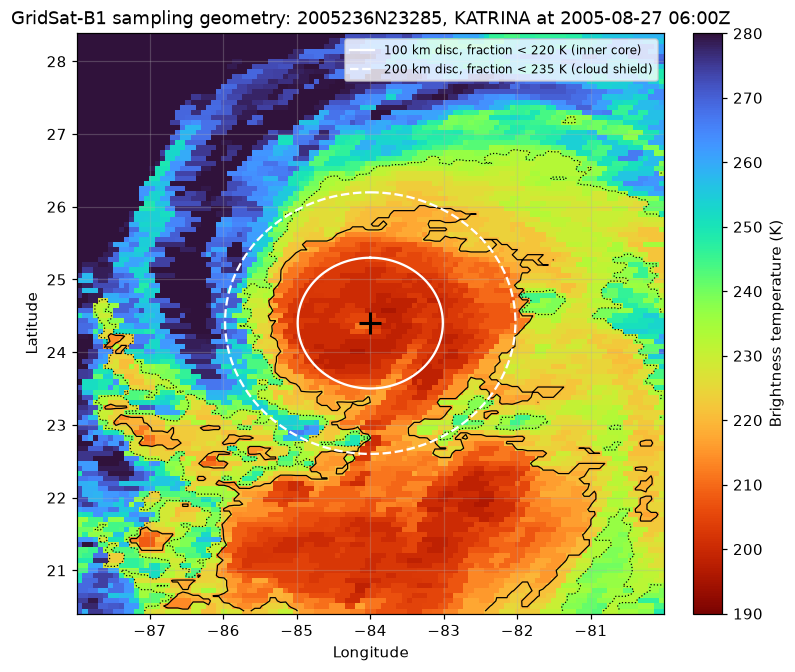

In [45]:
# @title GridSat-B1: Katrina: cold-cloud sampling geometry

plot_lat, plot_lon = example_storm_lat, example_storm_lon
plot_time = pd.Timestamp(example_storm_time)
plot_lon_180 = ((plot_lon + 180) % 360) - 180
domain_half_width = 4.0

gridsat_url = f"https://www.ncei.noaa.gov/data/geostationary-ir-channel-brightness-temperature-gridsat-b1/access/{plot_time:%Y}/GRIDSAT-B1.{plot_time:%Y.%m.%d.%H}.v02r01.nc"
gridsat_file = gridsat_url.split("/")[-1]
!wget -q -nc {gridsat_url}

gridsat_ds = xr.open_dataset(gridsat_file).isel(time=0).sel(lat=slice(plot_lat-domain_half_width, plot_lat+domain_half_width), lon=slice(plot_lon_180-domain_half_width, plot_lon_180+domain_half_width))

def create_distance_ring(distance_km, num_points=361):
    """Create a constant-distance circle around the storm center."""
    storm_lat_rad, storm_lon_rad = np.deg2rad(plot_lat), np.deg2rad(plot_lon_180)
    bearing_rad = np.deg2rad(np.linspace(0, 360, num_points))
    angular_distance = distance_km / EARTH_R_KM
    ring_lat_rad = np.arcsin(np.sin(storm_lat_rad)*np.cos(angular_distance) + np.cos(storm_lat_rad)*np.sin(angular_distance)*np.cos(bearing_rad))
    ring_lon_rad = storm_lon_rad + np.arctan2(np.sin(bearing_rad)*np.sin(angular_distance)*np.cos(storm_lat_rad), np.cos(angular_distance)-np.sin(storm_lat_rad)*np.sin(ring_lat_rad))
    return np.rad2deg(ring_lon_rad), np.rad2deg(ring_lat_rad)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
image = ax.pcolormesh(gridsat_ds.lon, gridsat_ds.lat, gridsat_ds.irwin_cdr.values, cmap="turbo_r", vmin=190, vmax=280)
fig.colorbar(image, ax=ax, label="Brightness temperature (K)")

ax.contour(gridsat_ds.lon, gridsat_ds.lat, gridsat_ds.irwin_cdr.values, levels=[220], colors="k", linewidths=0.8)
ax.contour(gridsat_ds.lon, gridsat_ds.lat, gridsat_ds.irwin_cdr.values, levels=[235], colors="k", linewidths=0.8, linestyles=":")

ax.plot(*create_distance_ring(100), "w-", lw=1.5, label="100 km disc, fraction < 220 K (inner core)")
ax.plot(*create_distance_ring(200), "w--", lw=1.5, label="200 km disc, fraction < 235 K (cloud shield)")
ax.plot(plot_lon_180, plot_lat, "k+", ms=14, mew=2)

ax.set(xlabel="Longitude", ylabel="Latitude", title=f"GridSat-B1 sampling geometry: {example_storm_id}, {example_storm_name} at {plot_time:%Y-%m-%d %H:%M}Z")
ax.legend(loc="upper right", fontsize=8)
plt.show()

> #### 📊 How to read this figure
>
> Dark red marks very cold cloud tops from tall storm clouds (deep convection). They fill the 100 km circle, so its cold-cloud fraction (CCF) is 1.0. The 200 km circle also includes some warmer cloud (CCF about 0.89).
>
> **Main takeaway:** Katrina had deep, cold clouds around its center, a sign of strong convection.

---
### 3.1 Data Download

As mentioned before, we have precomputed the satellite features (`cold_cloud_fraction_100km`, `cold_cloud_fraction_200km`). We will be reading the parquet file which has the feature values for a given (`sid`, `iso_time`,`lat`,`lon`).

In [46]:
df_satellite = pd.read_parquet(SATELLITE_FEATURES_URL)
df_satellite.head()

,sid,lat,lon,iso_time,cold_cloud_fraction_100km,cold_cloud_fraction_200km,ir_coverage_fraction
0,1980001S13173,-12.5,172.5,1980-01-01 00:00:00,NaN,NaN,0.742612
1,1980001S13173,-11.9,172.4,1980-01-01 06:00:00,0.007049,0.173876,1.000000
2,1980001S13173,-11.5,172.5,1980-01-01 12:00:00,0.999955,0.872292,1.000000
3,1980001S13173,-11.2,172.7,1980-01-01 18:00:00,0.060325,0.298294,1.000000
4,1980001S13173,-11.2,173.0,1980-01-02 00:00:00,0.772823,0.748455,1.000000


---
### 3.2 Comparison of Precomputed and Derived GridSat features for Hurricane Katrina, Lat: 24.4°N Lon: 276.0°E, ISO Time: 2005-08-27T06:00

> #### ℹ️ Note: Minor discrepancy
>
> The 200 km CCF differs slightly (0.888 vs 0.883, about 10 pixels out of about 2,000), most likely because of small method differences such as the distance calculation or the satellite file source.


In [47]:
mask = (
    (df_satellite["sid"] == example_storm_id)
    & (pd.to_datetime(df_satellite["iso_time"], utc=True) == pd.Timestamp(example_storm_time, tz="UTC"))
)
assert mask.sum() == 1, f"expected 1 matching row, got {mask.sum()}"
row = df_satellite[mask].iloc[0]
rows = [
    ("cold cloud < 220K, 100km", derived_100, row["cold_cloud_fraction_100km"]),
    ("cold cloud < 235K, 200km", derived_200, row["cold_cloud_fraction_200km"]),
]
comparison = pd.DataFrame(
    {"derived_in_the_notebook": [d for _, d, _ in rows],
     "precomputed":           [p for _, _, p in rows]},
    index=[n for n, _, _ in rows],
)
comparison.round(4)

,derived_in_the_notebook,precomputed
"cold cloud < 220K, 100km",1.0000,1.0000
"cold cloud < 235K, 200km",0.8883,0.8826


---
<a name="merging"></a>

## 4. Merging IBTrACS, ERA5, and GridSat features

Finally, we are ready to merge features from IBTrACS, ERA5, and GridSat to make a meaningful tabular feature set, along with the target (`ri_tplus24`) which has been derived already in IBTrACS section.




### 🔍 A quick peek at all 3 feature tables

In [48]:
for name, df in [("IBTrACS", df_ibtracs), ("ERA5", df_era5), ("Satellite", df_satellite)]:
    print(f"\n{'='*200}\n{name}: {df.shape[0]:,} rows x {df.shape[1]} cols"
          f" | {df['sid'].nunique():,} storms")
    display(df.head(3))


IBTrACS: 78,472 rows x 33 cols | 4,105 storms


,sid,name,season,basin,full_basin_name,subbasin,iso_time,lat,lon,nature,track_type,iflag,usa_agency,usa_wind,usa_sshs,dist2land,storm_speed,lat_sin,lat_cos,lon_sin,lon_cos,abs_lat,doy_sin,doy_cos,usa_wind_tminus6h,usa_wind_delta_tminus6h,usa_wind_tminus12h,usa_wind_delta_tminus12h,usa_wind_tminus24h,usa_wind_delta_tminus24h,usa_wind_tplus24h,usa_wind_delta_tplus24h,ri_tplus24
0,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 00:00:00,-12.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,647,6.0,-0.216440,0.976296,0.130526,-0.991445,12.5,-0.017202,-0.999852,NaN,NaN,NaN,NaN,NaN,NaN,30.0,5.0,0
1,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 06:00:00,-11.9,172.4,TS,main,O_________OP_O_,jtwc_sh,25.0,-1,670,5.0,-0.206204,0.978509,0.132256,-0.991216,11.9,-0.017202,-0.999852,25.0,0.0,NaN,NaN,NaN,NaN,30.0,5.0,0
2,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 12:00:00,-11.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,703,4.0,-0.199368,0.979925,0.130526,-0.991445,11.5,-0.017202,-0.999852,25.0,0.0,25.0,0.0,NaN,NaN,35.0,10.0,0



ERA5: 78,472 rows x 16 cols | 4,105 storms


,sid,lat,lon,iso_time,sea_surface_temp_200km_mean,sst_valid_fraction,sea_level_pressure_200km_mean,column_water_vapour_200km_mean,annulus_cell_count,wind_east_200hPa_annulus_mean,wind_east_850hPa_annulus_mean,wind_north_200hPa_annulus_mean,wind_north_850hPa_annulus_mean,wind_shear_annulus_ms,wind_shear_annulus_kt,wind_shear_annulus_direction_deg
0,1980001S13173,-12.5,172.5,1980-01-01 00:00:00,302.152889,1.0,100654.912905,57.328939,2490,8.488218,0.384507,-7.294214,-1.076515,10.214203,19.854822,127.497788
1,1980001S13173,-11.9,172.4,1980-01-01 06:00:00,302.252015,1.0,100532.902639,59.203794,2486,6.548779,0.060527,-5.997417,-0.138075,8.742386,16.993838,132.084232
2,1980001S13173,-11.5,172.5,1980-01-01 12:00:00,302.357574,1.0,100697.497443,58.608560,2484,7.122542,-1.377703,-5.689368,-0.259189,10.086675,19.606928,122.571505



Satellite: 78,472 rows x 7 cols | 4,105 storms


,sid,lat,lon,iso_time,cold_cloud_fraction_100km,cold_cloud_fraction_200km,ir_coverage_fraction
0,1980001S13173,-12.5,172.5,1980-01-01 00:00:00,NaN,NaN,0.742612
1,1980001S13173,-11.9,172.4,1980-01-01 06:00:00,0.007049,0.173876,1.000000
2,1980001S13173,-11.5,172.5,1980-01-01 12:00:00,0.999955,0.872292,1.000000


> #### 📊 How to read these tables
>
> All three tables have the same number of rows (78,472) and storms (4,105), so each one has exactly one row per labeled observation. They also share the same keys, storm ID (sid) and time (iso_time), which lets us join them without losing or duplicating any observation.
>
> Main takeaway: The three data sources line up exactly and can be merged into one modeling table.

Let us define *ml_df*, indicating that the dataframe is ready for ML modeling.

*ml_df* will contain observations/records where *ri_tplus24* is defined such as 0/1. Rows where the 24-hour RI label cannot be determined (e.g. for storms at a timestamp where *t+24* record is unavailable), are already dropped.

In [49]:
df_era5 = df_era5.drop(columns=["lat", "lon"], errors="ignore")
df_satellite = df_satellite.drop(columns=["lat", "lon"], errors="ignore")

ml_df = (df_ibtracs
         .merge(df_era5, on=["sid", "iso_time"], how="left",
                validate="one_to_one", suffixes=("", "_DUP"))
         .merge(df_satellite, on=["sid", "iso_time"], how="left",
                validate="one_to_one", suffixes=("", "_DUP")))

dupes = [c for c in ml_df.columns if c.endswith("_DUP")]
assert not dupes, f"column collision in merge: {dupes}"

ml_df = ml_df[[c for c in ml_df.columns if c != TARGET] + [TARGET]]

---
> #### 🧠 Pause and Think: Did this Katrina observation go through RI?
>
> Our Katrina example is one observation: **27 August 2005, 06:00 UTC, at 24.4°N, 276.0°E**. Its conditions looked favorable: warm SST, moist air, typical wind shear, and very cold clouds near the center. Would you predict RI?
>
> Run the next cell to find out. Look at `usa_wind`, `usa_wind_tplus24h`, and `ri_tplus24`.

In [96]:
# The Katrina example observation, after merging all three data sources
sst_col, mslp_col = "sea_surface_temp_200km_mean", "sea_level_pressure_200km_mean"
tcwv_col, shear_col = "column_water_vapour_200km_mean", "wind_shear_annulus_ms"

is_katrina = (ml_df["sid"] == example_storm_id) & (ml_df["iso_time"] == example_storm_time)
katrina_row = ml_df[is_katrina]

display(katrina_row[[
    "sid", "name", "iso_time", "lat", "lon",
    "usa_wind", "usa_wind_tplus24h", "usa_wind_delta_tplus24h",
    sst_col, tcwv_col, shear_col, "cold_cloud_fraction_100km",
    TARGET,
]])

# How unusual were Katrina's conditions compared with all observations?
k = katrina_row.iloc[0]
warmer_than  = (ml_df[sst_col] < k[sst_col]).mean()    # share of observations with cooler SST
lower_than   = (ml_df[mslp_col] > k[mslp_col]).mean()  # share with higher pressure
moister_than = (ml_df[tcwv_col] < k[tcwv_col]).mean()  # share with drier air
median = ml_df[[sst_col, tcwv_col, shear_col]].median()

def for_ri(is_favorable):
    return "more favorable for RI" if is_favorable else "less favorable for RI"

print(f"\nSST warmer than {warmer_than:.0%} of observations → {for_ri(k[sst_col] > median[sst_col])}")
print(f"Pressure lower than {lower_than:.0%} of observations → mostly shows the storm is already strong")
print(f"Water vapor higher than {moister_than:.0%} of observations → {for_ri(k[tcwv_col] > median[tcwv_col])}")
print(f"Wind shear {k[shear_col]:.1f} m/s (median: {median[shear_col]:.1f} m/s) → {for_ri(k[shear_col] < median[shear_col])}")

,sid,name,iso_time,lat,lon,usa_wind,usa_wind_tplus24h,usa_wind_delta_tplus24h,sea_surface_temp_200km_mean,column_water_vapour_200km_mean,wind_shear_annulus_ms,cold_cloud_fraction_100km,ri_tplus24
50018,2005236N23285,KATRINA,2005-08-27 06:00:00,24.4,276.0,95.0,125.0,30.0,302.579471,66.255086,7.901361,1.0,1



SST warmer than 90% of observations → more favorable for RI
Pressure lower than 83% of observations → mostly shows the storm is already strong
Water vapor higher than 79% of observations → more favorable for RI
Wind shear 7.9 m/s (median: 7.0 m/s) → less favorable for RI


> **Yes, it did.** Over the next 24 hours, Katrina's wind went from 95 kt to 125 kt (+30 kt), so `ri_tplus24 = 1`. Most of that jump came in the last 6 hours.
>
> But good conditions are not a guarantee. Among observations with SST and moisture at least as high as this one, about 1 in 6 had RI. That is still twice the overall rate, but most did not. This is why our model gives a probability instead of a simple yes/no rule.

---

<a name="split"></a>

## Train/Validation/Test Split

We split the data **by season**, rather than randomly:

* **Train: 1980–2010**: used to **teach the model** the relationship between the input features and RI.

* **Validation: 2011–2015**: used to **tune the model and choose settings**, such as the decision threshold, without using the final test data.

* **Test: 2016–2025**: used only at the end to **evaluate how well the trained model performs on unseen future storms**.

We do this because consecutive observations from the same storm are often very similar. With a random split, observations from the same storm (which are highly similar), could end up in both the training and test sets, making the model look better than it really is. This is a serious issue known as **data leakage**.

By splitting by season, **each storm stays in only one split**. This also better matches the real-world setting: we **train on past storms**, use the validation period to make modeling choices, and finally test whether the model can predict **future storms it has never seen before**.


In [51]:
def split(df):
    '''Chronological split by season. Never split randomly: storms are correlated
    within a season and a random split would leak.'''
    train = df[df.season <= TRAIN_END]
    validation = df[(df.season > TRAIN_END) & (df.season <= VAL_END)]
    test = df[(df.season > VAL_END) & (df.season <= TEST_END)]

    # Pairwise, not three-way: a two-way overlap must also fail
    assert not set(train.sid) & set(validation.sid), "train/val storm overlap"
    assert not set(train.sid) & set(test.sid), "train/test storm overlap"
    assert not set(validation.sid) & set(test.sid), "val/test storm overlap"

    for name, d in [("train", train), ("val", validation), ("test", test)]:
        print(f"{name:6s} seasons {int(d.season.min())}–{int(d.season.max())}  "
              f"rows={len(d):7,d}  storms={d.sid.nunique():5,d}  "
              f"ri_rate={d[TARGET].mean():.4f}")
    return train, validation, test

train  seasons 1980–2010  rows= 57,178  storms=2,816  ri_rate=0.0704
val    seasons 2011–2015  rows=  7,496  storms=  430  ri_rate=0.0986
test   seasons 2016–2025  rows= 13,798  storms=  859  ri_rate=0.1024


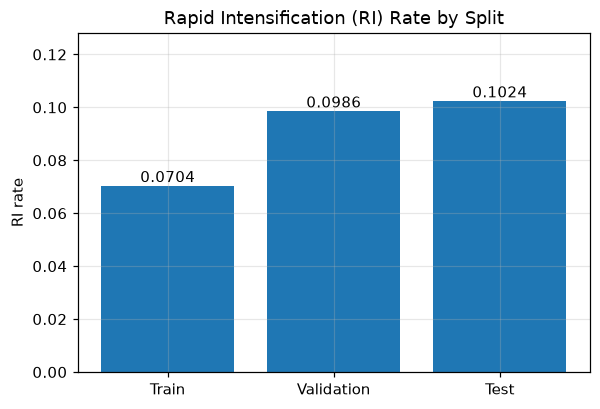

In [52]:
df_train, df_val, df_test = split(ml_df)

y_train = df_train[TARGET].astype(int)
y_val   = df_val[TARGET].astype(int)
y_test  = df_test[TARGET].astype(int)

train_base_rate = y_train.mean()
val_base_rate = y_val.mean()
test_base_rate = y_test.mean()

split_names = ["Train", "Validation", "Test"]
base_rates = [train_base_rate, val_base_rate, test_base_rate]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(split_names, base_rates)

ax.set_ylabel("RI rate")
ax.set_title("Rapid Intensification (RI) Rate by Split")
ax.set_ylim(0, max(base_rates) * 1.25)

for bar, rate in zip(bars, base_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{rate:.4f}", ha="center", va="bottom")

plt.show()

### RI % split by decade

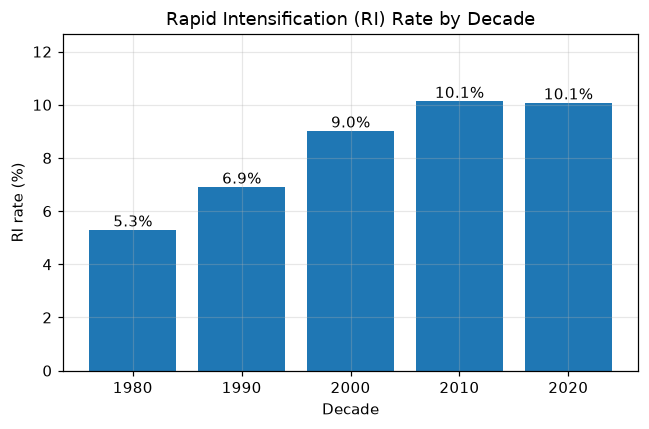

In [53]:
decade_ri = ml_df.assign(decade=pd.to_datetime(ml_df["iso_time"]).dt.year // 10 * 10).groupby("decade")[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(decade_ri.index.astype(str), decade_ri)

ax.set(xlabel="Decade", ylabel="RI rate (%)", title="Rapid Intensification (RI) Rate by Decade",
       ylim=(0, decade_ri.max() * 1.25))

for bar, rate in zip(bars, decade_ri):
    ax.text(bar.get_x() + bar.get_width()/2, rate, f"{rate:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

> #### ℹ️ Note: Why does the RI rate increase over time?
>
> The RI rate rises from **7.0% → 9.9% → 10.2%** across the train, validation, and test periods. By decade, it rises from 5.3% in the 1980s to about 10% in the 2010s and 2020s, and then levels off.
>
> This is in line with the climate trend in [Climate Impact](#climate-impact), but we should not assume a single cause:
>
> * **Warmer oceans** may create more RI-favorable conditions.
> * **Natural variability:** some decades simply have more RI-favorable conditions.
> * **Better observations:** satellites, aircraft reconnaissance, and intensity estimates have improved, which may change how RI is recorded.
>
> For the model, what matters is that the RI rate is not constant: it learns from years with less RI and is tested on years with more. This is a **distribution shift**.
>
> **Further reading:** [*A potential explanation for the global increase in tropical cyclone rapid intensification*](https://doi.org/10.1038/s41467-022-34321-6), *Nature Communications* (Bhatia et al., 2022), found a significant increase in intensification rates in several basins and globally, with a positive contribution from anthropogenic (human-caused) forcing.


---
<a name="methodology"></a>

# Methodology

Rapid intensification (RI) is hard to predict because it depends on many factors acting together. Warm ocean water, low wind shear, and recent storm strengthening may each help, but their combination is often more important than any single factor alone.

This tutorial builds the prediction model step by step:

**Climatology and a simple wind-trend rule → Linear model → Gradient-boosted model**

Each step adds more information and tests whether the model learns useful patterns beyond a simple baseline.

Main things considered before modeling:

* **Class imbalance:** RI makes up **7.9%** of observations (about **1 RI for every 12 non-RI cases**). Simply predicting "no RI" gives high accuracy but is not useful.
* **Distribution shift:** The RI rate changes across time, from 7.0% in training (1980–2010) to 10.2% in the test period (2016–2025). The model therefore needs to work under a changing climatological baseline. Any RI model may face a similar shift as the climate keeps warming.
* **Data leakage:** Future wind information such as `usa_wind_tplus24h` and `usa_wind_delta_tplus24h` directly reveals the outcome. These variables are removed **before modeling** so the model only uses information available at prediction time.

We address these challenges throughout the tutorial and consider them again when evaluating the final model.

---

<a name="problem-definition"></a>

## Problem Definition

We treat RI as **binary classification problem at the observation level**. Given a feature vector $\mathbf{x}_t \in \mathbb{R}^{d}$ describing a storm's state at time $t$, the model outputs a probability

$$\hat{p}_t = P(y_t = 1 \mid \mathbf{x}_t)$$

where the label is

$$y_t = \mathbf{1}\!\left[\,w_{t+24} - w_t \;\geq\; 30\text{ kt}\,\right]$$

and $w_t$ is the maximum sustained 1-minute wind speed at time $t$. We predict
probabilities rather than hard labels because operational forecasters consume
probability guidance.

The features come from four source groups:
IBTrACS best-track (the storm's current state), lagged wind history (wind speed and wind change over the previous 6, 12 and 24 hours, derived from earlier IBTrACS observations in Data Description, Section 1.6.3), ERA5 reanalysis, and satellite IR from GridSat-B1.



---
<a name="features-target"></a>

## 1. Defining features, target, ablation setup


### 1.1 Features and Target Definition

The **features** are the inputs to the model, and the **target** (`ri_tplus24`) is what we want to predict. We organize the features into four physically meaningful groups and leave out anything from the future, to avoid **data leakage**.


In [54]:
TARGET = "ri_tplus24"
GROUP  = "sid"
TIME   = "iso_time"

IBTRACS_BASE_FEATURES = [
    "usa_wind", "usa_sshs", "dist2land", "storm_speed",
    "lat_sin", "lat_cos", "lon_sin", "lon_cos", "abs_lat",
    "doy_sin", "doy_cos",
]

IBTRACS_PAST_TRENDS_FEATURES = [
    "usa_wind_tminus6h",  "usa_wind_delta_tminus6h",
    "usa_wind_tminus12h", "usa_wind_delta_tminus12h",
    "usa_wind_tminus24h", "usa_wind_delta_tminus24h",
]

ERA5_FEATURES = [
    "sea_surface_temp_200km_mean",
    "sea_level_pressure_200km_mean",
    "column_water_vapour_200km_mean",
    "wind_east_200hPa_annulus_mean",  "wind_north_200hPa_annulus_mean",
    "wind_east_850hPa_annulus_mean",  "wind_north_850hPa_annulus_mean",
    "wind_shear_annulus_ms",
]

SATELLITE_FEATURES = [
    "cold_cloud_fraction_100km",
    "cold_cloud_fraction_200km",
]

# NEVER features as these encode the future wind used to build the label.
LEAK = ["usa_wind_tplus24h", "usa_wind_delta_tplus24h"]

---
### 1.2 Feature Combinations for Ablation
Ablation systematically removes or adds groups of features to measure how much each source contributes to model performance. We compare individual feature groups, leave-one-group-out combinations, and the full feature set to understand which information sources are most useful for RI prediction.

#### Feature Groups
We define four mutually exclusive groups:

- **Base**: Current storm-state variables from IBTrACS
- **Lagged wind history** (`trends` in the code and plots): wind speed and wind change over the previous 6, 12 and 24 hours, derived from earlier IBTrACS observations (Data Description, Section 1.6.3)
- **ERA5**: Large-scale atmospheric reanalysis fields
- **Satellite**: Satellite-derived observations

#### Combination Strategy
Experiments follow three configurations:

(1) **single-group**: isolating each group's individual contribution

(2) **leave-one-group-out (LOGO)**: revealing the marginal value of each source when the remaining three are present

(3) **full feature set**: serving as the performance ceiling.

This gives 9 feature sets. Each is trained with both logistic regression and XGBoost, and all are compared with the same 5-fold cross-validation on the training years.

In [55]:
FEATURE_SETS = {
    # Single sources: what does each know on its own?
    "base":       IBTRACS_BASE_FEATURES,
    "trends":     IBTRACS_PAST_TRENDS_FEATURES,
    "era5":       ERA5_FEATURES,
    "sat":        SATELLITE_FEATURES,

    # Leave-one-out: what does each add at the margin?
    "all-minus-base":   IBTRACS_PAST_TRENDS_FEATURES + ERA5_FEATURES + SATELLITE_FEATURES,
    "all-minus-trends": IBTRACS_BASE_FEATURES + ERA5_FEATURES + SATELLITE_FEATURES,
    "all-minus-era5":   IBTRACS_BASE_FEATURES + IBTRACS_PAST_TRENDS_FEATURES + SATELLITE_FEATURES,
    "all-minus-sat":    IBTRACS_BASE_FEATURES + IBTRACS_PAST_TRENDS_FEATURES + ERA5_FEATURES,

    # All features in consideration
    "all":        IBTRACS_BASE_FEATURES + IBTRACS_PAST_TRENDS_FEATURES
                  + ERA5_FEATURES + SATELLITE_FEATURES,
}

---
### 1.3 Dataset Split Summary

In [56]:
BASE_RATE        = float(y_train.mean())
POS_CLASS_WEIGHT = float((y_train == 0).sum() / (y_train == 1).sum())

total_n = len(df_train) + len(df_val) + len(df_test)
total_storms = (
    df_train[GROUP].nunique()
    + df_val[GROUP].nunique()
    + df_test[GROUP].nunique()
)

summary = pd.DataFrame([
    dict(split="train", years="1980-2010", n=len(df_train),
         storms=df_train[GROUP].nunique(), ri_percentage=100*y_train.mean()),
    dict(split="val",   years="2011-2015", n=len(df_val),
         storms=df_val[GROUP].nunique(), ri_percentage=100*y_val.mean()),
    dict(split="test",  years="2016-2025", n=len(df_test),
         storms=df_test[GROUP].nunique(), ri_percentage=100*y_test.mean()),
])
summary["n_percentage"] = 100 * summary["n"] / total_n
summary["storm_percentage"] = 100 * summary["storms"] / total_storms
summary = summary[
    ["split", "years", "n", "n_percentage", "storms", "storm_percentage", "ri_percentage"]
]

display(summary.round(2))
print(f"training base rate = {BASE_RATE:.4f}")
print(f"training pos-class weight = {POS_CLASS_WEIGHT:.2f}")

,split,years,n,n_percentage,storms,storm_percentage,ri_percentage
0,train,1980-2010,57178,72.86,2816,68.60,7.04
1,val,2011-2015,7496,9.55,430,10.48,9.86
2,test,2016-2025,13798,17.58,859,20.93,10.24


training base rate = 0.0704
training pos-class weight = 13.21


> #### 📊 How to read this table
>
> About 73% of rows are used for training. RI is more common in the test years (10.2%) than in training (7.0%), a *distribution shift*. The positive-class weight of 13.2 (non-RI cases per RI case) later helps the model focus on RI.
>
> **Main takeaway:** RI is rare and more common in recent years, so we need class weights and careful evaluation.

---

### 💡 Concept: How do we know if an RI model is actually good?

The real question is not how well a model does on data it has already seen, but **how well it works on new storms**. Because RI is rare, the way we measure this matters a lot.

#### Why accuracy fails

**Accuracy** is the fraction of predictions that are correct:

$$
\text{Accuracy} = \frac{TP + TN}{\text{All cases}}
$$

Suppose 100 of 1,000 observations are RI (10%). A model that always says "no RI" is **90% accurate**, yet it **misses every RI event**. So we need measures that focus on the rare RI class.

#### The confusion matrix

Every prediction falls into one of four boxes. We will use this running example of 1,000 observations:

|                  | **Predicted RI** | **Predicted no RI** |
| ---------------- | :--------------: | :-----------------: |
| **Actual RI**    | **TP** (detected RI) = 60 | **FN** (missed RI) = 40 |
| **Actual no RI** | **FP** (false alarm) = 50 | **TN** (correctly rejected) = 850 |

#### What we measure in this tutorial

We use **one primary metric** and **two supporting metrics**. Each one answers a different question.

**1. PR-AUC (primary): "Does the model rank risky cases above safe ones?"**

PR-AUC is built from two simple ideas:

- **Recall**, also called **probability of detection (POD)**, is the share of RI events we catch: $TP / (TP + FN)$. In the example, $60 / 100 = 0.60$.
- **Precision** is the share of RI alarms that are correct: $TP / (TP + FP)$. In the example, $60 / 110 \approx 0.55$.

Every decision threshold gives one recall and one precision. Moving the threshold from high to low traces the **precision–recall (PR) curve**. **PR-AUC** is the area under this curve (we compute it as *average precision*). It summarizes the model over all thresholds, so it does not depend on the threshold we choose later.

- A perfect model scores **1**.
- A model with no skill scores about the **RI rate** (about 0.07–0.10 in our data), so always compare PR-AUC with that **no-skill baseline**.

*Why not ROC-AUC?* ROC-AUC is popular, but when positives are rare it can look very good even when many alarms are false, because it gives a lot of credit for correctly rejecting the many non-RI cases. PR-AUC focuses on the rare RI class. ***Source:*** *[The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets](https://doi.org/10.1371/journal.pone.0118432) (Saito & Rehmsmeier, 2015)*

**2. Brier Skill Score (BSS): "Can we trust the probabilities?"**

The **Brier Score (BS)** is the average squared difference between the predicted probability $p_i$ and what happened $y_i$ (1 for RI, 0 for no RI). Lower is better:

$$
\text{BS} = \frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)^2
$$

The **Brier Skill Score** compares the model with **climatology**: always predicting the RI rate of the training data.

$$
\text{BSS} = 1 - \frac{\text{BS}}{\text{BS}_{\text{climatology}}}
$$

For example, if the RI rate is 10%, always predicting $p = 0.10$ gives $\text{BS}_{\text{climatology}} = 0.09$. A model with $\text{BS} = 0.06$ gets $\text{BSS} = 1 - 0.06/0.09 \approx 0.33$.

- **BSS > 0**: better probabilities than climatology.
- **BSS = 0**: no better than climatology.
- **BSS < 0**: worse than climatology.

RI forecasting studies commonly use BSS to judge probabilistic RI forecasts (Rozoff & Kossin, 2011).

**3. POD and FAR at the chosen threshold: "If we raise alarms, how many RI events do we catch, and how many alarms are false?"**

To turn probabilities into yes/no alarms, we choose a **decision threshold**. At that threshold we report:

- **POD** (= recall): the share of RI events we catch. Example: $60/100 = 0.60$.
- **FAR**, the **false alarm ratio**: the share of alarms that are false, $FP / (TP + FP)$, which equals $1 - \text{precision}$. Example: $50/110 \approx 0.45$.

POD and FAR are the standard pair used to check RI guidance in operational forecasting. ***Source:*** *[A Revised Tropical Cyclone Rapid Intensification Index for the Atlantic and Eastern North Pacific Basins](https://doi.org/10.1175/2009WAF2222280.1) (Kaplan et al., 2010)*

#### How we choose the threshold: F2

The **F2 score** combines precision and recall into one number, but counts recall **twice as much** as precision:

$$
\text{F2} = \frac{5 \times \text{Precision} \times \text{Recall}}{4 \times \text{Precision}+\text{Recall}}
$$

In the example, $\text{F2} \approx 0.59$. We pick the threshold with the **highest F2 on the validation set**, because missing an RI event is usually worse than a false alarm. F2 is our **rule for choosing the threshold**, not a separate result.

#### Summary

| Role | Metric | Question it answers | Good value |
| --- | --- | --- | --- |
| **Primary** | PR-AUC | Does the model rank RI cases above non-RI cases? | Higher, compared with the RI rate |
| Supporting | BSS | Can we trust the probabilities? | Above 0 |
| Supporting | POD and FAR | At our threshold, how many RI events do we catch, and how many alarms are false? | High POD, low FAR |
| Threshold rule | F2 | Which threshold should we use? | Chosen to be highest on validation |

---
<a name="helper-functions"></a>

## 2. Helper Functions (Method Definitions)

All function definitions are kept together in this section.

Nothing is executed here. We define the functions that will be used later. This keeps the actual modeling phase less cluttered and easier to follow.


### 2.1 Evaluation Metrics

`evaluate()` calculates our primary metric, **PR-AUC** (with its no-skill baseline), and the **Brier Skill Score**. Neither needs a threshold. `confusion()` calculates **POD** and **FAR** at one chosen threshold.


In [57]:
# @title Functions to evaluate ML model
def evaluate(model_name, y_true, probabilities, base_rate=None, probabilistic=True):
    """PR-AUC (primary metric) and Brier Skill Score against climatology (the training RI rate)."""
    base_rate     = BASE_RATE if base_rate is None else base_rate
    y_true        = np.asarray(y_true).astype(int)
    probabilities = np.asarray(probabilities, dtype=float)

    pr_auc   = average_precision_score(y_true, probabilities)
    no_skill = y_true.mean()   # PR-AUC of a model with no skill
    if probabilistic:
        bss = 1 - brier_score_loss(y_true, probabilities) / brier_score_loss(
            y_true, np.full_like(probabilities, base_rate))
    else:
        bss = np.nan           # a yes/no rule has no real probabilities, so BSS does not apply

    bss_text = f"{bss:+.3f}" if probabilistic else "n/a"
    print(f"{model_name:34s} PR-AUC={pr_auc:.3f} (no skill: {no_skill:.3f})  BSS={bss_text}")
    return dict(model=model_name, pr_auc=pr_auc, no_skill_pr_auc=no_skill, bss=bss)


def confusion(y_true, probabilities, threshold, title=""):
    """Counts, POD and FAR at one decision threshold."""
    y_true      = np.asarray(y_true).astype(int)
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()

    pod   = tp / (tp + fn) if tp + fn else 0.0   # probability of detection (= recall)
    far   = fp / (tp + fp) if tp + fp else 0.0   # false alarm ratio (= 1 - precision)
    alarm = predictions.mean()                   # share of observations flagged as RI

    print(f"{title or 'Classification report'} | threshold = {threshold:.3f}")
    print(f"  TP = {tp:,}   FN = {fn:,}   FP = {fp:,}   TN = {tn:,}")
    print(f"  Alarm rate = {alarm:.1%}   POD (recall) = {pod:.3f}   FAR = {far:.3f}   (precision = {1 - far:.3f})\n")

    return dict(tn=tn, fp=fp, fn=fn, tp=tp, alarm_rate=alarm, pod=pod, far=far)

In [58]:
# @title Function to plot Confusion Matrix (CM)
PASTEL_GREEN = "#a8d5b5"
PASTEL_RED   = "#f0a8a8"

def plot_confusion(y_true, probabilities, threshold, title=""):
    """Confusion matrix: green for correct cells, red for errors."""
    y_true = np.asarray(y_true).astype(int)
    preds = (np.asarray(probabilities) >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds, labels=[1, 0])

    correct = np.array([[True, False], [False, True]])
    labels = [["TP", "FN"], ["FP", "TN"]]

    fig, ax = plt.subplots(figsize=(4.2, 3.8))

    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                facecolor=PASTEL_GREEN if correct[i, j] else PASTEL_RED,
                edgecolor="white", linewidth=2
            ))
            ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]:,}",
                    ha="center", va="center", color="#222222", fontsize=12)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_xticks([0, 1], ["RI", "No RI"])
    ax.set_yticks([0, 1], ["RI", "No RI"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Observed")
    ax.set_title(f"{title}\n(threshold = {threshold:.3f})")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

    return cm

---
### 2.2 Baseline Models

We use two simple reference models to put the learned models into context. `fit_climatology` ignores all storm information and predicts using the overall RI frequency. `fit_wind_trend` uses a simple physical intuition: **storms that have recently been intensifying are more likely to continue intensifying**. It uses the storm's wind change over the past 6 hours as its single predictor, and picks its cut-off with F2, the same rule we later use for the model's decision threshold.


In [59]:
# @title Functions to define baseline models
def fit_climatology(X_train, y_train, X_val=None, y_val=None):
    """Always predicts the training base rate. The floor every model must beat."""
    return DummyClassifier(strategy="prior").fit(X_train, y_train)


def fit_wind_trend(X_train, y_train, verbose=True):
    """Find the 6-hour wind-trend cut-off that maximizes F2 on training data
    (the same rule we use later to choose the model's decision threshold).
    NaNs (first observation of each storm, no prior history) are filled with 0.
    """
    col = X_train["usa_wind_delta_tminus6h"].fillna(0.0)
    best_f2, best_threshold = -1.0, 0.0

    for t in np.arange(0, 25, 0.5):
        y_pred = (col >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, y_pred, labels=[0, 1]).ravel()
        f2 = 5 * tp / max(5 * tp + 4 * fn + fp, 1)
        if f2 > best_f2:
            best_f2, best_threshold = f2, t

    if verbose:
        print(f"  wind-trend rule:  delta_w(-6h) >= {best_threshold:.1f} kt   "
              f"(train F2 = {best_f2:.4f})")
    return best_threshold


def predict_proba_wind_trend(X, wind_threshold):
    """Hard rule, so probabilities are degenerate (0 or 1).
    """
    p = (X["usa_wind_delta_tminus6h"].fillna(0.0) >= wind_threshold).astype(float).values
    return np.column_stack([1 - p, p])

---
### 2.3 Learned Models

We use two learned models with different levels of complexity. **Logistic regression** provides a simple, interpretable linear baseline, while **XGBoost** can capture nonlinear relationships and interactions between features.

**Logistic regression**: a linear model that estimates the probability of RI from a weighted combination of the input features. Its coefficients provide a useful indication of how individual features are associated with the prediction.

Because it cannot handle missing values directly, we use median imputation and standardization before training.

| Parameter      | Value      | Reason                                               |
| -------------- | ---------- | ---------------------------------------------------- |
| `class_weight` | `balanced` | Weights each class by the inverse of how often it appears, so the rare RI cases get more weight |
| `max_iter`     | 2000       | Provides enough iterations for the model to converge |

**XGBoost**: a tree-based model that learns nonlinear relationships and interactions between features. This is useful here because RI can depend on combinations of conditions, e.g. ocean temperature, wind shear, and cloud structure together. XGBoost can also handle missing values natively.

We keep the XGBoost hyperparameters **fixed rather than tuning them separately for each feature set**. This keeps the ablation experiment focused on one question: **does adding a particular feature group improve the model?** It avoids changing the model configuration at the same time, which would make the comparisons harder to interpret.

| Parameter          | Value   | Reason                                                              |
| ------------------ | ------- | ------------------------------------------------------------------- |
| `max_depth`        | 4       | Keeps trees relatively simple and reduces overfitting               |
| `learning_rate`    | 0.05    | Makes smaller updates during training                               |
| `min_child_weight` | 10      | Discourages very small, highly specific leaves                      |
| `subsample`        | 0.8     | Uses a random subset of rows for each boosting step                 |
| `colsample_bytree` | 0.8     | Uses a random subset of features for each tree                      |
| `scale_pos_weight` | 13.2    | The number of non-RI cases divided by the number of RI cases in the training data (about 13 to 1), so each RI case counts about as much as 13 non-RI cases. This is the typical value recommended in the [XGBoost documentation](https://xgboost.readthedocs.io/en/stable/parameter.html). |
| `reg_lambda`       | 2.0     | Penalizes large leaf values, which helps reduce overfitting |
| `eval_metric`      | `aucpr` | Focuses evaluation on performance for the imbalanced positive class |

Both models account for **class imbalance** during training because RI events are much less common than non-RI cases.


In [60]:
# @title Functions to fit logistic regression and xgboost
def fit_logistic(X_train, y_train, X_val=None, y_val=None):
    """Linear baseline. Median imputation + standardisation + balanced class weights."""
    return Pipeline([
        ("imputer",  SimpleImputer(strategy="median")),
        ("scaler",   StandardScaler()),
        ("logistic", LogisticRegression(class_weight="balanced",
                                        max_iter=2000, random_state=SEED)),
    ]).fit(X_train, y_train)


def fit_xgboost(X_train, y_train, X_val=None, y_val=None, n_estimators=600):
    """Gradient-boosted trees. Handles NaN natively, no imputation needed.

    Early stopping is used only when validation data is supplied (CV folds).
    The full refit on the training set passes n_estimators explicitly and stops there.
    """
    use_early_stop = X_val is not None

    model = XGBClassifier(
        n_estimators          = n_estimators,
        max_depth             = 4,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 10,
        reg_lambda            = 2.0,
        scale_pos_weight      = POS_CLASS_WEIGHT,
        eval_metric           = "aucpr",
        early_stopping_rounds = 40 if use_early_stop else None,
        n_jobs                = -1,
        random_state          = SEED,
    )

    if use_early_stop:
        return model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model.fit(X_train, y_train, verbose=False)

MODEL_FNS = {"logistic": fit_logistic, "xgboost": fit_xgboost}

---
### 2.4 Cross-Validation Strategy

We use **`GroupKFold` with storm ID as the group key**, keeping all observations from the same storm in a single fold.

This prevents information from highly correlated time steps of the same storm from appearing in both training and validation data. Standard k-fold could therefore give overly optimistic results.


In [61]:
# @title Function to run GroupKFold cross validation on training data
def run_cv_grid(df_train, y_train, feature_sets, model_fns, n_splits=5):
    """GroupKFold CV over every (feature set x model) pair, ranked by mean PR-AUC.

    Also records mean best_iteration per XGBoost row so that we can refit
    without early stopping.
    """
    cv, groups, rows = GroupKFold(n_splits), df_train[GROUP].values, []

    for fs_name, features in feature_sets.items():
        X = df_train[features]
        for model_name, fit_fn in model_fns.items():
            scores, iters = [], []
            print(f"Evaluating feature set: {fs_name} | model: {model_name}")
            for tr_idx, va_idx in cv.split(X, y_train, groups=groups):
                y_va  = y_train.iloc[va_idx]
                model = fit_fn(X.iloc[tr_idx], y_train.iloc[tr_idx], X.iloc[va_idx], y_va)
                scores.append(average_precision_score(
                    y_va, model.predict_proba(X.iloc[va_idx])[:, 1]))
                if getattr(model, "best_iteration", None) is not None:
                    iters.append(model.best_iteration)

            rows.append(dict(feature_set=fs_name, model=model_name,
                             pr_auc_mean=np.mean(scores), pr_auc_std=np.std(scores),
                             best_iter=int(np.mean(iters)) if iters else 600,
                             fold_scores=scores))

    return (pd.DataFrame(rows).sort_values("pr_auc_mean", ascending=False)
              .reset_index(drop=True))

---
### 2.5 Calibration and threshold selection

These functions calibrate the probabilities (`fit_calibrator`), show the POD/FAR trade-off for different alarm rates (`report_alarm_rates`), choose the F2-optimal threshold (`best_threshold`), and show how sensitive that choice is (`plot_f2_curve`). All of them use **validation data only**.

In [62]:
# @title Functions for calibration and threshold selection

def fit_calibrator(val_scores, y_val):
    """Isotonic calibration map. Apply to new scores with .predict(scores)."""
    return IsotonicRegression(out_of_bounds="clip").fit(val_scores, y_val)


def best_threshold(y_true, probabilities, beta=2.0):
    """F-beta optimal threshold. beta=2 weights recall twice as heavily as
    precision, reflecting that a missed RI event is costlier than a false alarm."""
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    b2    = beta ** 2
    fbeta = (1 + b2) * precision * recall / np.clip(b2 * precision + recall, 1e-9, None)
    return float(thresholds[np.nanargmax(fbeta[:-1])])


def plot_f2_curve(y_true, probabilities, chosen_threshold):
    """F2 at every candidate threshold, with the chosen threshold marked."""
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    f2 = (5 * precision * recall / np.clip(4 * precision + recall, 1e-9, None))[:-1]

    near_best = thresholds[f2 >= np.nanmax(f2) - 0.01]
    print(f"Highest F2 = {np.nanmax(f2):.3f}. F2 stays within 0.01 of it for thresholds "
          f"from {near_best.min():.3f} to {near_best.max():.3f}.")

    fig, ax = plt.subplots(figsize=(5, 3.2))
    ax.plot(thresholds, f2, color="#4C72B0")
    ax.axvspan(near_best.min(), near_best.max(), color="#4C72B0", alpha=0.15, label="within 0.01 of best F2")
    ax.axvline(chosen_threshold, ls="--", color="k", lw=1, label=f"chosen threshold ({chosen_threshold:.3f})")
    ax.set(xlabel="Decision threshold", ylabel="F2", title="F2 across thresholds (validation)", xlim=(0, 0.6))
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def report_alarm_rates(y_true, probabilities, alarm_rates=(0.30, 0.20, 0.10, 0.05)):
    """POD and FAR when we raise alarms for the riskiest X% of observations."""
    y_true = np.asarray(y_true).astype(int)
    rows   = []
    for target in alarm_rates:
        threshold   = float(np.quantile(probabilities, 1 - target))
        predictions = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
        rows.append({"target alarm %":  f"{target:.0%}",
                     "threshold":       round(threshold, 3),
                     "actual alarm %":  f"{predictions.mean():.1%}",
                     "POD":             round(tp / max(tp + fn, 1), 3),
                     "FAR":             round(fp / max(tp + fp, 1), 3)})
    display(pd.DataFrame(rows).set_index("target alarm %"))

---
### 2.6 Error-analysis reporting

In [63]:
# @title Function to report metrics by group
def report_by_group(df, y_true, probabilities, group_col, min_events=5):
    """PR-AUC broken down by any grouping column
    """
    y_true = np.asarray(y_true)
    rows   = []

    for key in sorted(df[group_col].unique()):
        mask = (df[group_col] == key).values
        if y_true[mask].sum() < min_events:
            continue
        base   = y_true[mask].mean()
        pr_auc = average_precision_score(y_true[mask], probabilities[mask])
        rows.append({group_col: key,
                     "storms":  df.loc[mask, GROUP].nunique(),
                     "obs":     mask.sum(),
                     "RI":      int(y_true[mask].sum()),
                     "RI %":    100 * base,
                     "PR-AUC":  pr_auc,
                     "vs base": pr_auc / base})
    out = pd.DataFrame(rows).set_index(group_col)

    return (out.style
              .format({"storms": "{:,.0f}", "obs": "{:,.0f}", "RI": "{:,.0f}",
                       "RI %": "{:.1f}%", "PR-AUC": "{:.3f}", "vs base": "{:.1f}x"})
              .background_gradient(cmap="Greens", subset=["PR-AUC"], vmin=0, vmax=0.6)
              .set_caption(f"Skill by {group_col} (test set)"))

---
<a name="model-development"></a>

## 3. Model Development

### 3.1 Feature Set & Model Selection

We score every model and feature-set combination with **5-fold `GroupKFold`** on the training years, with storm ID as the group (see 2.4 Cross-Validation Strategy), and rank them by **mean PR-AUC**, our primary metric. The best combination becomes the **champion configuration**. The validation set is not used here.

*Note:* XGBoost uses the held-out fold for early stopping, so its cross-validation scores are slightly optimistic, and its lead over logistic regression may be a little smaller than shown. XGBoost also trains in parallel, so exact numbers can differ slightly between computers. The conclusions do not change.

> #### ℹ️ Note: Tracking our own emissions
>
> Training ML models uses energy, which produces carbon emissions. We measure the emissions of our two training steps (cross-validation and the final refit) with [CodeCarbon](https://codecarbon.io/), which estimates energy use from your hardware and the carbon intensity of your local electricity. See CCAI's tutorial [*Tracking Emissions from ML Models*](https://colab.research.google.com/github/climatechange-ai-tutorials/tracking-ml-emissions/blob/main/Tracking_Emissions_from_ML_Models_(Revised).ipynb) to learn more.


In [64]:
# This cell might take ~3-4 minutes to run completely
cv_tracker = EmissionsTracker(project_name="ri_cv", output_dir=".", log_level="error")
cv_tracker.start()
cv_results = run_cv_grid(df_train, y_train, FEATURE_SETS, MODEL_FNS, n_splits=5)
cv_emissions = cv_tracker.stop()

display(cv_results.drop(columns="fold_scores").round(4))
print(f"Emissions from cross-validation: {cv_emissions:.6f} kg CO2eq")

[codecarbon WARNING @ 15:27:12] Multiple instances of codecarbon are allowed to run at the same time.


Evaluating feature set: base | model: logistic
Evaluating feature set: base | model: xgboost
Evaluating feature set: trends | model: logistic
Evaluating feature set: trends | model: xgboost
Evaluating feature set: era5 | model: logistic
Evaluating feature set: era5 | model: xgboost
Evaluating feature set: sat | model: logistic
Evaluating feature set: sat | model: xgboost
Evaluating feature set: all-minus-base | model: logistic
Evaluating feature set: all-minus-base | model: xgboost
Evaluating feature set: all-minus-trends | model: logistic
Evaluating feature set: all-minus-trends | model: xgboost
Evaluating feature set: all-minus-era5 | model: logistic
Evaluating feature set: all-minus-era5 | model: xgboost
Evaluating feature set: all-minus-sat | model: logistic
Evaluating feature set: all-minus-sat | model: xgboost
Evaluating feature set: all | model: logistic
Evaluating feature set: all | model: xgboost


,feature_set,model,pr_auc_mean,pr_auc_std,best_iter
0,all,xgboost,0.4065,0.0167,242
1,all-minus-sat,xgboost,0.3906,0.0092,237
2,all-minus-base,xgboost,0.3869,0.0176,216
3,all-minus-trends,xgboost,0.3686,0.0110,216
4,all-minus-era5,xgboost,0.3553,0.0183,219
5,all,logistic,0.3025,0.0127,600
6,all-minus-base,logistic,0.2919,0.0107,600
7,all-minus-sat,logistic,0.2789,0.0096,600
8,trends,xgboost,0.2786,0.0191,127
9,all-minus-era5,logistic,0.2604,0.0079,600


Emissions from cross-validation: 0.000318 kg CO2eq


> #### 📊 How to read this table
>
> Each row is one model with one feature group, scored by **PR-AUC** (higher is better) averaged over 5 folds of different storms. Climatology scores about 0.07. XGBoost with all features is best (about 0.40) and matches or beats logistic regression for every group, which suggests non-linear patterns. `best_iter` is the number of trees XGBoost used.
>
> **Main takeaway:** We use XGBoost with all features for the rest of the tutorial.

In [65]:
best_result = cv_results.iloc[0]

BEST_MODEL_NAME     = best_result.model
BEST_FEATURES       = FEATURE_SETS[best_result.feature_set]
BEST_N_ESTIMATORS   = int(best_result.best_iter)

print("Best configuration:")
print(f"  model        : {BEST_MODEL_NAME}")
print(f"  feature set  : {best_result.feature_set}  ({len(BEST_FEATURES)} features)")
print(f"  CV PR-AUC    : {best_result.pr_auc_mean:.4f} +/- {best_result.pr_auc_std:.4f}")
print(f"  n_estimators : {BEST_N_ESTIMATORS}")

Best configuration:
  model        : xgboost
  feature set  : all  (27 features)
  CV PR-AUC    : 0.4065 +/- 0.0167
  n_estimators : 242


### Ablation: what does each data source add?

The same model comparison can also be used for **feature ablation**. By comparing XGBoost performance across different feature sets, we can see how much each data source contributes to RI prediction.

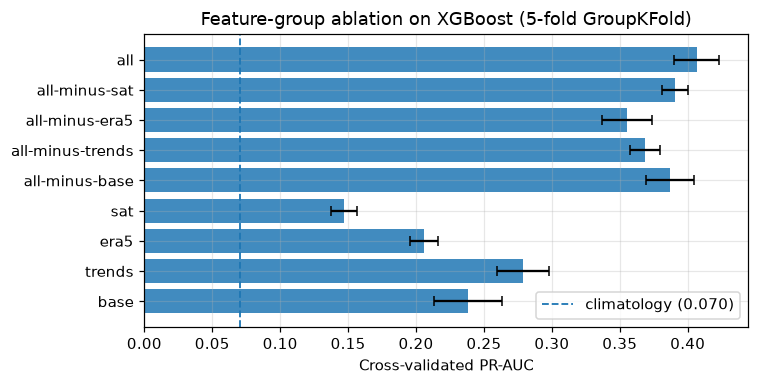

In [66]:
xgboost_results = cv_results[cv_results.model == "xgboost"].set_index("feature_set").reindex(FEATURE_SETS)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(xgboost_results.index, xgboost_results.pr_auc_mean, xerr=xgboost_results.pr_auc_std, alpha=0.85, capsize=3)
ax.axvline(BASE_RATE, ls="--", lw=1.2, label=f"climatology ({BASE_RATE:.3f})")
ax.set_xlabel("Cross-validated PR-AUC")
ax.set_title("Feature-group ablation on XGBoost (5-fold GroupKFold)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [67]:
# How much does PR-AUC drop when one feature group is removed? (leave-one-group-out)
group_names = {"base": "base (current storm state)", "trends": "lagged wind history",
               "era5": "ERA5", "sat": "satellite"}
full = xgboost_results.loc["all"]
rows = []
for group, label in group_names.items():
    row = xgboost_results.loc[f"all-minus-{group}"]
    # All feature sets use the same 5 folds, so we can compare them fold by fold
    lower = np.array(row.fold_scores) < np.array(full.fold_scores)
    rows.append({"group removed": label,
                 "PR-AUC without it": round(row.pr_auc_mean, 3),
                 "change vs all features": round(row.pr_auc_mean - full.pr_auc_mean, 3),
                 "folds where PR-AUC drops": f"{lower.sum()} of {len(lower)}"})
display(pd.DataFrame(rows).set_index("group removed").sort_values("change vs all features"))

,PR-AUC without it,change vs all features,folds where PR-AUC drops
group removed,,,
ERA5,0.355,-0.051,5 of 5
lagged wind history,0.369,-0.038,5 of 5
base (current storm state),0.387,-0.020,5 of 5
satellite,0.391,-0.016,5 of 5


> #### 📊 How to read this chart and table
>
> This is an **ablation**: XGBoost trained with different feature groups. The dashed line is no skill (about 0.07), and error bars show the spread across folds.
>
> - On its own, every group beats no skill. Lagged wind history is strongest (about 0.28), satellite weakest (about 0.15).
> - Removing ERA5 costs the most (about 0.05), and removing satellite costs about 0.01. Both drop in all 5 folds (a simple check, not a formal statistical test).
>
> **Main takeaway:** Every data source helps, ERA5 the most and satellite a small but consistent amount.

---
### 3.2 Full Refit on Training Data

Retrain the best configuration on the **entire** training set.

For XGBoost we pass the mean `best_iteration` recorded across the cross-validation folds (`n_estimators`) rather than using early stopping. There is no held-out fold to stop against here, and borrowing the validation set for that purpose would spend it before probability calibration (Methodology 3.3) needs it.

In [68]:
X_train_best = df_train[BEST_FEATURES]
X_val_best   = df_val[BEST_FEATURES]
X_test_best  = df_test[BEST_FEATURES]

refit_tracker = EmissionsTracker(project_name="ri_refit", output_dir=".", log_level="error")
refit_tracker.start()
if BEST_MODEL_NAME == "xgboost":
    best_model = fit_xgboost(X_train_best, y_train, n_estimators=BEST_N_ESTIMATORS)
else:
    best_model = MODEL_FNS[BEST_MODEL_NAME](X_train_best, y_train)
refit_emissions = refit_tracker.stop()

print(f"Refit {BEST_MODEL_NAME} on {len(X_train_best):,} rows x {len(BEST_FEATURES)} features.")
print(f"Emissions from the final refit: {refit_emissions:.6f} kg CO2eq")

Refit xgboost on 57,178 rows x 27 features.
Emissions from the final refit: 0.000003 kg CO2eq


### Reference Baselines

Simple reference models fitted on the same training data, providing a baseline for comparing the learned models.


In [69]:
climatology_model = fit_climatology(X_train_best, y_train)
wind_threshold    = fit_wind_trend(df_train, y_train, verbose = False)
logistic_model    = fit_logistic(X_train_best, y_train)

---
### 3.3 Probability Calibration

We now use the **validation set** for the first time. The best model produces raw probability scores, and we use **isotonic regression** to calibrate them.

**Isotonic regression** is a simple method that learns how to adjust the model's raw scores into more realistic probabilities, while keeping their **order** the same.

For example, if the model gives a group of cases a score around **0.7**, calibration checks whether those cases actually have an RI rate close to **70%** and adjusts the scores accordingly.

This is useful because `scale_pos_weight` makes the model's raw probabilities too high. That is why the **raw** BSS below is negative: the model ranks cases well (good PR-AUC), but its probability values are too large, so they score worse than climatology. After calibration, BSS becomes positive.

We calibrate **logistic regression** in the same way, because its `class_weight="balanced"` setting inflates its probabilities too. This keeps the comparison between models fair.

**PR-AUC measures ranking, not probability accuracy.** Calibration changes the probability values but keeps their **order**, so PR-AUC stays nearly the same. They can shift slightly because isotonic regression groups some nearby scores into the same value (ties).


In [70]:
val_scores = best_model.predict_proba(X_val_best)[:, 1]
calibrator = fit_calibrator(val_scores, y_val)
val_probs  = calibrator.predict(val_scores)

# Calibrate logistic regression the same way, so the comparison with XGBoost is fair
logistic_calibrator = fit_calibrator(logistic_model.predict_proba(X_val_best)[:, 1], y_val)

_ = evaluate("XGBoost, validation (raw)",        y_val, val_scores)
_ = evaluate("XGBoost, validation (calibrated)", y_val, val_probs)

XGBoost, validation (raw)          PR-AUC=0.480 (no skill: 0.099)  BSS=-0.762
XGBoost, validation (calibrated)   PR-AUC=0.472 (no skill: 0.099)  BSS=+0.266


#### 3.3.1 Reliability Diagram

A perfectly calibrated model follows the diagonal. For example, when it predicts **0.3**, about **30% of those cases** should actually be RI.


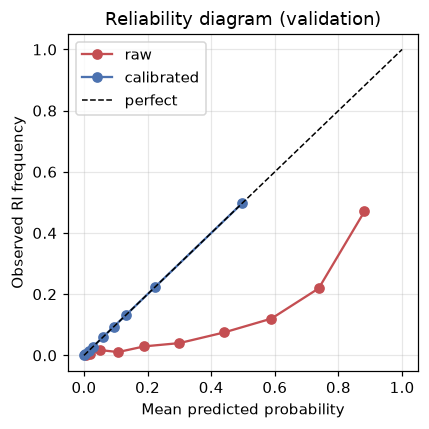

In [71]:
fig, ax = plt.subplots(figsize=(4, 4))
for scores, label, colour in [(val_scores, "raw", "#C44E52"),
                              (val_probs,  "calibrated", "#4C72B0")]:
    frac_pos, mean_pred = calibration_curve(y_val, scores, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", color=colour, label=label)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed RI frequency")
ax.set_title("Reliability diagram (validation)")
ax.legend()
plt.tight_layout()
plt.show()

> #### 📊 How to read this chart
>
> The raw points (red) fall well below the diagonal, so raw scores overstate the chance of RI (the effect of `scale_pos_weight`). The calibrated points (blue) sit close to the diagonal. The calibration was fitted on this same validation data, so this is not an independent test. Results 1.4 checks it on the test years.
>
> **Main takeaway:** Calibration turns raw scores into probabilities we can read at face value.

---
### 3.4 Threshold Selection

To turn probabilities into yes/no RI alarms, we need a **decision threshold**. We choose it on the **calibrated validation probabilities**, using the rule from the metrics section: pick the threshold with the **highest F2**, because missing an RI event is usually worse than a false alarm.

First, the table below shows the trade-off we are choosing from. Then we pick the F2-optimal threshold and check how sensitive F2 is to that choice.

**Why will the threshold be low (well below 0.5)?** After calibration, the probabilities are realistic: a value of 0.12 means about a 12% chance of RI. Since about 10% of observations have RI, anything above that is already a higher-than-usual risk. F2 also favors catching RI events, so it settles on a fairly low threshold. This is expected, not a flaw.

*Honest caveat:* the same validation data is used to fit the calibration and to choose the threshold, so the validation scores are slightly optimistic. The test set (Results section) shows how well the choice holds up on unseen years.

In [72]:
report_alarm_rates(y_val, val_probs)

,threshold,actual alarm %,POD,FAR
target alarm %,,,,
30%,0.093,32.6%,0.850,0.743
20%,0.167,22.3%,0.740,0.672
10%,0.297,10.9%,0.512,0.538
5%,0.476,5.0%,0.306,0.399


> #### 📊 How to read this table
>
> Each row raises an alarm for the riskiest 30%, 20%, 10%, or 5% of observations (the actual share differs slightly because of tied probabilities).
>
> - About 30%: POD about 0.84, but 3 in 4 alarms are false (FAR about 0.74).
> - About 5%: 6 in 10 alarms are correct (FAR about 0.4), but POD drops to about 0.3.
>
> Next, F2 picks the balance.
>
> **Main takeaway:** Catching more RI events always costs more false alarms.

F2-optimal decision threshold = 0.121

Highest F2 = 0.591. F2 stays within 0.01 of it for thresholds from 0.106 to 0.167.


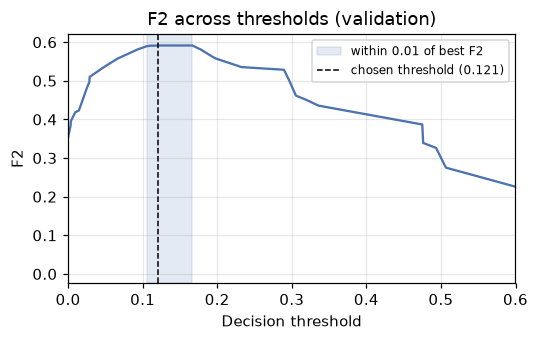

XGBoost on VALIDATION | threshold = 0.121
  TP = 551   FN = 188   FP = 1,151   TN = 5,606
  Alarm rate = 22.7%   POD (recall) = 0.746   FAR = 0.676   (precision = 0.324)



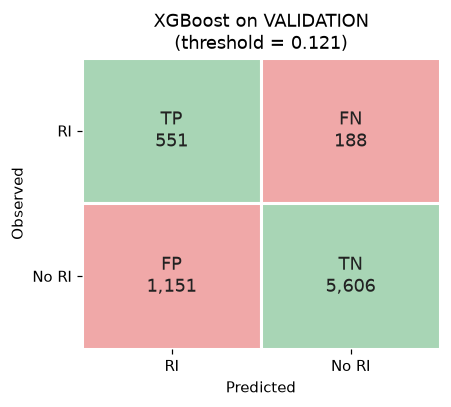

In [73]:
DECISION_THRESHOLD_F2_OPTIMIZED = best_threshold(y_val, val_probs, beta=2.0)
print(f"F2-optimal decision threshold = {DECISION_THRESHOLD_F2_OPTIMIZED:.3f}\n")

plot_f2_curve(y_val, val_probs, DECISION_THRESHOLD_F2_OPTIMIZED)

val_report = confusion(y_val, val_probs, DECISION_THRESHOLD_F2_OPTIMIZED, "XGBoost on VALIDATION")
plot_confusion(y_val, val_probs, DECISION_THRESHOLD_F2_OPTIMIZED, "XGBoost on VALIDATION");

> #### 📊 How to read this chart
>
> The line shows validation F2 at each threshold, and the dashed line is our threshold. The shaded band (within 0.01 of the best F2) is wide, so a nearby threshold gives almost the same result. The confusion matrix shows the counts at our threshold.
>
> **Main takeaway:** The threshold choice is not fragile.

---
> #### 🧠 Pause and Think
>
> Look at the F2 curve and the confusion matrix above. With this threshold, the model raises an RI alarm for roughly a quarter of observations, and most of those alarms are false (a high FAR). Does that make it a bad model?
>
> <details>
> <summary><b>Show answer</b></summary>
>
> Not necessarily. RI is rare and costly to miss, so F2 favors catching RI over keeping alarms clean. An alarm means "higher-than-usual risk", not "RI will happen". Because the F2 curve is flat near its peak, a slightly different threshold would give similar results. If false alarms were costlier, we would choose a higher threshold. The alarm-rate table shows how many RI events that would miss.
>
> </details>

### 🔄 Try it yourself: Change the decision threshold

The model outputs a probability that a storm will undergo RI. Change the **decision threshold** below to see how it affects the **alarm rate, POD, and FAR**. A lower threshold catches more RI events (higher POD) but also produces more false alarms (higher FAR), while a higher threshold does the opposite.


Selecting custom threshold | threshold = 0.300
  TP = 335   FN = 404   FP = 338   TN = 6,419
  Alarm rate = 9.0%   POD (recall) = 0.453   FAR = 0.502   (precision = 0.498)



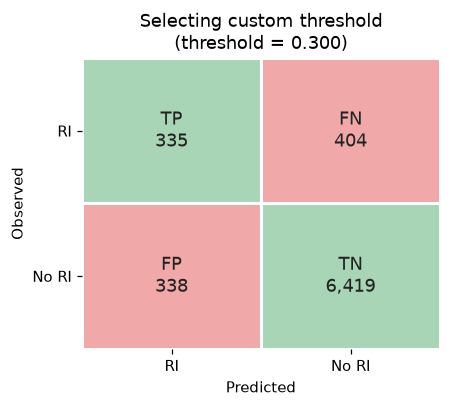

In [74]:
# Change the threshold value on the line below. It should be between 0 and 1, both inclusive.
your_threshold = 0.3
assert 0 <= your_threshold <= 1, "Threshold must be between 0 and 1."
confusion(y_val, val_probs, your_threshold, "Selecting custom threshold");
plot_confusion(y_val, val_probs, your_threshold, "Selecting custom threshold");

---
<a name="results-and-discussion"></a>

# Results & Discussion

Here we evaluate the final model on the **held-out test set**, then use **error analysis** to see where it does well, where it struggles, and what it relies on.


<a name="test-evaluation"></a>

## 1. Held-Out Test Evaluation

We now apply the final model, calibration, and threshold to the test set. **The model is evaluated on the test set only once, at this stage**, to measure performance on unseen storms.

For every model we report our primary metric, **PR-AUC** (with its no-skill baseline), and the **BSS**. Then, for XGBoost, we look at the precision–recall curve, **POD and FAR** at the chosen threshold, and whether the probabilities are still reliable on these later years.

### 1.1 Comparing all models

In [75]:
test_scores = best_model.predict_proba(X_test_best)[:, 1]
test_probs  = calibrator.predict(test_scores)
logistic_test_probs = logistic_calibrator.predict(logistic_model.predict_proba(X_test_best)[:, 1])
wind_rule_alarms    = predict_proba_wind_trend(df_test, wind_threshold)[:, 1]   # 0 or 1

results = [
    evaluate("climatology", y_test, climatology_model.predict_proba(X_test_best)[:, 1]),
    evaluate("wind-trend rule (yes/no)", y_test, wind_rule_alarms, probabilistic=False),
    evaluate("logistic regression (calibrated)", y_test, logistic_test_probs),
    evaluate(f"{BEST_MODEL_NAME} (calibrated)", y_test, test_probs),
]
print()
display(pd.DataFrame(results).set_index("model").round(3))

climatology                        PR-AUC=0.102 (no skill: 0.102)  BSS=+0.000
wind-trend rule (yes/no)           PR-AUC=0.179 (no skill: 0.102)  BSS=n/a
logistic regression (calibrated)   PR-AUC=0.325 (no skill: 0.102)  BSS=+0.159
xgboost (calibrated)               PR-AUC=0.429 (no skill: 0.102)  BSS=+0.227



,pr_auc,no_skill_pr_auc,bss
model,,,
climatology,0.102,0.102,0.000
wind-trend rule (yes/no),0.179,0.102,NaN
logistic regression (calibrated),0.325,0.102,0.159
xgboost (calibrated),0.429,0.102,0.227


> #### 📊 How to read this table
>
> Each row is one model on the test years (2016–2025). No skill is the test RI rate (about 0.10). XGBoost has the highest PR-AUC (about 0.42, roughly four times no skill) and BSS (about +0.23), followed by logistic regression. The wind-trend rule says yes or no, so it has no BSS.
>
> **Main takeaway:** XGBoost ranks RI best and gives the most trustworthy probabilities.

---
### 1.2 Precision–recall curves

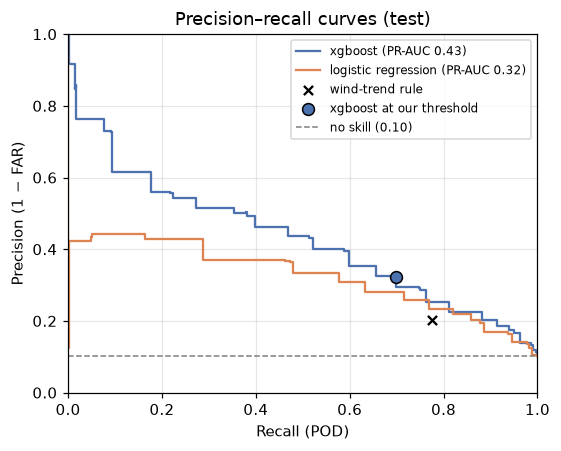

In [76]:
# Precision–recall curves on the test set
fig, ax = plt.subplots(figsize=(5.2, 4.2))
for name, probs, colour in [(f"{BEST_MODEL_NAME}", test_probs, "#4C72B0"),
                            ("logistic regression", logistic_test_probs, "#DD8452")]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ax.step(recall, precision, where="post", color=colour,
            label=f"{name} (PR-AUC {average_precision_score(y_test, probs):.2f})")

# The wind-trend rule gives only one point, because it only says yes or no
tp = ((wind_rule_alarms == 1) & (y_test == 1)).sum()
ax.scatter(tp / (y_test == 1).sum(), tp / (wind_rule_alarms == 1).sum(), marker="x", color="k", zorder=3,
           label="wind-trend rule")

# Our chosen operating point
chosen = test_probs >= DECISION_THRESHOLD_F2_OPTIMIZED
tp = (chosen & (y_test == 1)).sum()
ax.scatter(tp / (y_test == 1).sum(), tp / chosen.sum(), s=60, color="#4C72B0", edgecolor="k", zorder=3,
           label=f"{BEST_MODEL_NAME} at our threshold")

ax.axhline(y_test.mean(), ls="--", color="grey", lw=1, label=f"no skill ({y_test.mean():.2f})")
ax.set(xlabel="Recall (POD)", ylabel="Precision (1 − FAR)", title="Precision–recall curves (test)",
       xlim=(0, 1), ylim=(0, 1))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

> #### 📊 How to read this chart
>
> Each curve shows precision against recall across all thresholds, and the dashed line is no skill. XGBoost lies above logistic regression at most recall values. The wind-trend rule is a single point, and the large dot is our threshold.
>
> **Main takeaway:** XGBoost gives the best trade-off at almost every threshold.

---
### 1.3 Our threshold on the test set

xgboost on TEST | threshold = 0.121
  TP = 987   FN = 426   FP = 2,066   TN = 10,319
  Alarm rate = 22.1%   POD (recall) = 0.699   FAR = 0.677   (precision = 0.323)



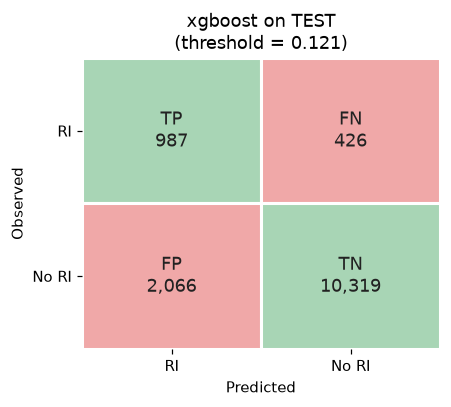

,alarm_rate,pod,far
split,,,
validation (2011–2015),0.227,0.746,0.676
test (2016–2025),0.221,0.699,0.677


Diagnostic only: best possible test threshold | threshold = 0.106
  TP = 1,078   FN = 335   FP = 2,705   TN = 9,680
  Alarm rate = 27.4%   POD (recall) = 0.763   FAR = 0.715   (precision = 0.285)

Test F2 with our threshold (0.121): 0.567
Test F2 with the best possible test threshold (0.106): 0.571


In [77]:
test_report = confusion(y_test, test_probs, DECISION_THRESHOLD_F2_OPTIMIZED, f"{BEST_MODEL_NAME} on TEST")
plot_confusion(y_test, test_probs, DECISION_THRESHOLD_F2_OPTIMIZED, f"{BEST_MODEL_NAME} on TEST");

# Same threshold, validation vs test
display(pd.DataFrame([{"split": "validation (2011–2015)", **{k: val_report[k] for k in ["alarm_rate", "pod", "far"]}},
                      {"split": "test (2016–2025)",       **{k: test_report[k] for k in ["alarm_rate", "pod", "far"]}}])
        .set_index("split").round(3))

# Diagnostic only: the best threshold we could have picked if we had looked at the test set.
# It is never used to choose anything; it only shows how good our validation choice was.
def f2_score(report):
    precision = 1 - report["far"]
    return 5 * precision * report["pod"] / max(4 * precision + report["pod"], 1e-9)

hindsight_threshold = best_threshold(y_test, test_probs, beta=2.0)
hindsight_report = confusion(y_test, test_probs, hindsight_threshold, "Diagnostic only: best possible test threshold")
print(f"Test F2 with our threshold ({DECISION_THRESHOLD_F2_OPTIMIZED:.3f}): {f2_score(test_report):.3f}")
print(f"Test F2 with the best possible test threshold ({hindsight_threshold:.3f}): {f2_score(hindsight_report):.3f}")

> #### 📊 How to read these results
>
> At our threshold, the model raises an alarm for about a quarter of observations, catches about 3 in 4 RI events (POD), and about 7 in 10 alarms are false (FAR). Validation and test agree, and even the best threshold picked on the test set (which we must never do) would barely raise F2.
>
> A precision of about 0.3 is almost three times the RI rate, so an alarm means RI is about three times more likely than usual. For cleaner alarms, alarming on the riskiest 5% makes 6 in 10 alarms correct, but catches about 3 in 10 RI events (Section 3.4).
>
> **Main takeaway:** On unseen years, most RI events are caught, at the cost of many false alarms.

---
### 1.4 Are the probabilities still reliable?

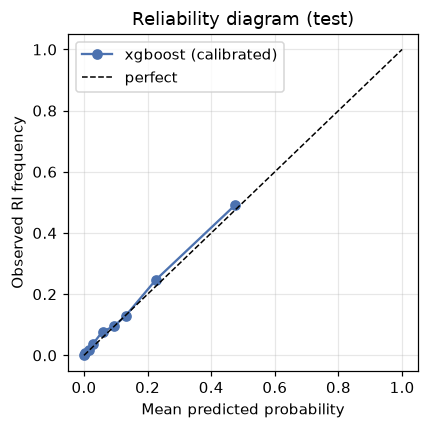

Average predicted probability: 0.094   Observed RI rate: 0.102


In [78]:
# Are the probabilities still reliable on the test years?
fig, ax = plt.subplots(figsize=(4, 4))
frac_pos, mean_pred = calibration_curve(y_test, test_probs, n_bins=10, strategy="quantile")
ax.plot(mean_pred, frac_pos, "o-", color="#4C72B0", label=f"{BEST_MODEL_NAME} (calibrated)")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
ax.set(xlabel="Mean predicted probability", ylabel="Observed RI frequency", title="Reliability diagram (test)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average predicted probability: {test_probs.mean():.3f}   Observed RI rate: {y_test.mean():.3f}")

> #### 📊 How to read this chart
>
> This is an **independent check**: the calibration was fitted on 2011–2015 and is tested here on 2016–2025. The points stay close to the diagonal, and the average prediction is slightly below the observed RI rate, which fits the distribution shift.
>
> **Main takeaway:** The probabilities stay reliable on unseen years, slightly underpredicting RI.

---
<a name="error-analysis"></a>

## 2. Error Analysis

This section looks at **where and when the model makes mistakes** using the locked test predictions from the Held-Out Test Evaluation (Results 1). We examine performance across different basins and time periods and use feature importance to better understand what the model is learning.

These analyses are **diagnostic only**: there is no refitting or changing of the model. Any findings are used to guide future improvements, not to change the test results already reported.


### 2.1 Per basin analysis

In [79]:
report_by_group(df_test, y_test, test_probs, "basin")

,storms,obs,RI,RI %,PR-AUC,vs base
basin,,,,,,
EP,198,"2,941",302,10.3%,0.474,4.6x
NA,165,"2,702",217,8.0%,0.382,4.8x
NI,54,713,74,10.4%,0.501,4.8x
SI,132,"2,539",250,9.8%,0.349,3.5x
SP,83,"1,291",129,10.0%,0.345,3.4x
WP,237,"3,612",441,12.2%,0.489,4.0x


> #### 📊 How to read this table
>
> Each row is one ocean basin in the test years. Compare each basin with its own RI rate using "vs base" (PR-AUC divided by the RI rate, where 1.0x means no better than guessing). Basins with fewer than 5 RI cases are not shown.
>
> **Main takeaway:** Judge each basin against its own RI rate.

---
### 2.2 Performance by year

In [80]:
report_by_group(df_test, y_test, test_probs, "season")

,storms,obs,RI,RI %,PR-AUC,vs base
season,,,,,,
2016,90,"1,566",164,10.5%,0.429,4.1x
2017,88,"1,279",122,9.5%,0.387,4.1x
2018,104,"1,826",190,10.4%,0.508,4.9x
2019,97,"1,734",192,11.1%,0.458,4.1x
2020,103,"1,283",143,11.1%,0.510,4.6x
2021,90,"1,448",111,7.7%,0.355,4.6x
2022,91,"1,246",107,8.6%,0.316,3.7x
2023,80,"1,609",194,12.1%,0.445,3.7x
2024,84,"1,335",138,10.3%,0.432,4.2x


> #### 📊 How to read this table
>
> Each row is one test year. The model is several times better than chance ("vs base") in every year, with no downward trend. PR-AUC varies partly because the number of RI cases changes, as other RI studies also report (An et al., 2026).
>
> **Main takeaway:** The model's skill holds up across all test years.

---
### 2.3 Feature Importance

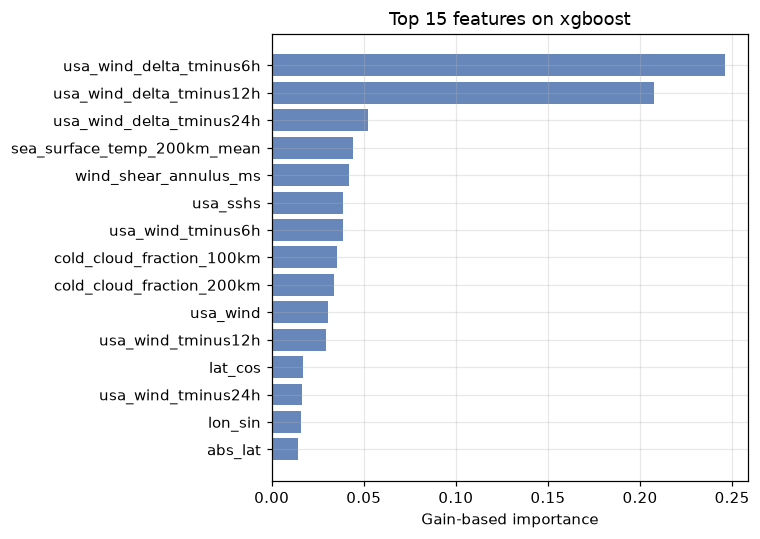

In [81]:
if hasattr(best_model, "feature_importances_"):
    importance = (pd.Series(best_model.feature_importances_,
                            index=BEST_FEATURES)
                    .sort_values(ascending=True)
                    .tail(15))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(importance.index, importance.values, color="#4C72B0", alpha=0.85)
    ax.set_xlabel("Gain-based importance")
    ax.set_title(f"Top 15 features on {BEST_MODEL_NAME}")
    plt.tight_layout()
    plt.show()

> #### 📊 How to read this chart
>
> Longer bars mean the model used that feature more (gain-based importance). Recent wind changes (`usa_wind_delta_tminus6h` and `usa_wind_delta_tminus12h`) dominate: a strengthening storm may keep strengthening. SST and wind shear lead the environmental features. Gain shows how much a feature is *used*, not its direction, and correlated features share the credit.
>
> **Main takeaway:** Recent intensity change matters most, followed by SST and wind shear.

Gain importance does not show direction. **SHAP values** do: for each observation, they show how much each feature pushed the prediction toward or away from RI. XGBoost computes them directly (`pred_contribs=True`), so no extra package is needed. Below, we plot them for four features from the Data Description.

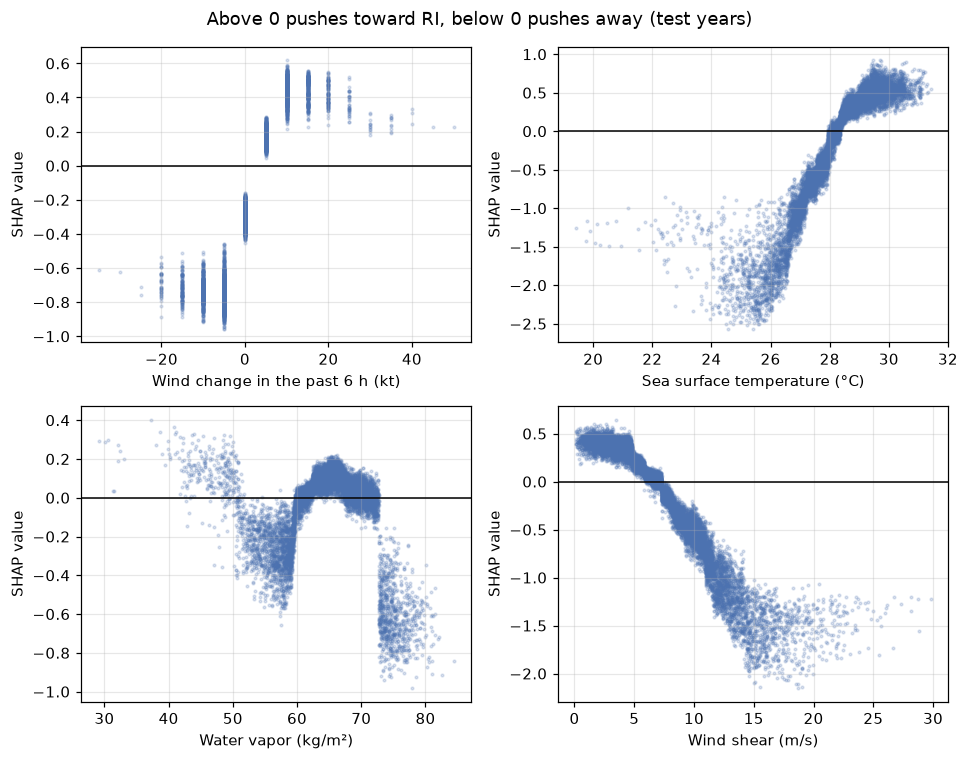

In [82]:
# Which way does each feature push the RI probability? (SHAP values, built into XGBoost)
if BEST_MODEL_NAME == "xgboost":
    # One SHAP value per feature and observation (the last column is the bias term)
    shap_values = best_model.get_booster().predict(DMatrix(X_test_best), pred_contribs=True)
    shap_df = pd.DataFrame(shap_values[:, :-1], columns=BEST_FEATURES, index=X_test_best.index)

    # feature: (axis label, offset to convert units)
    shap_features = {
        "usa_wind_delta_tminus6h":        ("Wind change in the past 6 h (kt)", 0),
        "sea_surface_temp_200km_mean":    ("Sea surface temperature (°C)", -273.15),
        "column_water_vapour_200km_mean": ("Water vapor (kg/m²)", 0),
        "wind_shear_annulus_ms":          ("Wind shear (m/s)", 0),
    }

    fig, axes = plt.subplots(2, 2, figsize=(9, 7))
    for ax, (col, (label, offset)) in zip(axes.flat, shap_features.items()):
        ax.scatter(X_test_best[col] + offset, shap_df[col], s=3, alpha=0.2, color="#4C72B0")
        ax.axhline(0, color="black", lw=1)
        ax.set(xlabel=label, ylabel="SHAP value")
    fig.suptitle("Above 0 pushes toward RI, below 0 pushes away (test years)")
    plt.tight_layout()
    plt.show()


> #### 📊 How to read this chart
>
> Each dot is one test observation. The x-axis is the feature value, and the y-axis is its SHAP value: how much that feature pushed the model's RI score up (above 0) or down (below 0). SHAP values are on the model's internal score scale, so compare their sign and size, not their exact values.
>
> - **Recent strengthening** pushes toward RI, and weakening pushes away.
> - **SST** pushes toward RI above about 28 °C, close to the range given in the Data Description.
> - **Wind shear** pushes toward RI below about 7 m/s, and away above it.
> - **Water vapor** has a less clear pattern, partly because it is closely linked to SST and the two share the credit.
>
> **Main takeaway:** The model learned the expected physics: warm water, low shear, and recent strengthening raise the chance of RI.

---
### 2.4 Which RI events are caught, and which are missed?

In [83]:
# Which RI events does the model catch, and which does it miss?
test_view = (df_test.assign(ri=y_test.values, prob=test_probs,
                            alarm=test_probs >= DECISION_THRESHOLD_F2_OPTIMIZED)
                    .sort_values(["sid", "iso_time"]))

# An RI "onset" is the first RI observation in a run of RI observations 6 hours apart
previous_ri   = test_view.groupby("sid")["ri"].shift(1)
previous_time = test_view.groupby("sid")["iso_time"].shift(1)
test_view["onset"] = (test_view["ri"] == 1) & (
    (previous_ri != 1) | (test_view["iso_time"] - previous_time != pd.Timedelta(hours=6)))

ri_cases = test_view[test_view["ri"] == 1]
display(pd.DataFrame({
    "RI cases":           [ri_cases["onset"].sum(), (~ri_cases["onset"]).sum()],
    "share caught (POD)": [ri_cases.loc[ri_cases["onset"], "alarm"].mean(),
                           ri_cases.loc[~ri_cases["onset"], "alarm"].mean()],
}, index=["start of RI (onset)", "RI already under way"]).round(2))

# Typical (median) wind changes for caught RI, missed RI and false alarms.
# The future wind is used here only to analyze errors, never as a model input.
groups = {"caught RI":   ri_cases[ri_cases["alarm"]],
          "missed RI":   ri_cases[~ri_cases["alarm"]],
          "false alarm": test_view[(test_view["ri"] == 0) & test_view["alarm"]]}
display(pd.DataFrame({name: {"wind change in the past 6 h (kt)": g["usa_wind_delta_tminus6h"].median(),
                             "wind change in the next 24 h (kt)": (g["usa_wind_tplus24h"] - g["usa_wind"]).median()}
                      for name, g in groups.items()}).T)

false_alarm_change = groups["false alarm"]["usa_wind_tplus24h"] - groups["false alarm"]["usa_wind"]
print(f"False alarms that still strengthened by at least 15 kt in 24 h: {(false_alarm_change >= 15).mean():.0%}")

,RI cases,share caught (POD)
start of RI (onset),407,0.48
RI already under way,1006,0.79


,wind change in the past 6 h (kt),wind change in the next 24 h (kt)
caught RI,5.0,40.0
missed RI,5.0,35.0
false alarm,5.0,15.0


False alarms that still strengthened by at least 15 kt in 24 h: 52%


> #### 📊 How to read these tables
>
> The first table splits RI cases into the **start** of RI (onset) and RI **already under way**. The model catches a little over half of the onsets, but most ongoing cases. The second table shows why: caught cases had usually been strengthening, while missed ones had not (median change 0 kt). About half of the false alarms still strengthened by at least 15 kt, so they are near misses.
>
> **Main takeaway:** Ongoing RI is easier to catch than its start, and many false alarms are near misses.

---
### 2.5 Performance by storm strength

In [84]:
# Skill grouped by storm strength at the time of prediction (categories from the constants cell)
strength_names = [label for _, label in STORM_CATEGORIES]
strength = pd.cut(df_test["usa_wind"], bins=[kt for kt, _ in STORM_CATEGORIES] + [np.inf],
                  right=False, labels=strength_names)

rows = []
for name in strength_names:
    mask = (strength == name).values
    y, p = y_test.values[mask], test_probs[mask]
    if y.sum() < 5:          # too few RI cases to say anything useful
        continue
    rows.append({"storm strength": name, "obs": mask.sum(), "RI %": 100 * y.mean(),
                 "PR-AUC": average_precision_score(y, p),
                 "POD": (p[y == 1] >= DECISION_THRESHOLD_F2_OPTIMIZED).mean()})
display(pd.DataFrame(rows).set_index("storm strength").round(2))

,obs,RI %,PR-AUC,POD
storm strength,,,,
Tropical Depression,2935,4.12,0.14,0.34
Tropical Storm,6304,11.72,0.43,0.75
Category 1,1791,19.82,0.53,0.79
Category 2,1009,12.19,0.46,0.67
Category 3,784,6.76,0.38,0.51
Category 4,794,2.77,0.17,0.05


> #### 📊 How to read this table
>
> Each row is one storm strength at the time of the prediction (groups with fewer than 5 RI cases are not shown). RI is most common for Category 1 hurricanes (about 20%) and around 12% for tropical storms and Category 2, where the model also does best. Tropical depressions and Category 4 hurricanes rarely have RI (about 3–4%), and the model struggles there. Very strong storms are often already near their maximum possible intensity.
>
> **Main takeaway:** The model is most useful for tropical storms and Category 1–2 hurricanes.

---
<a name="case-study"></a>

## 3. Case Study: Hurricane Milton (2024)

Milton is a storm from the test years, so the model never saw it during training. Over the Gulf of Mexico, it strengthened from about 30 kt to 150 kt in roughly two days. Let us see how the model's RI probability changed along its track.

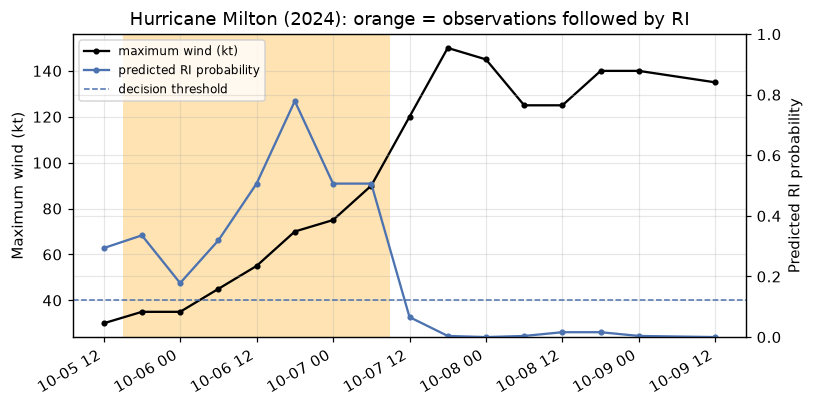

In [85]:
# Case study: Hurricane Milton (2024), a storm from the test years
storm = (df_test.assign(prob=test_probs, ri=y_test.values)
                .query("name == 'MILTON' and season == 2024")
                .sort_values("iso_time"))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax_prob = ax.twinx()
for t in storm.loc[storm["ri"] == 1, "iso_time"]:   # shade the observations followed by RI
    ax.axvspan(t - pd.Timedelta(hours=3), t + pd.Timedelta(hours=3), color="orange", alpha=0.3, lw=0)
ax.plot(storm["iso_time"], storm["usa_wind"], "k-o", ms=3, label="maximum wind (kt)")
ax_prob.plot(storm["iso_time"], storm["prob"], "-o", color="#4C72B0", ms=3, label="predicted RI probability")
ax_prob.axhline(DECISION_THRESHOLD_F2_OPTIMIZED, ls="--", color="#4C72B0", lw=1, label="decision threshold")

ax.set_ylabel("Maximum wind (kt)")
ax_prob.set_ylabel("Predicted RI probability")
ax_prob.set_ylim(0, 1)
ax.set_title("Hurricane Milton (2024): orange = observations followed by RI")
lines = ax.get_legend_handles_labels()[0] + ax_prob.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + ax_prob.get_legend_handles_labels()[1]
ax.legend(lines, labels, loc="upper left", fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

> #### 📊 How to read this chart
>
> The black line is Milton's maximum wind, the blue line is the RI probability, and orange bands mark RI observations. The probability was above the threshold from the start, rose to about 0.5–0.6 during RI, and fell to almost zero at the peak, correctly. The first observation is not RI: its wind rose by 25 kt, a near miss (Section 2.4).
>
> **Main takeaway:** On a storm it never saw, the RI probability rose during RI and fell after the peak.

---
<a name="summary-of-findings"></a>

## Summary of findings

- **Ranking (PR-AUC, our primary metric):** on unseen storms from 2016–2025, XGBoost with all features ranks RI cases about four times better than chance, clearly ahead of logistic regression and a simple wind-trend rule.
- **Probabilities (BSS):** after calibration, its probabilities beat climatology and stay reliable on the test years, even though RI became more common.
- **Alarms (POD and FAR):** at the F2 threshold, it catches about 7 to 8 out of 10 RI events, at the cost of many false alarms (about 7 out of 10). A higher threshold would give fewer false alarms but miss more RI events.
- **Where it struggles:** it catches a little over half of RI events at their start, but most RI that is already under way, because it relies heavily on recent strengthening. About half of its false alarms are near misses that still strengthened by at least 15 kt. It works best for tropical storms and Category 1–2 hurricanes, where RI is most common.
- **What the model relies on:** recent intensity change is the strongest signal. ERA5 adds the most information beyond it (SST and wind shear are its most used features), while the satellite cloud features add a small but consistent amount.
- **Stability:** skill is similar across test years, and the threshold choice is not fragile.

---
<a name="limitations"></a>

## Limitations

### 1. Not ready for real-time use

> The model is trained and tested on data that only become available after a storm is over: ERA5 reanalysis, final best tracks, and GridSat-B1 (see the *Real-time operational use* note in Data Description). So this tutorial is not a real-time forecasting system. It is a way to learn which features help predict RI. To use it during a live storm, it would need to be retrained and tested on real-time data, which are noisier, so it may not perform as well.

### 2. RI is a relatively rare event

>Rapid intensification occurs in only a small fraction of the storm observations in our dataset. This class imbalance makes RI inherently very difficult to predict.

### 3. Storm behavior changes over time

> The RI rate is higher in the validation and test years than in the training years (see *Why does the RI rate increase over time?* in Data Description). The relationship between the features and RI may also change over time, so performance on future storms may differ from what we measured on past storms. This matters when applying the model in a changing climate.

### 4. The satellite-derived cloud feature is not perfectly uniform

> The cold-cloud fraction comes from GridSat-B1, which combines observations from multiple geostationary satellites. **Satellite coverage and data quality vary across different regions and years**, which can introduce some inconsistency in the cloud feature, particularly in areas with limited historical satellite coverage.
>
>In addition, the relatively coarse spatial resolution can miss some small-scale cloud structures near the cyclone center. These factors may introduce uncertainty into the satellite-based predictors.

### 5. Hand-crafted, tabular features

> We describe each storm with a few numbers, such as the average SST within 200 km or the wind shear in a ring around the storm. This keeps the model easy to understand, but it leaves out a lot of detail: the shape of the storm, how its clouds are arranged, and how these change from hour to hour. Studies have found that information about the storm's core can improve RI prediction (Su et al., 2020).

### 6. Simple models

> We use logistic regression and gradient-boosted trees because they are fast, work well on tables of features, and are easy to interpret. They are much simpler than recent deep-learning weather models such as GraphCast, Pangu-Weather, and FourCastNet, which forecast the weather for the whole globe. They were not built for RI, and one evaluation found that they tend to underestimate how strong storms get. ***Source:*** *[An Operations-Based Evaluation of Tropical Cyclone Track and Intensity Forecasts from Artificial Intelligence Weather Prediction Models](https://doi.org/10.1175/AIES-D-24-0085.1) (DeMaria et al., 2025)*
>
> ***Sources:*** *[GraphCast](https://doi.org/10.1126/science.adi2336) (Lam et al., 2023); [Pangu-Weather](https://doi.org/10.1038/s41586-023-06185-3) (Bi et al., 2023); [FourCastNet](https://arxiv.org/abs/2202.11214) (Pathak et al., 2022)*

### 7. Not designed for storms near landfall

> Following standard RI practice, we label observations where the storm is still over water and tropical 24 hours later (Section 1.7). The model therefore has not learned how intensity changes when a storm approaches land or becomes extratropical, and should not be used for those situations, even though they are often the most dangerous.


---
<a name="notebook-to-operations"></a>

## From Notebook to Operational RI Forecasting

This notebook is a **research and learning tool**, and it is not ready to be used as a forecasting system. Below are some possible next steps for anyone who wants to extend it.

**1. Use real-time data.** The datasets used here are not available in real time (see the *Real-time operational use* note in Data Description). The model would need to be retrained and tested on real-time data to check how much the performance changes.

**2. Add information about the future.** Our features describe the storm's environment at the current time only. Adding forecasts of the environment, for example from weather forecast models, could be explored as new features.

**3. Compare against existing RI guidance.** In this notebook, the model is compared only with simple baselines. A fair next step is to compare it with the RI guidance that forecasters already use, on the same storms and times.

**4. Test it on new seasons.** Before the model can be trusted, it should be tested on seasons it has never seen, to check whether its probabilities stay reliable.

**5. Explain each prediction.** The feature importance in this notebook shows which features matter overall. Showing which features increased or decreased each individual prediction could make the outputs easier to understand.

### Ideas for addressing the limitations

| Limitation | Possible idea |
|---|---|
| 1. Not ready for real-time use | Steps 1–3 above are a good place to start. When one study replaced the original inputs with real-time ones, the model's skill went down (Rozoff et al., 2015), so it is worth measuring how big this drop is. |
| 2. RI is rare | Operational RI tools are built for more than one threshold, such as 25, 30, and 35 kt (Kaplan et al., 2010), and the same could be done here. Averaging a few models can also give more stable probabilities (Rozoff & Kossin, 2011). Since there are only a few RI cases each year, it also helps to show how much the scores change from year to year (An et al., 2026). |
| 3. Storm behavior changes over time | Check each new season whether the probabilities are still reliable. If the RI rate has changed, the probabilities can be adjusted to the new rate without retraining the model (Saerens et al., 2002), and the model can be retrained as new seasons come in. Keep in mind that part of the change over time may come from changes in how storms were observed (Kossin et al., 2013). |
| 4. Satellite data are not uniform | Check whether the results still hold when using only the years and regions with consistent satellite coverage. For example, the satellite record over the Indian Ocean changes in 1998 (Kossin et al., 2013). Microwave satellite images show the storm's core more clearly and have helped RI prediction, but they are not always available (Rozoff et al., 2015). |
| 5. Hand-crafted features | Instead of using averages, CNNs could learn features directly from ERA5 fields or satellite images, and these could be combined with the current features in gradient-boosted trees (Boussioux et al., 2022). Sequence models could also learn from a storm's recent history (Yang et al., 2020). The data pipeline in this notebook can be reused to build these inputs. |
| 6. Simple models | Forecasts from deep-learning weather models could be used as inputs. On their own, these models tend to underestimate how strong storms get (DeMaria et al., 2025), but even simple models trained on their outputs can pick up useful information for intensity forecasting (Gomez et al., 2026). The evaluation steps in this notebook can be used to compare such models fairly. |
| 7. Not designed for storms near landfall | Studying storms near landfall would need a different setup, for example a label that includes intensity change over land and features that describe the coastline and land surface. |

***Sources:*** *[Rozoff et al. (2015)](https://doi.org/10.1175/WAF-D-14-00109.1); [Kaplan et al. (2010)](https://doi.org/10.1175/2009WAF2222280.1); [Saerens et al. (2002)](https://doi.org/10.1162/089976602753284446); [Kossin et al. (2013)](https://doi.org/10.1175/JCLI-D-13-00262.1); [Boussioux et al. (2022)](https://doi.org/10.1175/WAF-D-21-0091.1); [Yang et al. (2020)](https://doi.org/10.1175/WAF-D-19-0199.1); [DeMaria et al. (2025)](https://doi.org/10.1175/AIES-D-24-0085.1); [Gomez et al. (2026)](https://doi.org/10.1175/AIES-D-25-0073.1)*

---
<a name="next-steps"></a>

## Next Steps

**Extend the Feature Set**

We used a small set of ERA5 predictors (SST, sea-level pressure, water vapor, and wind shear) and two cold-cloud fractions. Adding variables like vorticity, relative humidity, or ocean heat content could meaningfully improve model skill.

**Other Applications**

The same approach of combining IBTrACS track data, ERA5 reanalysis, and GridSat satellite imagery may be applied to TC track forecasting, rapid weakening detection, or multi-basin generalization.

---
<a name="knowledge-check"></a>

## Knowledge Check Questions

Try to answer each question before opening the answer.

**1. A classmate shuffles all the observations, splits them randomly into train and test sets, and gets a much higher PR-AUC than this tutorial. What is the most likely reason?**

- **A)** Random splits always give more reliable results.
- **B)** The random split gives the model more training data.
- **C)** The same storms end up in both train and test.
- **D)** XGBoost always works better with shuffled data.

<details>
<summary><b>Show answer</b></summary>

**C.** Observations 6 hours apart from the same storm are very similar. If they land in both train and test, the model is partly "remembering" instead of predicting. This is a form of **data leakage**, and it makes the score look better than it really is. Splitting by season keeps each storm in one split.

</details>

**2. A model predicts "no RI" for every observation in the test set, where about 10% of observations are RI. Which statement is true?**

- **A)** It catches no RI events, so it is useless for warnings.
- **B)** It is about 90% accurate, so it is a good model.
- **C)** It has a high PR-AUC because its accuracy is high.
- **D)** Its accuracy is only about 10%.

<details>
<summary><b>Show answer</b></summary>

**A.** The model is about 90% accurate, but its POD is 0: it never catches an RI event. When RI is rare, always saying "no" looks accurate without being useful. This is why we use PR-AUC, POD, and FAR instead of accuracy.

</details>

**3. We raise the decision threshold from about 0.12 to 0.5. What most likely happens?**

- **A)** It catches more RI events and gives more false alarms.
- **B)** Nothing changes, because the model itself is the same.
- **C)** PR-AUC goes up, because the alarms become more accurate.
- **D)** Fewer false alarms, but more RI events are missed.

<details>
<summary><b>Show answer</b></summary>

**D.** A higher threshold means the model must be more confident before raising an alarm. That lowers FAR but also lowers POD. PR-AUC does not change, because it does not depend on the threshold.

</details>

**4. True or false: if a storm has warm water and moist air around it, it will always go through RI.**

<details>
<summary><b>Show answer</b></summary>

**False.** These conditions make RI more likely, but they do not guarantee it. In our data, about 1 in 6 observations with conditions like the Katrina example went through RI. That is why the model gives a probability instead of a yes/no rule.

</details>

---
<a name="references"></a>

# References


1. **DeMaria, M., & Kaplan, J.** (1999). *An Updated Statistical Hurricane Intensity Prediction Scheme (SHIPS) for the Atlantic and Eastern North Pacific Basins*. Weather and Forecasting, 14(3), 326–337. [Link](https://doi.org/10.1175/1520-0434%281999%29014%3C0326:AUSHIP%3E2.0.CO;2)

2. **Kaplan, J., & DeMaria, M.** (2003). *Large-Scale Characteristics of Rapidly Intensifying Tropical Cyclones in the North Atlantic Basin*. Weather and Forecasting, 18(6), 1093–1108. [Link](https://doi.org/10.1175/1520-0434%282003%29018%3C1093:LCORIT%3E2.0.CO;2)

3. **Knapp, K. R., Kruk, M. C., Levinson, D. H., Diamond, H. J., & Neumann, C. J.** (2010). *The International Best Track Archive for Climate Stewardship (IBTrACS): Unifying Tropical Cyclone Data*. Bulletin of the American Meteorological Society, 91(3), 363–376. [Link](https://doi.org/10.1175/2009BAMS2755.1)

4. **Knapp, K. R., Ansari, S., Bain, C. L., Bourassa, M. A., Dickinson, M. J., Funk, C., et al.** (2011). *Globally Gridded Satellite Observations for Climate Studies*. Bulletin of the American Meteorological Society, 92(7), 893–907. [Link](https://doi.org/10.1175/2011BAMS3039.1)

5. **Rozoff, C. M., & Kossin, J. P.** (2011). *New Probabilistic Forecast Models for the Prediction of Tropical Cyclone Rapid Intensification*. Weather and Forecasting, 26(5), 677–689. [Link](https://doi.org/10.1175/WAF-D-10-05059.1)

6. **Hersbach, H., Bell, B., Berrisford, P., Hirahara, S., Horányi, A., Muñoz-Sabater, J., et al.** (2020). *The ERA5 global reanalysis*. Quarterly Journal of the Royal Meteorological Society, 146(730), 1999–2049. [Link](https://doi.org/10.1002/qj.3803)

7. **Su, H., Wu, L., Jiang, J. H., Pai, R., Liu, A., Zhai, A. J., et al.** (2020). *Applying Satellite Observations of Tropical Cyclone Internal Structures to Rapid Intensification Forecast With Machine Learning*. Geophysical Research Letters, 47(17), e2020GL089102. [Link](https://doi.org/10.1029/2020GL089102)

8. **Bhatia, K., Baker, A., Yang, W., Vecchi, G., Knutson, T., Murakami, H., et al.** (2022). *A potential explanation for the global increase in tropical cyclone rapid intensification*. Nature Communications, 13, 6626. [Link](https://doi.org/10.1038/s41467-022-34321-6)

9. **Li, Y., Tang, Y., Wang, S., Toumi, R., Song, X., & Wang, Q.** (2023). *Recent increases in tropical cyclone rapid intensification events in global offshore regions*. Nature Communications, 14, 5167. [Link](https://doi.org/10.1038/s41467-023-40605-2)

10. **An, S., Jeong, J., Son, S.-W., Kim, H., Jeong, J.-H., & Yoon, J.-H.** (2026). *Machine Learning Based Prediction of Tropical Cyclone Rapid Intensification in the Western North Pacific: Importance of Data Augmentation and Loss Function*. Journal of Geophysical Research: Machine Learning and Computation, 3(2), e2025JH000876. [Link](https://doi.org/10.1029/2025JH000876)

In [86]:
# @title Watermark
%load_ext watermark
%watermark -v -p codecarbon,fsspec,gcsfs,ipywidgets,jinja2,matplotlib,netCDF4,numpy,pandas,plotly,pyarrow,requests,scikit-learn,watermark,xarray,xgboost,zarr -conda

Python implementation: CPython
Python version       : 3.13.16
IPython version      : 7.34.0

codecarbon  : 3.3.1
fsspec      : 2025.3.0
gcsfs       : 2025.3.0
ipywidgets  : 7.7.1
jinja2      : 3.1.6
matplotlib  : 3.11.1
netCDF4     : 1.7.4
numpy       : 2.1.3
pandas      : 2.2.3
plotly      : 5.24.1
pyarrow     : 23.0.1
requests    : 2.32.4
scikit-learn: 1.9.0
watermark   : 2.6.0
xarray      : 2026.7.0
xgboost     : 3.4.1
zarr        : 3.3.0

